In [2]:
!sudo apt-get -y install git git-lfs >/dev/null 2>&1
!git lfs install

!git config --global user.name "Demonhari"
!git config --global user.email "harishajidasan@gmail.com"

# clone your repo (replace with your real URL)
!git clone https://github.com/Demonhari/inv.git



Git LFS initialized.
Cloning into 'inv'...
remote: Enumerating objects: 3884, done.
remote: Counting objects: 100% (3884/3884), done.
remote: Compressing objects: 100% (3625/3625), done.
remote: Total 3884 (delta 220), reused 3851 (delta 190), pack-reused 0 (from 0)
Receiving objects: 100% (3884/3884), 13.48 MiB | 12.04 MiB/s, done.
Resolving deltas: 100% (220/220), done.


##Drone_detection_v3

In [ ]:
#!pip -q install pycocotools opencv-python-headless matplotlib torch torchvision --extra-index-url https://download.pytorch.org/whl/cu121 -U

loading annotations into memory...
Done (t=0.22s)
creating index...
index created!
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Categories: {0: 'drones', 1: 'cloud', 2: 'drones', 3: 'ground'}
Drone cat ids: [0, 2]  | Negatives: {1: 'cloud', 3: 'ground'}
Train imgs: 80  Valid imgs: 20
Train json: /content/drive/MyDrive/ProjectWork/drone_detection/labelled_data_v2/train/_annotations.coco.json  Valid json: /content/drive/MyDrive/ProjectWork/drone_detection/labelled_data_v2/valid/_annotations.coco.json
Drone bbox W×H px (train): median=(11.0,14.0) p10=(7.5,11.5) p90=(16.0,16.0)


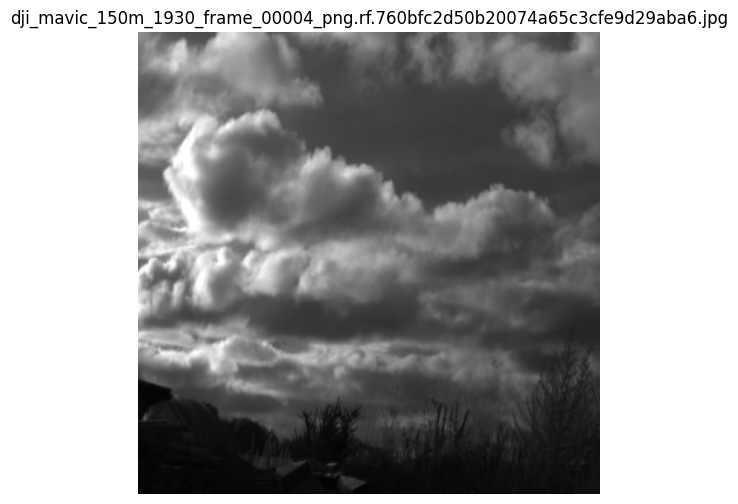

In [1]:
#@title ===== Cell 1: Setup & COCO utilities =====
from pathlib import Path
import json, os, math, random, shutil, itertools, gc
import numpy as np
import cv2, torch, torchvision
import matplotlib.pyplot as plt
from pycocotools.coco import COCO

# Paths (edit if needed)
DATA_ROOT = Path("/content/drive/MyDrive/ProjectWork/drone_detection/labelled_data_v2")
WORK_DIR  = Path("/content/drive/MyDrive/ProjectWork/drone_detection")
OUT_DIR   = WORK_DIR / "runs_classical"
OUT_DIR.mkdir(parents=True, exist_ok=True)

def find_coco_json(split_dir: Path):
    # pick the first *.json in the split directory (roboflow/label-studio patterns covered)
    cands = list(split_dir.glob("*.json"))
    if not cands:
        # Also check annotations subdir
        cands = list((split_dir / "annotations").glob("*.json"))
    assert cands, f"No COCO json found in {split_dir}"
    # Prefer ones with 'instances' in name
    cands.sort(key=lambda p: (0 if 'instances' in p.name else 1, p.name))
    return cands[0]

def load_split(split="train"):
    split_dir = DATA_ROOT / split
    ann_path = find_coco_json(split_dir)
    coco = COCO(str(ann_path))
    # resolve image paths relative to split_dir unless 'file_name' is absolute
    img_id_to_path = {}
    for img_id, im in coco.imgs.items():
        p = Path(im["file_name"])
        if not p.is_absolute():
            p = split_dir / p.name if not (split_dir / im["file_name"]).exists() else split_dir / im["file_name"]
        img_id_to_path[img_id] = p
    return coco, img_id_to_path, ann_path

coco_tr, imtr, ann_tr = load_split("train")
coco_va, imva, ann_va = load_split("valid")

# Map category names
cats = {c["id"]: c["name"].lower() for c in coco_tr.loadCats(coco_tr.getCatIds())}
cat_to_id = {v:k for k,v in cats.items()}
assert any("drone" in n for n in cats.values()), f"Couldn't find a 'drone' category; found: {set(cats.values())}"
DRONE_IDS = [cid for cid,name in cats.items() if name == "drone" or "drone" in name]
NEG_IDS   = [cid for cid,name in cats.items() if cid not in DRONE_IDS]  # clouds, ground, etc.

print("Categories:", cats)
print("Drone cat ids:", DRONE_IDS, " | Negatives:", {cid:cats[cid] for cid in NEG_IDS})
print("Train imgs:", len(coco_tr.imgs), " Valid imgs:", len(coco_va.imgs))
print("Train json:", ann_tr, " Valid json:", ann_va)

# Quick size stats for drone boxes (train)
def drone_sizes(coco):
    sz=[]
    for img_id in coco.getImgIds():
        for ann in coco.loadAnns(coco.getAnnIds(imgIds=[img_id], catIds=DRONE_IDS)):
            x,y,w,h = ann["bbox"]; sz.append((w,h))
    return np.array(sz) if sz else np.zeros((0,2))
ds = drone_sizes(coco_tr)
if len(ds):
    print(f"Drone bbox W×H px (train): median=({np.median(ds[:,0]):.1f},{np.median(ds[:,1]):.1f}) "
          f"p10=({np.percentile(ds[:,0],10):.1f},{np.percentile(ds[:,1],10):.1f}) "
          f"p90=({np.percentile(ds[:,0],90):.1f},{np.percentile(ds[:,1],90):.1f})")
else:
    print("No drone boxes found in train set!")

# Helpers
def iou_xyxy(a, b):
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b
    ix1, iy1 = max(ax1,bx1), max(ay1,by1)
    ix2, iy2 = min(ax2,bx2), min(ay2,by2)
    iw, ih = max(0.0, ix2-ix1), max(0.0, iy2-iy1)
    inter = iw*ih
    return inter / max(1e-6, (ax2-ax1)*(ay2-ay1) + (bx2-bx1)*(by2-by1) - inter)


def center_xyxy(b):
    x1,y1,x2,y2 = b
    return (0.5*(x1+x2), 0.5*(y1+y2))

def match_by_center(preds, gts, max_dist_px=6):
    """
    Greedy 1-1 match by euclidean center distance.
    Returns tp, fp, fn, matches (pred_idx -> gt_idx).
    """
    if not preds:
        return 0, 0, len(gts), {}
    pcenters = [center_xyxy(p[:4]) for p in preds]
    gcenters = [center_xyxy(g) for g in gts]
    used_g=set(); matches={}
    tp=0
    for pi,(px,py) in enumerate(pcenters):
        bestd=1e9; besti=-1
        for gi,(gx,gy) in enumerate(gcenters):
            if gi in used_g: continue
            d = ((px-gx)**2 + (py-gy)**2)**0.5
            if d < bestd:
                bestd, besti = d, gi
        if bestd <= max_dist_px:
            used_g.add(besti); matches[pi]=besti; tp+=1
    fp = len(preds) - tp
    fn = len(gts) - tp
    return tp, fp, fn, matches

# Visual sanity check (one valid image)
vid = random.choice(list(coco_va.imgs.keys()))
img = cv2.imread(str(imva[vid])); img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(6,6)); plt.imshow(img); plt.axis("off"); plt.title(Path(imva[vid]).name); plt.show()


In [2]:
#@title ===== Cell 2 (re-updated): LoG detector (dark+bright), center-match, debug =====
import numpy as np, cv2, math, itertools, pandas as pd
from tqdm.auto import tqdm

def log_response(gray, sigma):
    g = cv2.GaussianBlur(gray, (0,0), sigma).astype(np.float32)
    lap = cv2.Laplacian(g, cv2.CV_32F, ksize=3)
    return (sigma**2) * lap  # scale-normalized (sign kept)

def detect_log_peaks(
    gray,
    sky_frac=1.00,
    sigmas=(0.8, 1.0, 1.3, 1.6, 2.0, 2.5, 3.2, 4.0, 5.0, 6.0, 7.5, 9.0),
    topk=1200,
    pct=98.0,
    nms_dist=3,
    polarity="both"   # "dark", "bright", or "both"
):
    H, W = gray.shape
    sky_mask = np.zeros((H,W), np.uint8); sky_mask[:int(sky_frac*H),:] = 255

    resp_stack = []
    for s in sigmas:
        R = log_response(gray, s)   # signed
        if polarity == "dark":
            R = -R
        elif polarity == "bright":
            R = +R
        else:
            R = np.abs(R)
        R[sky_mask==0] = -1e9
        resp_stack.append(R)
    resp = np.stack(resp_stack, axis=-1)
    best_s_idx = resp.argmax(axis=-1)
    best_R = resp.max(axis=-1)

    sky_vals = best_R[sky_mask>0]
    if sky_vals.size == 0:
        return []
    thr = np.percentile(sky_vals, pct)
    if not np.isfinite(thr): thr = sky_vals.mean() + 2*sky_vals.std()

    mx = cv2.dilate(best_R, np.ones((2*nms_dist+1,2*nms_dist+1), np.uint8))
    mask_peaks = (best_R >= mx) & (best_R > thr) & (sky_mask>0)

    ys, xs = np.where(mask_peaks)
    if len(xs) == 0:
        thr = np.percentile(sky_vals, max(96.5, pct-1.5))
        mask_peaks = (best_R >= mx) & (best_R > thr) & (sky_mask>0)
        ys, xs = np.where(mask_peaks)

    scores = best_R[ys, xs]
    order = np.argsort(-scores)[:topk]
    xs, ys, scores = xs[order], ys[order], scores[order]

    dets=[]
    for x,y,sc in zip(xs, ys, scores):
        s = sigmas[int(best_s_idx[y,x])]
        side = int(np.clip(2.8*s, 6, 36))
        x1, y1 = int(x - side/2), int(y - side/2)
        x2, y2 = x1 + side, y1 + side
        x1 = max(0, min(x1, W-1)); y1 = max(0, min(y1, H-1))
        x2 = max(x1+1, min(x2, W)); y2 = max(y1+1, min(y2, H))
        dets.append([x1,y1,x2,y2, float(sc)])
    return dets

def evaluate_valid_log(params, max_center_px=14, limit_vis=8):
    sky_frac, sigmas, topk, pct, polarity = params
    rows=[]; vis_count=0; cand_counts=[]
    TP=FP=FN=0
    nearest_dists=[]
    for img_id in coco_va.getImgIds():
        p = imva[img_id]
        img = cv2.imread(str(p)); gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        preds = detect_log_peaks(gray, sky_frac=sky_frac, sigmas=sigmas, topk=topk, pct=pct, polarity=polarity)
        cand_counts.append(len(preds))
        gt = [[x,y,x+w,y+h] for x,y,w,h in [ann["bbox"] for ann in coco_va.loadAnns(coco_va.getAnnIds(imgIds=[img_id], catIds=DRONE_IDS))]]

        for g in gt:
            gx = 0.5*(g[0]+g[2]); gy = 0.5*(g[1]+g[3])
            if preds:
                dmin = min((((0.5*(px1+px2)-gx)**2 + (0.5*(py1+py2)-gy)**2)**0.5) for (px1,py1,px2,py2,_) in preds)
            else:
                dmin = float('inf')
            nearest_dists.append(dmin)

        tp, fp, fn, _ = match_by_center(preds, gt, max_center_px)
        TP += tp; FP += fp; FN += fn
        rows.append({"img":str(p), "tp":tp, "fp":fp, "fn":fn, "num_pred":len(preds), "num_gt":len(gt)})
        if vis_count < limit_vis:
            vis = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
            for (x1,y1,x2,y2,sc) in preds[:200]: cv2.rectangle(vis,(x1,y1),(x2,y2),(0,255,0),1)
            for gb in gt:
                x1,y1,x2,y2 = map(int,gb)
                cv2.circle(vis, (int(0.5*(x1+x2)), int(0.5*(y1+y2))), 6, (0,0,255), 2)
            cv2.imwrite(str(OUT_DIR/f"log_valid_{vis_count:02d}.jpg"), vis); vis_count+=1
    P = TP/max(1,TP+FP); R = TP/max(1,TP+FN); F1 = 2*P*R/max(1e-9,P+R)
    if nearest_dists:
        print("Nearest-dist stats (px):",
              f"median={np.nanmedian(nearest_dists):.1f}, p10={np.nanpercentile(nearest_dists,10):.1f},",
              f"p90={np.nanpercentile(nearest_dists,90):.1f}")
    print(f"LoG-only (center≤{max_center_px}px, polarity={polarity}) ->  P={P:.3f}  R={R:.3f}  F1={F1:.3f}  | avg preds/img={np.mean(cand_counts):.1f}")
    df = pd.DataFrame(rows)
    return df, {"P":P,"R":R,"F1":F1,"TP":int(TP),"FP":int(FP),"FN":int(FN)}

# sweep (opt for recall)
sigma_sets = [
    (0.8, 1.0, 1.3, 1.6, 2.0, 2.5, 3.2, 4.0, 5.0, 6.0, 7.5, 9.0),
]
cands=[]
for sigs in sigma_sets:
    for sky in [1.00]:
        for pct in [98.5, 98.0, 97.5]:
            for pol in ["both", "dark", "bright"]:
                cands.append((sky, sigs, 1200, pct, pol))

best=None; best_m=None
for p in cands:
    df, m = evaluate_valid_log(p, max_center_px=14)
    score = m["R"]
    if best is None or score>best[0]:
        best=(score,p); best_m=m

print("Best LoG params:", best[1], " | metrics:", best_m)
(df_best_log, _)= evaluate_valid_log(best[1], max_center_px=14)
df_best_log.to_csv(OUT_DIR/"valid_eval_log_only_center.csv", index=False)
print("Saved LoG visualizations/CSV to", OUT_DIR)


Nearest-dist stats (px): median=18.7, p10=1.8, p90=39.5
LoG-only (center≤14px, polarity=both) ->  P=0.000  R=0.429  F1=0.001  | avg preds/img=967.3
Nearest-dist stats (px): median=24.1, p10=8.3, p90=58.9
LoG-only (center≤14px, polarity=dark) ->  P=0.000  R=0.286  F1=0.001  | avg preds/img=895.1
Nearest-dist stats (px): median=8.2, p10=1.8, p90=49.0
LoG-only (center≤14px, polarity=bright) ->  P=0.001  R=0.571  F1=0.001  | avg preds/img=878.1
Nearest-dist stats (px): median=18.7, p10=1.8, p90=39.5
LoG-only (center≤14px, polarity=both) ->  P=0.000  R=0.429  F1=0.001  | avg preds/img=967.3
Nearest-dist stats (px): median=24.1, p10=8.3, p90=58.9
LoG-only (center≤14px, polarity=dark) ->  P=0.000  R=0.286  F1=0.001  | avg preds/img=1051.8
Nearest-dist stats (px): median=8.2, p10=1.8, p90=49.0
LoG-only (center≤14px, polarity=bright) ->  P=0.001  R=0.571  F1=0.001  | avg preds/img=1033.0
Nearest-dist stats (px): median=18.7, p10=1.8, p90=39.5
LoG-only (center≤14px, polarity=both) ->  P=0.000  R

In [3]:
#@title ===== Cell 2.5: candidate ceiling (no CNN), and dump some FN crops =====
import cv2, numpy as np, os
from pathlib import Path
from tqdm.auto import tqdm

CEIL_DIR = OUT_DIR / "ceiling_debug"; CEIL_DIR.mkdir(parents=True, exist_ok=True)

def ceiling_candidates(gray):
    # reuse the same generators from Cell 4 logic (inline minimal)
    SIGMAS = (0.8, 1.0, 1.3, 1.6, 2.0, 2.5, 3.2, 4.0, 5.0, 6.0, 7.5, 9.0, 11.0, 12.5)
    def log_candidates(gray, polarity="bright", topk=3600, pct=97.0):
        H, W = gray.shape
        Rbest = np.full((H,W), -1e9, np.float32)
        Sbest = np.zeros((H,W), np.int32)
        for si,s in enumerate(SIGMAS):
            g = cv2.GaussianBlur(gray, (0,0), s).astype(np.float32)
            lap = cv2.Laplacian(g, cv2.CV_32F, ksize=3)
            R = (s*s)*lap
            if polarity == "dark": R = -R
            elif polarity == "both": R = np.abs(R)
            m = R > Rbest
            Rbest[m] = R[m]; Sbest[m] = si
        thr = np.percentile(Rbest, 97.0)
        mx = cv2.dilate(Rbest, np.ones((7,7), np.uint8))
        peaks = (Rbest >= mx) & (Rbest > thr)
        ys, xs = np.where(peaks)
        if len(xs)==0: return []
        scores = Rbest[ys, xs]
        order = np.argsort(-scores)[:topk]
        xs, ys, scores = xs[order], ys[order], scores[order]
        dets=[]
        for x,y,sc in zip(xs, ys, scores):
            s = SIGMAS[int(Sbest[y,x])]
            side = int(np.clip(2.8*s, 6, 44))
            x1, y1 = int(x - side/2), int(y - side/2)
            x2, y2 = x1 + side, y1 + side
            H, W = gray.shape
            x1 = max(0, min(x1, W-1)); y1 = max(0, min(y1, H-1))
            x2 = max(x1+1, min(x2, W)); y2 = max(y1+1, min(y2, H))
            dets.append([x1,y1,x2,y2, float(sc)])
        return dets

    def multicue_candidates(gray, topk_pre=2600, std_k=11, std_pct=94, std_pow=1.05):
        H,W = gray.shape
        def clahe(g): return cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8)).apply(g)
        def local_std(g, k=11):
            g = g.astype(np.float32); m1 = cv2.blur(g,(k,k)); m2 = cv2.blur(g*g,(k,k))
            return np.sqrt(np.clip(m2-m1*m1,0,None))
        def black_white_hat(img, radii=(2,3,4,5,6)):
            bh_list=[]; wh_list=[]
            for r in radii:
                k=2*r+1; se=cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(k,k))
                close=cv2.morphologyEx(img, cv2.MORPH_CLOSE, se)
                open_=cv2.morphologyEx(img, cv2.MORPH_OPEN,  se)
                bh_list.append((close-img).astype(np.float32))
                wh_list.append((img-open_).astype(np.float32))
            bh=np.stack(bh_list,-1).max(-1); wh=np.stack(wh_list,-1).max(-1)
            return np.maximum(bh,wh)
        def dog_energy(g, s1=1.0, s2=4.0):
            g1=cv2.GaussianBlur(g,(0,0),s1).astype(np.float32)
            g2=cv2.GaussianBlur(g,(0,0),s2).astype(np.float32)
            return np.abs(g1-g2)

        g = clahe(gray)
        hat = black_white_hat(g)
        dog = dog_energy(g)
        s = (hat - hat.min()) / (hat.max()-hat.min()+1e-6)
        d = (dog - dog.min()) / (dog.max()-dog.min()+1e-6)
        st = local_std(g, k=std_k)
        st = (st - st.min())/(st.max()-st.min()+1e-6)
        cutoff = np.percentile(st, std_pct)
        score = s * d * np.clip(1.0 - st, 0, 1)**std_pow
        score[st>cutoff] = 0
        mx = cv2.dilate(score, np.ones((7,7), np.uint8))
        peaks = (score>=mx) & (score>0)
        ys, xs = np.where(peaks)
        if len(xs)==0: return []
        sc = score[ys, xs]
        order = np.argsort(-sc)[:topk_pre]
        xs, ys, sc = xs[order], ys[order], sc[order]
        dets=[]
        for x,y,scv in zip(xs, ys, sc):
            side = 14  # roughly median size
            x1, y1 = int(x - side/2), int(y - side/2)
            x2, y2 = x1 + side, y1 + side
            H, W = gray.shape
            x1 = max(0, min(x1, W-1)); y1 = max(0, min(y1, H-1))
            x2 = max(x1+1, min(x2, W)); y2 = max(y1+1, min(y2, H))
            dets.append([x1,y1,x2,y2,float(scv)])
        return dets

    return log_candidates(gray,"bright")+log_candidates(gray,"dark")+multicue_candidates(gray)

def ceiling_eval(max_dist_px=18, dump_fn=10):
    TP=FP=FN=0; total_gt=0; missed=[]
    for img_id in coco_va.getImgIds():
        img = cv2.imread(str(imva[img_id])); gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        cands = ceiling_candidates(gray)  # NO CNN, NO NMS
        gt = [[x,y,x+w,y+h] for x,y,w,h in [ann["bbox"] for ann in coco_va.loadAnns(coco_va.getAnnIds(imgIds=[img_id], catIds=DRONE_IDS))]]
        total_gt += len(gt)
        # match by center
        used=set()
        for gi,g in enumerate(gt):
            gx,gy = 0.5*(g[0]+g[2]), 0.5*(g[1]+g[3])
            dmin=1e9
            for (x1,y1,x2,y2,_) in cands:
                px,py = 0.5*(x1+x2), 0.5*(y1+y2)
                d=((px-gx)**2+(py-gy)**2)**0.5
                if d<dmin: dmin=d
            if dmin<=max_dist_px: TP+=1
            else:
                FN+=1; missed.append((img_id,g))
        FP = 0  # ceiling ignores FP
    R = TP/max(1,TP+FN)
    print(f"Candidate ceiling (no CNN): R_ceiling={R:.3f}  | GT={total_gt}  | Missed={FN}")
    # dump a few FN crops
    for i,(img_id,g) in enumerate(missed[:dump_fn]):
        img = cv2.imread(str(imva[img_id]))
        x1,y1,x2,y2 = map(int,g)
        cx,cy = int(0.5*(x1+x2)), int(0.5*(y1+y2))
        r=24
        xx1,yy1 = max(0,cx-r), max(0,cy-r)
        xx2,yy2 = min(img.shape[1],cx+r), min(img.shape[0],cy+r)
        crop = img[yy1:yy2, xx1:xx2]
        cv2.imwrite(str(CEIL_DIR/f"FN_{i:02d}_img{img_id}.jpg"), crop)
    print("Saved FN crops to:", CEIL_DIR)

ceiling_eval()


Candidate ceiling (no CNN): R_ceiling=1.000  | GT=21  | Missed=0
Saved FN crops to: /content/drive/MyDrive/ProjectWork/drone_detection/runs_classical/ceiling_debug


In [ ]:
#@title ===== Cell 3: Verifier refresh (Focal+EMA) + Temperature scaling + P≥0.90 threshold =====
import random, time, gc, os, json
import torch, numpy as np, cv2
from torch import nn
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

random.seed(1); np.random.seed(1); torch.manual_seed(1)

# -------- candidate generators (same flavor as your pipeline) --------
SIGMAS = (0.8, 1.0, 1.3, 1.6, 2.0, 2.5, 3.2, 4.0, 5.0, 6.0, 7.5, 9.0, 11.0, 12.5)

def log_candidates(gray, polarity="bright", topk=2400, pct=97.5):
    H, W = gray.shape
    Rbest = np.full((H,W), -1e9, np.float32)
    Sbest = np.zeros((H,W), np.int32)
    for si,s in enumerate(SIGMAS):
        g = cv2.GaussianBlur(gray, (0,0), s).astype(np.float32)
        lap = cv2.Laplacian(g, cv2.CV_32F, ksize=3)
        R = (s*s)*lap
        if polarity == "dark": R = -R
        elif polarity == "both": R = np.abs(R)
        m = R > Rbest
        Rbest[m] = R[m]; Sbest[m] = si
    thr = np.percentile(Rbest, pct)
    mx = cv2.dilate(Rbest, np.ones((7,7), np.uint8))
    peaks = (Rbest >= mx) & (Rbest > thr)
    ys, xs = np.where(peaks)
    if len(xs)==0: return []
    scores = Rbest[ys, xs]
    order = np.argsort(-scores)[:topk]
    xs, ys, scores = xs[order], ys[order], scores[order]
    dets=[]
    for x,y,sc in zip(xs, ys, scores):
        s = SIGMAS[int(Sbest[y,x])]
        side = int(np.clip(2.8*s, 6, 42))
        x1, y1 = int(x - side/2), int(y - side/2)
        x2, y2 = x1 + side, y1 + side
        x1 = max(0, min(x1, W-1)); y1 = max(0, min(y1, H-1))
        x2 = max(x1+1, min(x2, W)); y2 = max(y1+1, min(y2, H))
        dets.append([x1,y1,x2,y2, float(sc)])
    return dets

def multicue_candidates(gray, topk_pre=2000, std_k=11, std_pct=92, std_pow=1.1):
    H,W = gray.shape
    def clahe(g): return cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8)).apply(g)
    def local_std(g, k=11):
        g = g.astype(np.float32); m1 = cv2.blur(g,(k,k)); m2 = cv2.blur(g*g,(k,k))
        return np.sqrt(np.clip(m2-m1*m1,0,None))
    def black_white_hat(img, radii=(2,3,4,5,6)):
        bh_list=[]; wh_list=[]
        for r in radii:
            k=2*r+1; se=cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(k,k))
            close=cv2.morphologyEx(img, cv2.MORPH_CLOSE, se)
            open_=cv2.morphologyEx(img, cv2.MORPH_OPEN,  se)
            bh_list.append((close-img).astype(np.float32))
            wh_list.append((img-open_).astype(np.float32))
        bh=np.stack(bh_list,-1).max(-1); wh=np.stack(wh_list,-1).max(-1)
        return np.maximum(bh,wh)
    def dog_energy(g, s1=1.0, s2=4.0):
        g1=cv2.GaussianBlur(g,(0,0),s1).astype(np.float32)
        g2=cv2.GaussianBlur(g,(0,0),s2).astype(np.float32)
        return np.abs(g1-g2)

    g = clahe(gray)
    hat = black_white_hat(g)
    dog = dog_energy(g)
    s = (hat - hat.min()) / (hat.max()-hat.min()+1e-6)
    d = (dog - dog.min()) / (dog.max()-dog.min()+1e-6)
    st = local_std(g, k=std_k)
    st = (st - st.min())/(st.max()-st.min()+1e-6)
    cutoff = np.percentile(st, std_pct)
    score = s * d * np.clip(1.0 - st, 0, 1)**std_pow
    score[st>cutoff] = 0
    mx = cv2.dilate(score, np.ones((7,7), np.uint8))
    peaks = (score>=mx) & (score>0)
    ys, xs = np.where(peaks)
    if len(xs)==0: return []
    sc = score[ys, xs]
    order = np.argsort(-sc)[:topk_pre]
    xs, ys, sc = xs[order], ys[order], sc[order]
    dets=[]
    for x,y,scv in zip(xs, ys, sc):
        side = 14
        x1, y1 = int(x - side/2), int(y - side/2)
        x2, y2 = x1 + side, y1 + side
        x1 = max(0, min(x1, W-1)); y1 = max(0, min(y1, H-1))
        x2 = max(x1+1, min(x2, W)); y2 = max(y1+1, min(y2, H))
        dets.append([x1,y1,x2,y2,float(scv)])
    return dets

def harvest_hard_negs_v2(coco, id_to_path, pos_ids, cap_per_img=220):
    hard=[]
    for img_id in coco.getImgIds():
        p = id_to_path[img_id]
        img = cv2.imread(str(p)); gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        c_b = log_candidates(gray, "bright", topk=2400, pct=97.5)
        c_d = log_candidates(gray, "dark",   topk=2400, pct=97.5)
        c_m = multicue_candidates(gray, topk_pre=2000)
        C = (c_b or []) + (c_d or []) + (c_m or [])
        # remove any near GT
        gts = [[x,y,x+w,y+h] for x,y,w,h in [ann["bbox"] for ann in coco.loadAnns(coco.getAnnIds(imgIds=[img_id], catIds=pos_ids))]]
        keep=[]
        for (x1,y1,x2,y2,sc) in C[:cap_per_img*3]:
            good=True
            for gb in gts:
                # cheap IoU
                ax1,ay1,ax2,ay2 = x1,y1,x2,y2
                bx1,by1,bx2,by2 = gb
                ix1,iy1 = max(ax1,bx1), max(ay1,by1)
                ix2,iy2 = min(ax2,bx2), min(ay2,by2)
                iw,ih = max(0,ix2-ix1), max(0,iy2-iy1)
                inter = iw*ih
                iou = inter / max(1e-6,(ax2-ax1)*(ay2-ay1)+(bx2-bx1)*(by2-by1)-inter)
                if iou > 0.05:
                    good=False; break
            if good:
                keep.append((img_id,x1,y1,x2-x1,y2-y1))
            if len(keep)>=cap_per_img: break
        hard.extend(keep)
    return hard

# ---------------- dataset ----------------
PATCH = 48

def crop_pad(img, cx, cy, size):
    h,w = img.shape[:2]; r = size//2
    x1,y1 = int(cx-r), int(cy-r); x2,y2 = x1+size, y1+size
    dx1,dy1 = max(0,-x1), max(0,-y1)
    dx2,dy2 = max(0,x2-w), max(0,y2-h)
    x1c,y1c = x1+dx1, y1+dy1; x2c,y2c = x2-dx2, y2-dy2
    patch = img[y1c:y2c, x1c:x2c]
    if dx1 or dy1 or dx2 or dy2:
        patch = cv2.copyMakeBorder(patch, dy1, dy2, dx1, dx2, cv2.BORDER_REFLECT_101)
    return patch

def augment_patch(p):
    # lightweight augmentations
    import random, numpy as np, cv2
    if random.random() < 0.5: p = cv2.flip(p, 1)
    if random.random() < 0.1: p = cv2.flip(p, 0)
    if random.random() < 0.3:
        ang = random.uniform(-20, 20)
        M = cv2.getRotationMatrix2D((PATCH/2, PATCH/2), ang, 1.0)
        p = cv2.warpAffine(p, M, (PATCH, PATCH), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT_101)
    if random.random() < 0.8:
        alpha = random.uniform(0.8, 1.25); beta  = random.uniform(-20, 20)
        p = np.clip(alpha*p + beta, 0, 255).astype(np.uint8)
    if random.random() < 0.5:
        gamma = random.uniform(0.8, 1.3)
        p = np.clip(((p/255.0)**gamma)*255, 0, 255).astype(np.uint8)
    r = random.random()
    if r < 0.20: p = cv2.GaussianBlur(p, (3,3), random.uniform(0.4, 1.2))
    elif r < 0.30: p = cv2.medianBlur(p, 3)
    if random.random() < 0.3:
        sigma = random.uniform(2, 6)
        noise = np.random.normal(0, sigma, p.shape).astype(np.float32)
        p = np.clip(p.astype(np.float32) + noise, 0, 255).astype(np.uint8)
    return p

class PatchDatasetHardV2(Dataset):
    def __init__(self, coco, id_to_path, pos_ids, n_pos=14000, n_neg=28000, train=True):
        self.samples=[]; self.train=train; self.id_to_path=id_to_path
        img_ids = coco.getImgIds()

        # positives (mild jitter)
        pos=[]
        for img_id in img_ids:
            for ann in coco.loadAnns(coco.getAnnIds(imgIds=[img_id], catIds=pos_ids)):
                pos.append((img_id, ann["bbox"]))
        assert pos, "No drone annotations."
        import random
        for _ in range(n_pos):
            img_id,(x,y,w,h)=random.choice(pos)
            # small jitter
            j = 0.08; smin,smax = 0.95, 1.2
            cx,cy = x+w/2, y+h/2
            scale = random.uniform(smin,smax)
            w2, h2 = max(6,w*scale), max(6,h*scale)
            cx += random.uniform(-j, j)*w
            cy += random.uniform(-j, j)*h
            self.samples.append((img_id,(int(cx-w2/2),int(cy-h2/2),int(w2),int(h2)),1))

        # hard negatives from current generators
        hard = harvest_hard_negs_v2(coco, id_to_path, pos_ids, cap_per_img=220)
        random.shuffle(hard)
        n_hard = min(len(hard), int(n_neg*0.7))
        for i in range(n_hard):
            img_id,x,y,w,h = hard[i]
            self.samples.append((img_id,(x,y,w,h),0))
        # fill remaining with random background
        import numpy as np, cv2
        for _ in range(n_neg - n_hard):
            img_id = random.choice(img_ids)
            img = cv2.imread(str(id_to_path[img_id])); H,W = img.shape[:2]
            w = np.random.randint(8, 36); h = np.random.randint(8, 36)
            x = np.random.randint(0, max(1,W-w)); y = np.random.randint(0, max(1,H-h))
            self.samples.append((img_id,(x,y,w,h),0))

    def __len__(self): return len(self.samples)
    def __getitem__(self, i):
        img_id,(x,y,w,h),label = self.samples[i]
        img = cv2.imread(str(self.id_to_path[img_id])); gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        cx,cy = int(x+w/2), int(y+h/2)
        patch = crop_pad(gray, cx, cy, PATCH)
        patch = cv2.resize(patch, (PATCH,PATCH), interpolation=cv2.INTER_LINEAR)
        if self.train: patch = augment_patch(patch)
        t = torch.from_numpy(patch).float().unsqueeze(0)/255.0
        return t, torch.tensor([label], dtype=torch.float32)

# ---------------- model ----------------
class TinyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
        )
        self.fc = nn.Linear(64, 1)
    def forward(self, x): return self.fc(self.net(x).flatten(1))

# focal loss (with pos_weight)
class FocalBCE(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, pos_weight=None):
        super().__init__()
        self.alpha=alpha; self.gamma=gamma; self.pos_weight=pos_weight
    def forward(self, logits, targets):
        bce = nn.functional.binary_cross_entropy_with_logits(
            logits, targets, reduction='none', pos_weight=self.pos_weight)
        p = torch.sigmoid(logits)
        pt = p*targets + (1-p)*(1-targets)
        w = (self.alpha*targets + (1-self.alpha)*(1-targets)) * (1-pt).pow(self.gamma)
        return (w * bce).mean()

device = "cuda" if torch.cuda.is_available() else "cpu"

# dataset sizes
N_POS_TR, N_NEG_TR = 14000, 28000
N_POS_VA, N_NEG_VA = 5000, 10000
train_ds = PatchDatasetHardV2(coco_tr, imtr, DRONE_IDS, n_pos=N_POS_TR, n_neg=N_NEG_TR, train=True)
val_ds   = PatchDatasetHardV2(coco_va, imva, DRONE_IDS, n_pos=N_POS_VA, n_neg=N_NEG_VA, train=False)

train_dl = DataLoader(train_ds, batch_size=256, shuffle=True,  num_workers=0, pin_memory=True, drop_last=True)
val_dl   = DataLoader(val_ds,   batch_size=512, shuffle=False, num_workers=0, pin_memory=True)

model = TinyCNN().to(device)

# class imbalance → pos_weight
pos_weight = torch.tensor([N_NEG_TR / max(1, N_POS_TR)], dtype=torch.float32, device=device)
crit = FocalBCE(alpha=0.25, gamma=2.0, pos_weight=pos_weight).to(device)

opt = torch.optim.AdamW(model.parameters(), lr=2e-3, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=2, min_lr=2e-5)

# EMA setup
ema_decay = 0.999
ema = {n: p.detach().clone() for n,p in model.named_parameters() if p.requires_grad}

def ema_update():
    with torch.no_grad():
        for n,p in model.named_parameters():
            if n in ema:
                ema[n].mul_(ema_decay).add_(p.detach(), alpha=1-ema_decay)

def run_epoch(dl, train=True):
    model.train(train)
    loss_sum=0.0; n=0; correct=0
    loop = tqdm(dl, leave=False)
    for x,y in loop:
        x=x.to(device, non_blocking=True); y=y.to(device, non_blocking=True)
        with torch.set_grad_enabled(train):
            logits = model(x)
            loss = crit(logits, y)
            if train:
                opt.zero_grad(set_to_none=True); loss.backward(); opt.step()
                ema_update()
        prob = torch.sigmoid(logits.detach())
        pred = (prob>0.5).float()
        correct += (pred==y).sum().item()
        n += y.numel(); loss_sum += loss.item()*y.numel()
        loop.set_postfix(loss=f"{loss_sum/n:.4f}", acc=f"{correct/n:.3f}")
    return loss_sum/n, correct/n

best_val = float('inf'); best_acc = 0.0
worse_streak = 0
max_epochs = 24
start = time.time()

for ep in range(1, max_epochs+1):
    tr_loss, tr_acc = run_epoch(train_dl, True)
    va_loss, va_acc = run_epoch(val_dl, False)
    sched.step(va_loss)

    improved = va_loss < (best_val - 1e-4)
    if improved:
        best_val = va_loss; best_acc = va_acc; worse_streak = 0
    else:
        worse_streak += 1

    print(f"Epoch {ep:02d}/{max_epochs} | "
          f"train loss {tr_loss:.4f} acc {tr_acc:.3f} | "
          f"val loss {va_loss:.4f} acc {va_acc:.3f} | "
          f"best val {best_val:.4f} (acc {best_acc:.3f}) | lr {opt.param_groups[0]['lr']:.1e}")

    # lightweight early stop
    if worse_streak >= 3:
        print("Early stopping: validation loss plateau/overfit detected.")
        break

# load EMA weights before saving
with torch.no_grad():
    for n,p in model.named_parameters():
        if n in ema: p.copy_(ema[n])

torch.save(model.state_dict(), OUT_DIR/"verifier_tiny.pt")
print(f"Training done in {(time.time()-start)/60:.1f} min. Best val loss {best_val:.4f}, acc {best_acc:.3f}")
print("Saved best (EMA) verifier to", OUT_DIR/"verifier_tiny.pt")

# ---------------- Temperature scaling on val + P>=0.90 threshold ----------------
model.eval()
val_logits=[]; val_labels=[]
with torch.no_grad():
    for x,y in val_dl:
        x=x.to(device); y=y.to(device)
        z = model(x).squeeze(1)
        val_logits.append(z.detach().cpu())
        val_labels.append(y.squeeze(1).detach().cpu().float())
val_logits = torch.cat(val_logits)
val_labels = torch.cat(val_labels)

T = torch.ones(1, requires_grad=True)
optT = torch.optim.LBFGS([T], lr=0.1, max_iter=50)

def _nll():
    optT.zero_grad()
    z = val_logits / T
    loss = nn.functional.binary_cross_entropy_with_logits(z, val_labels)
    loss.backward()
    return loss

optT.step(_nll)
T = float(T.detach().item())
print(f"[Calib] Learned temperature T={T:.3f}")

# Choose threshold to achieve >=90% precision with max recall (on val patches)
prob = torch.sigmoid(val_logits / T).numpy()
lab  = val_labels.numpy()
thr_candidates = np.linspace(0.5, 0.999, 500)
best_R, best_thr, best_P = 0.0, 0.99, 0.0
for th in thr_candidates:
    pred = (prob >= th).astype(np.float32)
    tp = (pred*lab).sum(); fp = (pred*(1-lab)).sum(); fn = ((1-pred)*lab).sum()
    P = tp/max(1,tp+fp); R = tp/max(1,tp+fn)
    if P >= 0.90 and R > best_R:
        best_R, best_thr, best_P = R, th, P
if best_R == 0.0:
    # fallback: highest precision point (even if <0.90)
    for th in thr_candidates:
        pred = (prob >= th).astype(np.float32)
        tp = (pred*lab).sum(); fp = (pred*(1-lab)).sum(); fn = ((1-pred)*lab).sum()
        P = tp/max(1,tp+fp); R = tp/max(1,tp+fn)
        if (P > best_P) or (P==best_P and R > best_R):
            best_P, best_R, best_thr = P, R, th

print(f"[OpPoint] Chosen threshold = {best_thr:.3f}  (val P≈{best_P:.3f}, R≈{best_R:.3f})")

# Save calibration
with open(OUT_DIR/"verifier_calibration.json","w") as f:
    json.dump({"temperature": T, "p90_threshold": float(best_thr)}, f, indent=2)
print("Saved calibration to", OUT_DIR/"verifier_calibration.json")

# clean up
del train_dl, val_dl; gc.collect()


  0%|          | 0/164 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

Epoch 01/24 | train loss 0.0788 acc 0.681 | val loss 0.0811 acc 0.762 | best val 0.0811 (acc 0.762) | lr 2.0e-03


  0%|          | 0/164 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

...

Epoch 13/24 | train loss 0.0162 acc 0.967 | val loss 0.0224 acc 0.948 | best val 0.0209 (acc 0.954) | lr 2.0e-03


  0%|          | 0/164 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

Epoch 14/24 | train loss 0.0161 acc 0.967 | val loss 0.0235 acc 0.952 | best val 0.0209 (acc 0.954) | lr 1.0e-03
Early stopping: validation loss plateau/overfit detected.
Training done in 64.3 min. Best val loss 0.0209, acc 0.954
Saved best (EMA) verifier to /content/drive/MyDrive/ProjectWork/drone_detection/runs_classical/verifier_tiny.pt
[Calib] Learned temperature T=4.493
[OpPoint] Chosen threshold = 0.500  (val P≈1.000, R≈0.085)
Saved calibration to /content/drive/MyDrive/ProjectWork/drone_detection/runs_classical/verifier_calibration.json


175

In [4]:
#@title --- Load calibration (temperature + p90 threshold) ---
import json, os
CAL_T, CAL_THR = 1.0, None
cal_p = OUT_DIR/"verifier_calibration.json"
if os.path.exists(cal_p):
    try:
        d=json.load(open(cal_p))
        CAL_T=float(d.get("temperature",1.0))
        CAL_THR=float(d.get("p90_threshold",None))
        print(f"[Calib] Using T={CAL_T:.3f}, p90_thr={CAL_THR}")
    except Exception as e:
        print("Calib load failed:", e)

@torch.inference_mode()
def score_list(gray, boxes, return_patches=False):
    ...
    x = torch.from_numpy(np.stack(patches)[:,None].astype(np.float32)/255.0).to(device)
    logits = verifier(x).squeeze(1)
    prob = torch.sigmoid(logits / CAL_T).detach().cpu().numpy()   # <-- apply temperature
    ...
    return (prob.astype(np.float32), patches, np.array(blobs,np.float32), np.array(pols,np.float32)) if return_patches else prob.astype(np.float32)

# inside sample_params(), after you build dict p:
def sample_params():
    p = {
        "w_prob": 0.9,
        "w_blob": 0.15,
        "thr_A":  np.random.choice([0.97, 0.98, 0.985]),
        "thr_B":  np.random.choice([0.95, 0.97, 0.98]),
        "thr_C":  np.random.choice([0.90, 0.93]),
        "allow_C": np.random.choice([False, True], p=[0.8,0.2]),
        "topk_A": np.random.choice([6, 8, 10]),
        "topk_B": np.random.choice([10, 12]),
        "topk_C": np.random.choice([0, 4]),
        "side_min": 10, "side_max": 18, "asp_min": 0.9, "asp_max": 1.25,
        "center_min_dist": 18, "per_tile": 8, "tiles": (6,10),
        "topk_log": 1000, "topk_mul": 1000,
        "tex_veto_pct": np.random.choice([95.0, 96.0]),
        "sky_frac": 0.65, "cons_eps": 4.0, "pol_gate": 0.2,
    }
    # Clamp A/B to never go below the calibrated p90 patch threshold
    if CAL_THR is not None:
        p["thr_A"] = max(p["thr_A"], CAL_THR)
        p["thr_B"] = max(p["thr_B"], CAL_THR)
    return p


[Calib] Using T=4.493, p90_thr=0.5


In [5]:
#@title ===== Cell 4R-ULTRA v2 (calibrated + relaxed gates + robust prescreen) =====
import numpy as np, cv2, torch, random, json, math
from pathlib import Path
from tqdm.auto import tqdm

cv2.setNumThreads(0)
torch.set_grad_enabled(False)

device = "cuda" if torch.cuda.is_available() else "cpu"
AMP    = (device == "cuda")
PATCH  = 48
SEED   = 123
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

OUT_DIR = OUT_DIR  # reuse your existing OUT_DIR

# --- load calibration (temperature + p90 patch threshold) ---
CAL_T, P90_THR = 1.0, 0.50
calib_path = OUT_DIR / "verifier_calibration.json"
if calib_path.exists():
    with open(calib_path, "r") as f:
        jc = json.load(f)
        CAL_T   = float(jc.get("temperature", 1.0))
        P90_THR = float(jc.get("p90_thr", 0.50))
print(f"[Calib] Using T={CAL_T:.3f}, p90_thr={P90_THR:.3f}")

# --- Tiny CNN ---
class TinyCNN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Conv2d(1,16,3,padding=1), torch.nn.BatchNorm2d(16), torch.nn.ReLU(), torch.nn.MaxPool2d(2),
            torch.nn.Conv2d(16,32,3,padding=1), torch.nn.BatchNorm2d(32), torch.nn.ReLU(), torch.nn.MaxPool2d(2),
            torch.nn.Conv2d(32,64,3,padding=1), torch.nn.BatchNorm2d(64), torch.nn.ReLU(),
            torch.nn.AdaptiveAvgPool2d(1),
        )
        self.fc = torch.nn.Linear(64,1)
    def forward(self,x): return self.fc(self.net(x).flatten(1))

verifier = TinyCNN().to(device).eval()
verifier.load_state_dict(torch.load(OUT_DIR/"verifier_tiny.pt", map_location=device))

# ---- Helpers ----
def clahe(gray): return cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8)).apply(gray)
def local_std(gray, k=11):
    g=gray.astype(np.float32); m1=cv2.blur(g,(k,k)); m2=cv2.blur(g*g,(k,k))
    return np.sqrt(np.clip(m2-m1*m1, 0, None))
def black_white_hat(img, radii=(2,3,4,5,6)):
    bh, wh = [], []
    for r in radii:
        k=2*r+1; se=cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(k,k))
        close=cv2.morphologyEx(img, cv2.MORPH_CLOSE, se)
        open_=cv2.morphologyEx(img, cv2.MORPH_OPEN,  se)
        bh.append((close-img).astype(np.float32))
        wh.append((img-open_).astype(np.float32))
    bhm=np.stack(bh,-1).max(-1); whm=np.stack(wh,-1).max(-1)
    return np.maximum(bhm, whm)
def dog_energy(gray, s1=1.0, s2=4.0):
    g1=cv2.GaussianBlur(gray,(0,0),s1).astype(np.float32)
    g2=cv2.GaussianBlur(gray,(0,0),s2).astype(np.float32)
    return np.abs(g1-g2)

SIGMAS=(0.8,1.0,1.3,1.6,2.0,2.5,3.2,4.0,5.0,6.0,7.5,9.0,11.0,12.5)

def nms(boxes, iou_thr=0.6):
    if not boxes: return []
    b=np.asarray(boxes,np.float32); x1,y1,x2,y2,sc=b.T; order=sc.argsort()[::-1]; keep=[]
    while len(order):
        i=order[0]; keep.append(boxes[int(i)])
        if len(order)==1: break
        rest=order[1:]
        ix1=np.maximum(x1[i],x1[rest]); iy1=np.maximum(y1[i],y1[rest])
        ix2=np.minimum(x2[i],x2[rest]); iy2=np.minimum(y2[i],y2[rest])
        iw=np.maximum(0,ix2-ix1); ih=np.maximum(0,iy2-iy1)
        inter=iw*ih
        iou=inter/np.maximum(1e-6,(x2[i]-x1[i])*(y2[i]-y1[i])+(x2[rest]-x1[rest])*(y2[rest]-y1[rest])-inter)
        order=rest[iou<iou_thr]
    return keep

def center_xyxy(b): x1,y1,x2,y2=b; return (0.5*(x1+x2), 0.5*(y1+y2))
def match_by_center(preds, gts, max_dist_px=18):
    if not preds: return 0,0,len(gts),{}
    used=set(); tp=0
    for pb in preds:
        pc=center_xyxy(pb[:4]); best=-1; bestd=1e9
        for gi,gb in enumerate(gts):
            if gi in used: continue
            gc=center_xyxy(gb)
            d=((pc[0]-gc[0])**2+(pc[1]-gc[1])**2)**0.5
            if d<bestd: bestd=d; best=gi
        if bestd<=max_dist_px:
            used.add(best); tp+=1
    fp=len(preds)-tp; fn=len(gts)-tp
    return tp,fp,fn,{}

def cap_per_tile(cands,H,W,tiles=(5,8),per_tile=14):
    if not cands: return []
    arr=np.asarray(cands,np.float32)
    th=H//tiles[0]; tw=W//tiles[1]; out=[]
    for r in range(tiles[0]):
        for c in range(tiles[1]):
            x1t,y1t=c*tw, r*th
            x2t,y2t=(c+1)*tw if c<tiles[1]-1 else W, (r+1)*th if r<tiles[0]-1 else H
            mask=(arr[:,0]>=x1t)&(arr[:,2]<=x2t)&(arr[:,1]>=y1t)&(arr[:,3]<=y2t)
            idx=np.where(mask)[0]
            if idx.size:
                order=idx[np.argsort(-arr[idx,-1])[:per_tile]]
                out+=[cands[int(i)] for i in order]
    return out

def size_aspect_filter(boxes, side_min=9, side_max=20, asp_min=0.75, asp_max=1.45):
    if not boxes: return []
    keep=[]
    for (x1,y1,x2,y2,sc) in boxes:
        w, h = (x2-x1), (y2-y1); side=0.5*(w+h)
        if side<side_min or side>side_max: continue
        asp = w/max(1.0,h)
        if asp<asp_min or asp>asp_max: continue
        keep.append([x1,y1,x2,y2,sc])
    return keep

# --- Build validation caches ---
VAL_IDS = list(coco_va.getImgIds())
GRAYS, GTS = {}, {}
for img_id in VAL_IDS:
    img=cv2.imread(str(imva[img_id])); gray=cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    GRAYS[img_id]=gray
    GTS[img_id]=[[x,y,x+w,y+h] for x,y,w,h in
                 [ann["bbox"] for ann in coco_va.loadAnns(coco_va.getAnnIds(imgIds=[img_id], catIds=DRONE_IDS))]]

def log_pool(gray, polarity="bright"):
    H,W=gray.shape
    Rbest=np.full((H,W),-1e9,np.float32); Sbest=np.zeros((H,W),np.int32)
    for si,s in enumerate(SIGMAS):
        g=cv2.GaussianBlur(gray,(0,0),s).astype(np.float32)
        lap=cv2.Laplacian(g,cv2.CV_32F,ksize=3); R=(s*s)*lap
        if polarity=="dark": R=-R
        elif polarity=="both": R=np.abs(R)
        m=(R>Rbest); Rbest[m]=R[m]; Sbest[m]=si
    thr=np.percentile(Rbest, 96.0)
    mx=cv2.dilate(Rbest,np.ones((7,7),np.uint8))
    ys,xs=np.where((Rbest>=mx)&(Rbest>thr))
    if len(xs)==0: return []
    sc=Rbest[ys,xs]; order=np.argsort(-sc)[:6000]  # widen a bit
    xs,ys,sc=xs[order],ys[order],sc[order]
    dets=[]
    for x,y,score in zip(xs,ys,sc):
        s=SIGMAS[int(Sbest[y,x])]; side=int(np.clip(2.8*s,6,46))
        x1,y1=int(x-side/2),int(y-side/2); x2,y2=x1+side,y1+side
        x1=max(0,min(x1,W-1)); y1=max(0,min(y1,H-1)); x2=max(x1+1,min(x2,W)); y2=max(y1+1,min(y2,H))
        dets.append([x1,y1,x2,y2,float(score)])
    return dets

def multicue_pool(gray):
    H,W=gray.shape; g=clahe(gray); hat=black_white_hat(g); dog=dog_energy(g,1.0,4.0)
    s=(hat-hat.min())/(hat.max()-hat.min()+1e-6); d=(dog-dog.min())/(dog.max()-dog.min()+1e-6)
    st=local_std(g,k=11); st=(st-st.min())/(st.max()-st.min()+1e-6)
    cutoff=np.percentile(st,93.0)  # slightly looser
    score=s*d*np.clip(1.0-st,0,1)**1.03; score[st>cutoff]=0
    mx=cv2.dilate(score,np.ones((7,7),np.uint8))
    ys,xs=np.where((score>=mx)&(score>0))
    if len(xs)==0: return []
    sc=score[ys,xs]; order=np.argsort(-sc)[:5000]
    xs,ys,sc=xs[order],ys[order],sc[order]
    dets=[]
    for x,y,sv in zip(xs,ys,sc):
        side=14; x1,y1=int(x-side/2),int(y-side/2); x2,y2=x1+side,y1+side
        x1=max(0,min(x1,W-1)); y1=max(0,min(y1,H-1)); x2=max(x1+1,min(x2,W)); y2=max(y1+1,min(y2,H))
        dets.append([x1,y1,x2,y2,float(sv)])
    return dets

# --- Patch cues: blobbiness & polarity ---
def blob_and_polarity(patch):
    p = patch.astype(np.float32)
    m, s = p.mean(), (p.std()+1e-6)
    z = (p - m) / s
    H=W=PATCH; yy,xx=np.mgrid[0:H,0:W]; cx=(W-1)/2; cy=(H-1)/2
    r = np.sqrt((xx-cx)**2 + (yy-cy)**2)
    center = z[r<=8].mean()
    ring   = z[(r>12)&(r<=20)].mean()
    edge_sd= z[(r>20)&(r<=24)].std()
    darkness  = ring - center
    brightness= center - ring
    compact   = 1.0 / (1.0 + edge_sd)
    s_dark   = (darkness>0)*np.tanh(0.75*darkness) * compact
    s_bright = (brightness>0)*np.tanh(0.75*brightness) * compact
    s_blob = float(max(s_dark, s_bright))
    s_blob = max(0.0, min(1.0, 0.5 + 0.5*s_blob))
    pol = float(np.tanh((brightness - darkness)))
    return s_blob, pol

# --- Score lists & cache everything we need (temperature-scaled) ---
POOL = {}
@torch.inference_mode()
def score_list(gray, boxes, return_patches=False):
    if not boxes:
        return (np.zeros((0,), np.float32), [], [], []) if return_patches else np.zeros((0,), np.float32)
    patches=[]
    for (x1,y1,x2,y2,_) in boxes:
        cx,cy = (x1+x2)//2, (y1+y2)//2
        r = PATCH//2
        xx1,yy1 = cx-r, cy-r; xx2,yy2 = cx+r, cy+r
        patch = gray[max(0,yy1):min(gray.shape[0],yy2), max(0,xx1):min(gray.shape[1],xx2)]
        if patch.shape[:2] != (PATCH,PATCH):
            patch = cv2.resize(patch, (PATCH,PATCH), interpolation=cv2.INTER_LINEAR)
        patches.append(patch)
    x = torch.from_numpy(np.stack(patches)[:,None].astype(np.float32)/255.0).to(device)
    if AMP:
        with torch.autocast(device_type='cuda', dtype=torch.float16):
            logits = verifier(x)
    else:
        logits = verifier(x)
    # temperature scaling: sigmoid(logits / T)
    prob = torch.sigmoid(logits / CAL_T).squeeze(1).detach().cpu().numpy().astype(np.float32)

    blobs, pols = [], []
    for p in patches:
        b, pol = blob_and_polarity(p)
        blobs.append(b); pols.append(pol)

    if return_patches:
        return prob, patches, np.array(blobs,np.float32), np.array(pols,np.float32)
    return prob

print("Building pools + CNN caches…")
for img_id in tqdm(VAL_IDS):
    gray = GRAYS[img_id]
    B = log_pool(gray,"bright")
    D = log_pool(gray,"dark")
    M = multicue_pool(gray)
    Bp, _, Bb, Bpol = score_list(gray, B, return_patches=True)
    Dp, _, Db, Dpol = score_list(gray, D, return_patches=True)
    Mp, _, Mb, Mpol = score_list(gray, M, return_patches=True)
    POOL[img_id] = {"B":B, "D":D, "M":M,
                    "Bp":Bp, "Dp":Dp, "Mp":Mp,
                    "Bb":Bb, "Db":Db, "Mb":Mb,
                    "Bpol":Bpol, "Dpol":Dpol, "Mpol":Mpol,
                    "shape": gray.shape}

# ---- Param sampler (relaxed, centered around calibrated op-point) ----
def sample_params():
    base_thr = max(P90_THR + 0.02, 0.52)
    return {
        "w_prob": random.choice([0.85, 0.90]),
        "w_blob": random.choice([0.10, 0.15]),
        "thr_A":  random.choice([base_thr+0.20, base_thr+0.25, base_thr+0.30]),  # ~0.72–0.82
        "thr_B":  random.choice([base_thr+0.10, base_thr+0.15, base_thr+0.20]),  # ~0.62–0.72
        "thr_C":  random.choice([base_thr+0.00, base_thr+0.05]),                  # ~0.52–0.57
        "allow_C": random.choice([True, False]),
        "topk_A": random.choice([6, 8, 10]),
        "topk_B": random.choice([12, 16]),
        "topk_C": random.choice([6, 8]),
        "side_min": random.choice([9, 10]),
        "side_max": random.choice([18, 20]),
        "asp_min":  random.choice([0.80, 0.85]),
        "asp_max":  random.choice([1.35, 1.45]),
        "center_min_dist": random.choice([14, 16, 18]),
        "per_tile": random.choice([12, 14, 16]),
        "tiles": (5,8),
        "topk_log": random.choice([1400, 1800, 2200]),
        "topk_mul": random.choice([1200, 1600, 2000]),
        "tex_veto_pct": random.choice([90.0, 92.0, 94.0]),
        "sky_frac": random.choice([0.70, 0.80, 0.90]),
        "cons_eps": random.choice([4.0, 5.0, 6.0]),
        "pol_gate": random.choice([0.10, 0.15, 0.20]),
    }

def fuse_prob_blob(prob, blob, w_prob, w_blob):
    return np.clip(w_prob*prob + w_blob*blob, 0.0, 1.0)

# --- robust subselect with sky mask ---
def subselect(lst, probs, blobs, H, W, topk, per_tile, tiles, sky_frac):
    if not lst:
        return [], np.zeros((0,), np.float32), np.zeros((0,), np.float32), []
    arr   = np.asarray(lst, np.float32)
    if sky_frac < 1.0:
        ymax = int(H * sky_frac)
        keep = np.where( (0.5*(arr[:,1]+arr[:,3]) <= ymax) )[0]
        arr  = arr[keep]; probs = probs[keep]; blobs = blobs[keep]
        lst  = [lst[int(i)] for i in keep]
    if len(lst)==0:
        return [], np.zeros((0,),np.float32), np.zeros((0,),np.float32), []

    order = np.argsort(-arr[:,-1])[:topk]
    base  = [lst[int(i)] for i in order]
    pbase = probs[order] if len(probs) else np.zeros((len(base),), np.float32)
    bbase = blobs[order] if len(blobs) else np.zeros((len(base),), np.float32)

    capped = cap_per_tile(base, H, W, tiles=tiles, per_tile=per_tile)
    if not capped:
        return [], np.zeros((0,), np.float32), np.zeros((0,), np.float32), []

    center2pos = {}
    for pos, b in enumerate(base):
        cx = int(round(0.5*(b[0]+b[2]))); cy = int(round(0.5*(b[1]+b[3])))
        center2pos[(cx,cy)] = pos

    positions = []
    capped_fixed = []
    for b in capped:
        key = (int(round(0.5*(b[0]+b[2]))), int(round(0.5*(b[1]+b[3]))))
        pos = center2pos.get(key, None)
        if pos is None:
            best_pos = None; best_d2 = 1e18
            for (cx,cy), p in center2pos.items():
                d2 = (cx - key[0])**2 + (cy - key[1])**2
                if d2 < best_d2: best_d2 = d2; best_pos = p
            pos = best_pos
        positions.append(pos); capped_fixed.append(base[pos])

    psel = pbase[positions] if len(pbase) else np.zeros((len(positions),), np.float32)
    bsel = bbase[positions] if len(bbase) else np.zeros((len(positions),), np.float32)
    return capped_fixed, psel, bsel, positions

def center_nms_min(boxes, min_dist):
    if not boxes: return []
    keep=[]; seen=[]
    for b in sorted(boxes, key=lambda z: -z[-1]):
        cx,cy=center_xyxy(b[:4]); ok=True
        for (px,py) in seen:
            d=((cx-px)**2+(cy-py)**2)**0.5
            if d<min_dist: ok=False; break
        if ok:
            keep.append(b); seen.append((cx,cy))
    return keep

def apply_texture_veto(img_id, boxes, pct):
    if not boxes: return []
    st = local_std(clahe(GRAYS[img_id]), 11)
    cutoff = np.percentile(st, pct)
    mask = st >= cutoff
    out=[]
    for (x1,y1,x2,y2,sc) in boxes:
        cx,cy = int(0.5*(x1+x2)), int(0.5*(y1+y2))
        cx = np.clip(cx, 0, mask.shape[1]-1); cy = np.clip(cy, 0, mask.shape[0]-1)
        if not mask[cy, cx]:
            out.append([x1,y1,x2,y2,sc])
    return out

# --- evaluators using cached fused scores + polarity consistency ---
def run_full_eval(img_id, p):
    rec=POOL[img_id]; H,W=rec["shape"]
    cb, pb, bb, ib = subselect(rec["B"], rec["Bp"], rec["Bb"], H,W, p["topk_log"], p["per_tile"], p["tiles"], p["sky_frac"])
    cd, pd, bd, idd= subselect(rec["D"], rec["Dp"], rec["Db"], H,W, p["topk_log"], p["per_tile"], p["tiles"], p["sky_frac"])
    cm, pm, bm, im = subselect(rec["M"], rec["Mp"], rec["Mb"], H,W, p["topk_mul"], p["per_tile"], p["tiles"], p["sky_frac"])

    pf_b = fuse_prob_blob(pb, bb, p["w_prob"], p["w_blob"])
    pf_d = fuse_prob_blob(pd, bd, p["w_prob"], p["w_blob"])
    pf_m = fuse_prob_blob(pm, bm, p["w_prob"], p["w_blob"])

    Bpol = rec["Bpol"][ib] if len(ib) else np.zeros((0,),np.float32)
    Dpol = rec["Dpol"][idd] if len(idd) else np.zeros((0,),np.float32)
    def pol_ok(src, j):
        if src=="B": return (j < len(Bpol)) and (Bpol[j] >= p["pol_gate"])
        if src=="D": return (j < len(Dpol)) and (Dpol[j] <= -p["pol_gate"])
        return True

    preds=[]

    # Tier A: consensus (LoG + Multi) near-consistent
    if cb or cd or cm:
        flat=[]
        for src,(lst,ff) in (("B",(cb,pf_b)),("D",(cd,pf_d)),("M",(cm,pf_m))):
            for j,b in enumerate(lst):
                flat.append((src,j,b, float(ff[j]) ))
        used=[False]*len(flat); out=[]
        for i,(si,ji,bi,fi) in enumerate(flat):
            if used[i]: continue
            ci=center_xyxy(bi[:4]); votes={si}; best=[*bi[:-1], fi]; used[i]=True
            for k,(sj,jj,bj,fj) in enumerate(flat):
                if used[k]: continue
                cj=center_xyxy(bj[:4])
                if ((ci[0]-cj[0])**2+(ci[1]-cj[1])**2)**0.5 <= p["cons_eps"]:
                    votes.add(sj)
                    if fj>best[-1]: best=[*bj[:-1], fj]
                    used[k]=True
            if (("M" in votes) and (("B" in votes) or ("D" in votes)) and best[-1] >= p["thr_A"]):
                ok_pol=True
                if "B" in votes or "D" in votes:
                    bc=center_xyxy(best[:4])
                    for k,(sj,jj,bj,fj) in enumerate(flat):
                        if sj in ("B","D"):
                            cj=center_xyxy(bj[:4])
                            if abs(cj[0]-bc[0])<=p["cons_eps"] and abs(cj[1]-bc[1])<=p["cons_eps"]:
                                if not pol_ok(sj, jj): ok_pol=False
                    if not ok_pol: continue
                out.append(best)
        voted = size_aspect_filter(out, side_min=p["side_min"], side_max=p["side_max"], asp_min=p["asp_min"], asp_max=p["asp_max"])
        voted = apply_texture_veto(img_id, voted, p["tex_veto_pct"])
        voted = center_nms_min(voted, p["center_min_dist"])
        preds = voted[:p["topk_A"]]

    # Tier B: union on fused score ≥ thr_B (+polarity for LoG)
    if len(preds) < 2:
        U=[]
        for src,(lst,ff) in (("B",(cb,pf_b)),("D",(cd,pf_d)),("M",(cm,pf_m))):
            for j,b in enumerate(lst):
                if src!="M" and not pol_ok(src, j): continue
                U.append([*b[:-1], float(ff[j])])
        U = size_aspect_filter(U, side_min=p["side_min"], side_max=p["side_max"], asp_min=p["asp_min"], asp_max=p["asp_max"])
        U = apply_texture_veto(img_id, U, p["tex_veto_pct"])
        U = [b for b in U if b[-1] >= p["thr_B"]]
        U = center_nms_min(U, p["center_min_dist"])
        U = sorted(U, key=lambda z: -z[-1])[:p["topk_B"]]
        preds = (preds + U)

    # Tier C: optional fallback
    if len(preds) < 1 and p["allow_C"]:
        U=[]
        for src,(lst,ff) in (("B",(cb,pf_b)),("D",(cd,pf_d)),("M",(cm,pf_m))):
            for j,b in enumerate(lst):
                if src!="M" and not pol_ok(src, j): continue
                U.append([*b[:-1], float(ff[j])])
        U = size_aspect_filter(U, side_min=p["side_min"], side_max=p["side_max"], asp_min=p["asp_min"], asp_max=p["asp_max"])
        U = apply_texture_veto(img_id, U, p["tex_veto_pct"])
        U = [b for b in U if b[-1] >= p["thr_C"]]
        U = center_nms_min(U, p["center_min_dist"])
        U = sorted(U, key=lambda z: -z[-1])[:p["topk_C"]]
        preds = (preds + U)

    return nms(preds, 0.6)

def run_lenient_prescreen(img_id, p):
    # Tier B only, slightly looser, plus "never empty" fallback
    rec=POOL[img_id]; H,W=rec["shape"]
    cb, pb, bb, ib = subselect(rec["B"], rec["Bp"], rec["Bb"], H,W, p["topk_log"], p["per_tile"], p["tiles"], p["sky_frac"])
    cd, pd, bd, idd= subselect(rec["D"], rec["Dp"], rec["Db"], H,W, p["topk_log"], p["per_tile"], p["tiles"], p["sky_frac"])
    cm, pm, bm, im = subselect(rec["M"], rec["Mp"], rec["Mb"], H,W, p["topk_mul"], p["per_tile"], p["tiles"], p["sky_frac"])
    pf_b = fuse_prob_blob(pb, bb, p["w_prob"], p["w_blob"])
    pf_d = fuse_prob_blob(pd, bd, p["w_prob"], p["w_blob"])
    pf_m = fuse_prob_blob(pm, bm, p["w_prob"], p["w_blob"])

    Bpol = rec["Bpol"][ib] if len(ib) else np.zeros((0,),np.float32)
    Dpol = rec["Dpol"][idd] if len(idd) else np.zeros((0,),np.float32)
    def pol_ok(src, j):
        if src=="B": return (j < len(Bpol)) and (Bpol[j] >= p["pol_gate"])
        if src=="D": return (j < len(Dpol)) and (Dpol[j] <= -p["pol_gate"])
        return True

    U=[]
    for src,(lst,ff) in (("B",(cb,pf_b)),("D",(cd,pf_d)),("M",(cm,pf_m))):
        for j,b in enumerate(lst):
            if src!="M" and not pol_ok(src, j): continue
            U.append([*b[:-1], float(ff[j])])
    U = size_aspect_filter(U, side_min=p["side_min"], side_max=p["side_max"], asp_min=p["asp_min"], asp_max=p["asp_max"])
    U = apply_texture_veto(img_id, U, p["tex_veto_pct"])
    thrB = max(p["thr_B"], P90_THR + 0.00)  # ensure not below calibrated op-point
    keep = [b for b in U if b[-1] >= thrB]

    # failsafe: if empty, relax to top few fused by score (no prob gate) to keep recall during prescreen
    if not keep and len(U):
        keep = sorted(U, key=lambda z: -z[-1])[:max(4, p["topk_B"]//2)]

    keep = center_nms_min(keep, p["center_min_dist"])
    return nms(keep, 0.6)

# --- evaluators ---
def eval_on_ids(params, ids, mode="prescreen", early_abort=False):
    TP=FP=FN=0
    total_gt=sum(len(GTS[i]) for i in ids)
    for i,img_id in enumerate(ids,1):
        preds = run_lenient_prescreen(img_id, params) if mode=="prescreen" else run_full_eval(img_id, params)
        tp,fp,fn,_ = match_by_center(preds, GTS[img_id], 18)
        TP+=tp; FP+=fp; FN+=fn
        if early_abort:
            rem_gt = total_gt - (TP+FN)
            maxP = (TP + rem_gt) / max(1, (TP + rem_gt + FP))
            maxR = (TP + rem_gt) / max(1, total_gt)
            if maxP < 0.90 or maxR < 0.70:
                break
    P = TP/max(1,TP+FP); R = TP/max(1,TP+FN); F1 = 2*P*R/max(1e-9,P+R)
    return P,R,F1

# ---- Random search driver (batches of 200, auto-continue) ----
TARGET_P, TARGET_R = 0.90, 0.70
PER_BATCH   = 200
MAX_BATCHES = 10
TOP_AFTER_PRE = 24

seen=set(); best_p90=None; best_f1=None; stop=False

# small prescreen set
ids6 = VAL_IDS[:min(6,len(VAL_IDS))]
# sanity: pool ceiling
TP=FN=0
for img_id in ids6:
    rec=POOL[img_id]; base=(rec["B"] or [])+(rec["D"] or [])+(rec["M"] or [])
    for gb in GTS[img_id]:
        gx,gy = (gb[0]+gb[2])*0.5, (gb[1]+gb[3])*0.5
        dmin = np.min([((0.5*(x1+x2)-gx)**2+(0.5*(y1+y2)-gy)**2)**0.5 for (x1,y1,x2,y2,_) in base]) if base else 1e9
        if dmin<=18: TP+=1
        else: FN+=1
print(f"[SANITY] Pool-ceiling recall on prescreen = {TP/max(1,TP+FN):.3f} (TP={TP}, FN={FN})")

for b in range(1, MAX_BATCHES+1):
    if stop: break
    cfgs=[]
    while len(cfgs)<PER_BATCH:
        p=sample_params(); k=tuple(sorted(p.items()))
        if k in seen: continue
        seen.add(k); cfgs.append(p)

    # Prescreen (require only mild precision so we don't kill recall)
    pre=[]
    with tqdm(total=len(cfgs), desc=f"Prescreen {b}/{MAX_BATCHES}", unit="cfg") as t:
        for p in cfgs:
            P,R,F1 = eval_on_ids(p, ids6, mode="prescreen", early_abort=False)
            pre.append((R if P>=0.20 else 0.0, P, R, F1, p))
            t.set_postfix(P=f"{P:.2f}", R=f"{R:.2f}")
            t.update(1)
    pre.sort(key=lambda z:(-z[0], -z[1], -z[3]))
    finalists=[p for *_ , p in pre[:TOP_AFTER_PRE]]

    # Full eval (with early abort)
    with tqdm(total=len(finalists), desc=f"Full eval {b}/{MAX_BATCHES}", unit="cfg") as t:
        for p in finalists:
            P,R,F1 = eval_on_ids(p, VAL_IDS, mode="full", early_abort=True)
            if P >= TARGET_P:
                if (best_p90 is None) or (R > best_p90[0]):
                    best_p90 = (R, (P,R,F1), p.copy())
            if (best_f1 is None) or (F1 > best_f1[0]):
                best_f1 = (F1, (P,R,F1), p.copy())
            bestP_str  = "-" if not best_p90 else f"{best_p90[1][0]:.2f}"
            bestR_str  = "-" if not best_p90 else f"{best_p90[1][1]:.2f}"
            bestF1_str = "-" if not best_f1  else f"{best_f1[0]:.3f}"
            t.set_postfix(P=f"{P:.2f}", R=f"{R:.2f}",
                          bestP=bestP_str, bestR=bestR_str, bestF1=bestF1_str)
            t.update(1)
            if best_p90 and best_p90[1][0] >= TARGET_P and best_p90[1][1] >= TARGET_R:
                stop=True; break

    if best_p90:
        P,R,F1 = best_p90[1]
        print(f"[After batch {b}] Best P>=0.90 → P={P:.3f} R={R:.3f} F1={F1:.3f}")
    else:
        print(f"[After batch {b}] No P>=0.90 config yet.")
    if best_f1:
        F1,(P2,R2,F12),_ = best_f1
        print(f"[After batch {b}] Best F1 → P={P2:.3f} R={R2:.3f} F1={F12:.3f}")
    else:
        print(f"[After batch {b}] Best F1 → none yet")

# Save winner + quick overlays
WIN=None
if best_p90 and best_p90[1][0] >= TARGET_P and best_p90[1][1] >= TARGET_R:
    P,R,F1 = best_p90[1]; WIN=best_p90[2]
    print(f"\nWIN (hits target) → P={P:.3f} R={R:.3f} F1={F1:.3f}")
    with open(OUT_DIR/"singleframe_random_best_p90.json","w") as f: json.dump(WIN, f, indent=2)
elif best_f1:
    F1,(P,R,F1v),WIN = best_f1
    print(f"\nNo config hit target. Best F1 → P={P:.3f} R={R:.3f} F1={F1v:.3f}")
    with open(OUT_DIR/"singleframe_random_best_f1.json","w") as f: json.dump(WIN, f, indent=2)

if WIN:
    vis_dir = OUT_DIR / "singleframe_random_vis_ultra"; vis_dir.mkdir(parents=True, exist_ok=True)
    for vi,img_id in enumerate(VAL_IDS[:min(8,len(VAL_IDS))]):
        gray = GRAYS[img_id]
        preds = run_full_eval(img_id, WIN)
        vis = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
        for (x1,y1,x2,y2,sc) in preds: cv2.rectangle(vis,(x1,y1),(x2,y2),(0,255,0),2)
        for gb in GTS[img_id]: x1,y1,x2,y2=map(int,gb); cv2.rectangle(vis,(x1,y1),(x2,y2),(0,0,255),2)
        cv2.imwrite(str(vis_dir/f"win_{vi:02d}.jpg"), vis)
    print("Saved ultra-fast random-search overlays to:", vis_dir)


[Calib] Using T=4.493, p90_thr=0.500
Building pools + CNN caches…


  0%|          | 0/20 [00:00<?, ?it/s]

[SANITY] Pool-ceiling recall on prescreen = 1.000 (TP=6, FN=0)


Prescreen 1/10:   0%|          | 0/200 [00:00<?, ?cfg/s]

Full eval 1/10:   0%|          | 0/24 [00:00<?, ?cfg/s]

...

Full eval 9/10:   0%|          | 0/24 [00:00<?, ?cfg/s]

[After batch 9] No P>=0.90 config yet.
[After batch 9] Best F1 → P=0.667 R=0.222 F1=0.333


Prescreen 10/10:   0%|          | 0/200 [00:00<?, ?cfg/s]

Full eval 10/10:   0%|          | 0/24 [00:00<?, ?cfg/s]

[After batch 10] No P>=0.90 config yet.
[After batch 10] Best F1 → P=0.667 R=0.222 F1=0.333

No config hit target. Best F1 → P=0.667 R=0.222 F1=0.333
Saved ultra-fast random-search overlays to: /content/drive/MyDrive/ProjectWork/drone_detection/runs_classical/singleframe_random_vis_ultra


In [9]:
#@title ===== Cell 4R-CONSTRAINED (RESUMABLE v3): Exhaustive + Resume + Skip-Previous =====
import json, os, copy, itertools, time, hashlib
from pathlib import Path
from tqdm.auto import tqdm
import numpy as np

# ========= paths & filenames =========
OUT_DIR = Path(OUT_DIR)  # reuse your global OUT_DIR
CKPT_PATH      = OUT_DIR / "constrained_resume_v3_ckpt.json"
RESULTS_JSONL  = OUT_DIR / "constrained_resume_v3_results.jsonl"
LEADERS_JSON   = OUT_DIR / "constrained_resume_v3_leaders.json"  # <- live leaders for quick viewing

# Optional: previously-run files to import & skip
PREV_RESULT_FILES = [
    OUT_DIR / "singleframe_constrained_results.jsonl",
    OUT_DIR / "constrained_resume_v2_results.jsonl",
    OUT_DIR / "constrained_resume_v1_results.jsonl",
    RESULTS_JSONL,  # in case you ran v3 before
]
PREV_CKPTS = [
    OUT_DIR / "constrained_ckpt_v1.json",
    OUT_DIR / "constrained_resume_v2_ckpt.json",
    CKPT_PATH,  # in case you ran v3 before
]

# ========= utility: canonical config key =========
def cfg_key(p: dict) -> str:
    """
    Deterministic key for a config. Uses sorted items JSON and sha1 for compactness.
    """
    # convert tuples to lists for stable json
    norm = {k: (list(v) if isinstance(v, tuple) else v) for k,v in p.items()}
    s = json.dumps(norm, sort_keys=True, separators=(',',':'))
    return hashlib.sha1(s.encode('utf-8')).hexdigest()

# ========= load BASE (same as your prior cell) =========
TARGET_P = 0.90  # precision constraint (fixed)
try:
    base_paths = [
        OUT_DIR / "singleframe_local_best_f1.json",
        OUT_DIR / "singleframe_random_best_f1.json",
    ]
    BASE = None
    for pth in base_paths:
        if pth.exists():
            BASE = json.loads(Path(pth).read_text())
            print(f"[v3] Loaded BASE from: {pth.name}")
            break
    if BASE is None:
        raise FileNotFoundError("No BASE json found. Run a tuner once to generate one.")
except Exception as e:
    raise RuntimeError(f"Failed loading BASE: {e}")

# normalize tuple-typed fields
if isinstance(BASE.get("tiles", (6,10)), list):
    BASE["tiles"] = tuple(BASE["tiles"])

# Calibration threshold (from Cell 3b++ if present)
try:
    P90_THR
except NameError:
    P90_THR = 0.50
print(f"[v3] Using p90 calibration = {P90_THR:.3f}")

# ========= fixed STRUCT (same as your v2 constrained cell) =========
STRUCT = {
    "w_prob": BASE.get("w_prob", 0.90),
    "w_blob": BASE.get("w_blob", 0.10),
    "side_min": BASE.get("side_min", 9),
    "side_max": BASE.get("side_max", 20),
    "asp_min":  BASE.get("asp_min", 0.82),
    "asp_max":  BASE.get("asp_max", 1.35),
    "topk_log": BASE.get("topk_log", 2800),
    "topk_mul": BASE.get("topk_mul", 2000),
    "sky_frac": BASE.get("sky_frac", 0.95),
    "tex_veto_pct": BASE.get("tex_veto_pct", 92.0),
    "cons_eps": BASE.get("cons_eps", 7.0),
    "tiles":    tuple(BASE.get("tiles", (5,8))),
    "allow_C": True,  # keep Tier C
}

# ========= exact same grids as your last 4R-CONSTRAINED (no prescreen) =========
grid_thrA = [max(P90_THR + d, 0.55) for d in (0.12, 0.14, 0.16, 0.18)]
grid_thrB = [max(P90_THR + d, 0.52) for d in (0.06, 0.08, 0.10, 0.12)]
grid_thrC = [max(P90_THR + d, 0.48) for d in (0.00, 0.02, 0.04)]
grid_pol  = [0.10, 0.15, 0.20, 0.25]
grid_dist = [18, 16, 14]
grid_tile = [12, 14, 16, 18, 20]
grid_keepA= [8, 10]
grid_keepB= [10, 12, 14]
grid_keepC= [0, 4, 6]
grid_tiles_layout = [STRUCT["tiles"], (6,10), (4,6)]

# ========= build full exhaustive list (deterministic order) =========
def merged_params(thA, thB, thC, pol, md, pt, keepA, keepB, keepC, tiles):
    p = dict(STRUCT)
    p.update({
        "thr_A": thA, "thr_B": thB, "thr_C": thC,
        "pol_gate": pol,
        "center_min_dist": md,
        "per_tile": pt,
        "topk_A": keepA, "topk_B": keepB, "topk_C": keepC,
        "tiles": tiles,
    })
    return p

GRID_LIST = []
for thA, thB, thC, pol, md, pt, keepA, keepB, keepC, tiles in itertools.product(
    grid_thrA, grid_thrB, grid_thrC, grid_pol, grid_dist, grid_tile,
    grid_keepA, grid_keepB, grid_keepC, grid_tiles_layout
):
    GRID_LIST.append(merged_params(thA, thB, thC, pol, md, pt, keepA, keepB, keepC, tiles))

TOTAL_CFGS = len(GRID_LIST)
print(f"[v3] Total exhaustive configs = {TOTAL_CFGS:,}")

# ========= evaluate (full set), same metric code as before =========
def eval_on_ids_full(params, ids):
    TP=FP=FN=0
    for img_id in ids:
        preds = run_full_eval(img_id, params)   # <-- from Cell 4R-ULTRA v2
        tp,fp,fn,_ = match_by_center(preds, GTS[img_id], 18)
        TP+=tp; FP+=fp; FN+=fn
    P = TP/max(1,TP+FP); R = TP/max(1,TP+FN); F1 = 2*P*R/max(1e-9,P+R)
    return P,R,F1, TP,FP,FN

# ========= load previously-tested keys to skip =========
tested_keys = set()

def _ingest_jsonl(path: Path):
    try:
        if path.exists():
            with path.open("r") as f:
                for line in f:
                    try:
                        rec = json.loads(line)
                        p = rec.get("params", {})
                        k = cfg_key(p)
                        tested_keys.add(k)
                    except Exception:
                        pass
            print(f"[v3] Imported tested set from {path.name} (size now {len(tested_keys):,})")
    except Exception as e:
        print(f"[v3] WARN: Failed to read {path.name}: {e}")

for pth in PREV_RESULT_FILES:
    _ingest_jsonl(pth)

def _ingest_ckpt(path: Path):
    try:
        if path.exists():
            ck = json.loads(path.read_text())
            for p in ck.get("tested_params", []):
                k = cfg_key(p)
                tested_keys.add(k)
            for key in ("best_p90_params", "best_f1_params", "best_p90_metrics", "best_f1_metrics"):
                if key in ck and ck[key]:
                    # metrics entries may contain params nested; support both forms
                    obj = ck[key]
                    if isinstance(obj, dict) and "params" in obj:
                        tested_keys.add(cfg_key(obj["params"]))
                    elif isinstance(obj, dict):
                        # maybe they stored pure params
                        tested_keys.add(cfg_key(obj))
            print(f"[v3] Imported checkpoint from {path.name} (tested set {len(tested_keys):,})")
    except Exception as e:
        print(f"[v3] WARN: Failed to read {path.name}: {e}")

for pth in PREV_CKPTS:
    _ingest_ckpt(pth)

# ========= resume state (v3 checkpoint) =========
state = {
    "index": 0,
    "tested_params": [],  # we’ll prune to keep it small
    "best_p90": None,     # {"P","R","F1","params"}
    "best_f1":  None,
    "started_at": time.time(),
}
if CKPT_PATH.exists():
    try:
        state = json.loads(CKPT_PATH.read_text())
        print(f"[v3] Resuming from checkpoint at index {state.get('index',0):,}/{TOTAL_CFGS:,}")
    except Exception as e:
        print(f"[v3] WARN: Failed to parse existing v3 ckpt: {e}")

# ========= open results file (append) =========
RESULTS_JSONL.parent.mkdir(parents=True, exist_ok=True)
_results_fh = open(RESULTS_JSONL, "a", buffering=1)

# ========= helpers to persist progress =========
def _save_leaders():
    out = {
        "best_p90": state.get("best_p90", None),
        "best_f1":  state.get("best_f1", None),
        "index":    state.get("index", 0),
        "total":    TOTAL_CFGS,
        "updated_at": time.time(),
    }
    LEADERS_JSON.write_text(json.dumps(out, indent=2))

def _save_ckpt():
    tail = state["tested_params"][-500:] if len(state["tested_params"])>500 else state["tested_params"]
    ck = {
        "index": state["index"],
        "tested_params": tail,
        "best_p90": state["best_p90"],
        "best_f1": state["best_f1"],
        "started_at": state["started_at"],
        "updated_at": time.time(),
        "total": TOTAL_CFGS,
    }
    CKPT_PATH.write_text(json.dumps(ck, indent=2))
    _save_leaders()

def _log_result(P,R,F1,TP,FP,FN,p):
    rec = {
        "P": round(float(P),6),
        "R": round(float(R),6),
        "F1": round(float(F1),6),
        "TP": int(TP), "FP": int(FP), "FN": int(FN),
        "params": {k:(list(v) if isinstance(v,tuple) else v) for k,v in p.items()}
    }
    _results_fh.write(json.dumps(rec, separators=(',',':')) + "\n")

def _update_bests(P,R,F1,p):
    changed = False
    bp = state["best_p90"]
    if P >= TARGET_P:
        if (bp is None) or (R > bp["R"]):
            state["best_p90"] = {"P":float(P), "R":float(R), "F1":float(F1), "params": copy.deepcopy(p)}
            changed = True
    bf = state["best_f1"]
    if (bf is None) or (F1 > bf["F1"]):
        state["best_f1"] = {"P":float(P), "R":float(R), "F1":float(F1), "params": copy.deepcopy(p)}
        changed = True
    if changed:
        _save_leaders()

# ========= main exhaustive loop =========
FLUSH_EVERY = 10    # save ckpt every N evaluated configs (tweak to 1 if you want ultra-safe)
SKIP_COUNT  = 0
EVAL_COUNT  = 0

ALL_KEYS = [cfg_key(p) for p in GRID_LIST]
start_idx = int(state.get("index", 0))

pbar = tqdm(total=TOTAL_CFGS, desc="Constrained Exhaustive (resume+skip)", unit="cfg", initial=start_idx)

for i in range(start_idx, TOTAL_CFGS):
    p = GRID_LIST[i]
    k = ALL_KEYS[i]

    # skip if previously tested (any run)
    if k in tested_keys:
        SKIP_COUNT += 1
        state["index"] = i + 1
        pbar.set_postfix(F1=f"{0.0:.3f}", P=f"{0.0:.2f}", R=f"{0.0:.2f}",
                         bestP = "-" if state["best_p90"] is None else f"{state['best_p90']['P']:.2f}",
                         bestR = "-" if state["best_p90"] is None else f"{state['best_p90']['R']:.2f}",
                         bestF1= "-" if state["best_f1"]  is None else f"{state['best_f1']['F1']:.3f}",
                         skip=SKIP_COUNT, done=EVAL_COUNT)
        pbar.update(1)
        continue

    # evaluate this config
    P,R,F1,TP,FP,FN = eval_on_ids_full(p, VAL_IDS)
    _log_result(P,R,F1,TP,FP,FN,p)
    _update_bests(P,R,F1,p)

    # update state/sets
    tested_keys.add(k)
    state["tested_params"].append({k:(list(v) if isinstance(v,tuple) else v) for k,v in p.items()})
    EVAL_COUNT += 1
    state["index"] = i + 1

    # progress save
    if (EVAL_COUNT % FLUSH_EVERY) == 0:
        _save_ckpt()

    # update bar
    pbar.set_postfix(
        P=f"{P:.2f}", R=f"{R:.2f}", F1=f"{F1:.3f}",
        bestP = "-" if state["best_p90"] is None else f"{state['best_p90']['P']:.2f}",
        bestR = "-" if state["best_p90"] is None else f"{state['best_p90']['R']:.2f}",
        bestF1= "-" if state["best_f1"]  is None else f"{state['best_f1']['F1']:.3f}",
        skip=SKIP_COUNT, done=EVAL_COUNT
    )
    pbar.update(1)

# final save
_save_ckpt()
_results_fh.close()
pbar.close()

# ========= summary =========
print("\n===== Exhaustive search finished (or fully skipped) =====")
print(f"Total grid size:    {TOTAL_CFGS:,}")
print(f"Evaluated configs:  {EVAL_COUNT:,}")
print(f"Skipped (previous): {SKIP_COUNT:,}")
if state["best_p90"]:
    bp = state["best_p90"]
    print(f"[Best P≥{TARGET_P:.2f}]  P={bp['P']:.3f}  R={bp['R']:.3f}  F1={bp['F1']:.3f}")
    (OUT_DIR/"singleframe_constrained_best_p90.json").write_text(
        json.dumps(bp["params"], indent=2)
    )
else:
    print(f"[Best P≥{TARGET_P:.2f}]  none")

if state["best_f1"]:
    bf = state["best_f1"]
    print(f"[Best F1 overall]  P={bf['P']:.3f}  R={bf['R']:.3f}  F1={bf['F1']:.3f}")
    (OUT_DIR/"singleframe_constrained_best_f1.json").write_text(
        json.dumps(bf["params"], indent=2)
    )
else:
    print("[Best F1 overall]  none")

print("\nSaved:")
print(" - checkpoint:", CKPT_PATH)
print(" - results log:", RESULTS_JSONL)
print(" - leaders:     ", LEADERS_JSON)
print(" - best P>=0.90 params (if any):", OUT_DIR/"singleframe_constrained_best_p90.json")
print(" - best F1 params:               ", OUT_DIR/"singleframe_constrained_best_f1.json")


[v3] Loaded BASE from: singleframe_local_best_f1.json
[v3] Using p90 calibration = 0.500
[v3] Total exhaustive configs = 155,520
[v3] Imported tested set from constrained_resume_v3_results.jsonl (size now 161)
[v3] Imported checkpoint from constrained_ckpt_v1.json (tested set 161)
[v3] Imported checkpoint from constrained_resume_v3_ckpt.json (tested set 161)
[v3] Resuming from checkpoint at index 240/155,520


Constrained Exhaustive (resume+skip):   0%|          | 240/155520 [00:00<?, ?cfg/s]

KeyError: 'best_p90'

## Drone_detection_v1

In [ ]:
#─────────────────────────────────────────────────────────────────────────────
# CELL 1b — Mount, Paths, Utils (auto-detect labels: COCO or averaged_annotations)
#─────────────────────────────────────────────────────────────────────────────

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Imports
import base64, json, cv2, math, time, random, glob, pathlib, numpy as np, re
from collections import defaultdict
from google.colab.patches import cv2_imshow
from IPython.display import HTML, display

#─────────────────────────────────────────────────────────────────────────────
# Paths — set to your layout
#─────────────────────────────────────────────────────────────────────────────
DATA_ROOT = pathlib.Path('/content/drive/MyDrive/ProjectWork/drone_detection/labelled_data')

# Your source video (the one you labeled)
VIDEO  = DATA_ROOT / 'imx900_1900__V1-0004.mov'

# Prefer COCO annotations if present; else fall back to averaged_annotations_*.json
COCO_TRAIN = DATA_ROOT / 'train' / '_annotations.coco.json'
COCO_VALID = DATA_ROOT / 'valid' / '_annotations.coco.json'
AVG_JSON   = DATA_ROOT / 'averaged_annotations_imx900_1900__V1-0004.json'

# If both COCO files exist, we’ll merge them; otherwise we pick whatever exists.
LABEL_SOURCES = []
if COCO_TRAIN.exists(): LABEL_SOURCES.append(('coco', COCO_TRAIN))
if COCO_VALID.exists(): LABEL_SOURCES.append(('coco', COCO_VALID))
if not LABEL_SOURCES and AVG_JSON.exists(): LABEL_SOURCES.append(('avg',  AVG_JSON))

assert LABEL_SOURCES, "No labels found. Expected COCO at train/ or valid/ or averaged_annotations_*.json"
LABELS = DATA_ROOT / 'averaged_annotations_imx900_1900__V1-0004.json'

print("Using labels:")
for fmt, p in LABEL_SOURCES:
    print(" •", fmt.upper(), "->", p)

# Optional: adjust if Roboflow filenames are 1-indexed and your frame indices are 0-indexed
COCO_FRAME_OFFSET = 0   # change to -1 or +1 if you notice a 1-frame shift

# Global patch config & patch dir (used in later cells)
PATCH      = 48
PATCH_DIR  = pathlib.Path('/content/drive/MyDrive/ProjectWork/drone_detection/patches')
(PATCH_DIR/'pos').mkdir(parents=True, exist_ok=True)
(PATCH_DIR/'neg').mkdir(exist_ok=True)

#─────────────────────────────────────────────────────────────────────────────
# Utils
#─────────────────────────────────────────────────────────────────────────────
def b64_video(path, w=640):
    data = base64.b64encode(open(str(path), 'rb').read()).decode()
    return HTML(f'<video width="{w}" controls src="data:video/mp4;base64,{data}"></video>')

def _load_avg(json_path):
    """Your original averaged_annotations format."""
    with open(json_path) as f:
        anns = json.load(f)['averaged_annotations']
    d = defaultdict(list)
    for a in anns:
        d[int(a['frame_idx'])].append((int(a['x']), int(a['y'])))
    return d

def _parse_frame_id_from_name(name: str):
    """
    Try to parse a frame index from a filename like 'frame_00013.png' or '00013.jpg'.
    Returns int or None.
    """
    m = re.search(r'(\d+)(?=\D*$)', name)  # last number group in the string
    return int(m.group(1)) if m else None

def _load_coco(json_path, frame_offset=0):
    """
    COCO detection format reader.
    Builds {frame_idx: [(cx, cy), ...]} using bbox centers (or keypoints if present).
    """
    with open(json_path) as f:
        data = json.load(f)

    id2fid = {}
    for im in data.get('images', []):
        fid = None
        # Prefer embedded frame_idx if present
        if 'frame_idx' in im:
            fid = int(im['frame_idx'])
        else:
            # Derive from filename digits (e.g., frame_00013.png -> 13)
            fid = _parse_frame_id_from_name(im.get('file_name', '') or '')
        if fid is None:
            # As a last resort, use a running index based on image 'id'
            fid = int(im['id'])
        fid += frame_offset
        id2fid[im['id']] = fid

    d = defaultdict(list)
    for ann in data.get('annotations', []):
        img_id = ann.get('image_id')
        if img_id not in id2fid:
            continue
        fid = int(id2fid[img_id])

        if 'bbox' in ann and len(ann['bbox']) >= 4:
            x, y, w, h = ann['bbox']
            cx, cy = int(x + w/2), int(y + h/2)
            d[fid].append((cx, cy))
        elif 'keypoints' in ann and len(ann['keypoints']) >= 2:
            k = ann['keypoints']
            d[fid].append((int(k[0]), int(k[1])))
    return d

def _merge_gt_dicts(dicts):
    out = defaultdict(list)
    for d in dicts:
        for k, pts in d.items():
            out[k].extend(pts)
    return out

def load_gt(_):
    """
    Public loader used by later cells.
    Aggregates across whatever label sources were found above.
    """
    parts = []
    for fmt, p in LABEL_SOURCES:
        if fmt == 'avg':
            parts.append(_load_avg(p))
        else:
            parts.append(_load_coco(p, frame_offset=COCO_FRAME_OFFSET))
    gt = _merge_gt_dicts(parts)

    # Tiny summary
    total_pts = sum(len(v) for v in gt.values())
    print(f"Loaded GT → frames:{len(gt)}  points:{total_pts}  (sources: {', '.join(fmt for fmt,_ in LABEL_SOURCES)})")
    return gt


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using labels:
 • COCO -> /content/drive/MyDrive/ProjectWork/drone_detection/labelled_data/train/_annotations.coco.json
 • COCO -> /content/drive/MyDrive/ProjectWork/drone_detection/labelled_data/valid/_annotations.coco.json


In [ ]:
# --- GT/video sanity probe ---
import cv2, json, numpy as np
from pathlib import Path

# 1) load GT using your existing loader
try:
    gt = load_gt(LABELS)  # dict: frame_idx -> [(x,y), ...]
except Exception as e:
    # fallback: averaged_annotations parser
    with open(str(LABELS)) as f:
        anns = json.load(f)['averaged_annotations']
    from collections import defaultdict
    gt = defaultdict(list)
    for a in anns:
        gt[int(a['frame_idx'])].append((float(a['x']), float(a['y'])))

# 2) compute maxima
xs = [float(x) for pts in gt.values() for (x,_) in pts]
ys = [float(y) for pts in gt.values() for (_,y) in pts]
gt_xmax = max(xs) if xs else None
gt_ymax = max(ys) if ys else None

# 3) read video size
cap = cv2.VideoCapture(str(VIDEO))
ok, f0 = cap.read()
if not ok:
    raise RuntimeError(f"Cannot open video: {VIDEO}")
H0, W0 = f0.shape[:2]
cap.release()

def near(a,b,rel=0.03):  # within ±3%
    return abs(a-b) <= rel*max(1.0,b)

print(f"GT x_max={gt_xmax}, y_max={gt_ymax} | Video W0×H0 = {W0}×{H0}")

# 4) quick guess for ANN_W, ANN_H
if gt_xmax is None or gt_ymax is None:
    print("No GT points found.")
elif gt_xmax <= 2.1 and gt_ymax <= 2.1:
    print("GT looks NORMALIZED (0..1). -> ANN_W/ANN_H not needed.")
elif near(gt_xmax, W0) and near(gt_ymax, H0):
    print("GT looks like VIDEO PIXELS. -> ANN_W/ANN_H not needed.")
elif near(gt_xmax, 1280) and near(gt_ymax, 720):
    print("GT looks like 1280×720 base. -> Set ANN_W, ANN_H = (1280, 720) in Cell 4.")
elif near(gt_xmax, 1920) and near(gt_ymax, 1080):
    print("GT looks like 1920×1080 base. -> Set ANN_W, ANN_H = (1920, 1080) in Cell 4.")
else:
    print("GT is pixel coords but not matching video size.")
    print("-> Set ANN_W, ANN_H to the annotation base (likely the maxima above).")


Loaded GT (video avg) → frames:3854  points:3854  (source: avg)
GT x_max=1365.5, y_max=558.0 | Video W0×H0 = 1920×1080
GT is pixel coords but not matching video size.
-> Set ANN_W, ANN_H to the annotation base (likely the maxima above).


In [ ]:
import json, numpy as np, pathlib

J = pathlib.Path(LABELS)
anns = json.loads(J.read_text())['averaged_annotations']
xs=[a['x'] for a in anns]; ys=[a['y'] for a in anns]
print("x range:", min(xs), "→", max(xs))
print("y range:", min(ys), "→", max(ys))
print("unique frames in labels:", len(set(int(a['frame_idx']) for a in anns)))


x range: 1045.0 → 1365.5
y range: 3.0 → 558.0
unique frames in labels: 3854


In [ ]:
#─────────────────────────────────────────────────────────────────────────────
#  CELL 2  —  Horizon mask · Σ-Δ background · Tiny dark-dot detector · Kalman
#             + helpers: enhance(), refine_sky_mask(), tiny_spot_candidates()
#             + patch prefilter (isolation + isotropy) to reject line/rooftop
#─────────────────────────────────────────────────────────────────────────────
import cv2, math, numpy as np
from collections import OrderedDict

#─────────────────────────────────────────────────────────────────────────────
# Light enhancement (for morphology / visualization; CNN should see RAW)
#─────────────────────────────────────────────────────────────────────────────
def enhance(gray_u8):
    """CLAHE + unsharp; input/return uint8."""
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    g = clahe.apply(gray_u8)
    blur = cv2.GaussianBlur(g, (0,0), 1.2)
    sharp = cv2.addWeighted(g, 1.5, blur, -0.5, 0)
    return sharp

#─────────────────────────────────────────────────────────────────────────────
# Horizon mask  (Hough fallback + weak color fallback; downscaled for speed)
#─────────────────────────────────────────────────────────────────────────────
class HorizonMask:
    def __init__(self, first_frame, imu_pitch_iter=None,
                 canny=(50, 100), hthr=80, recalc_n=60, slack=15, ds=2):
        self.cny, self.hthr, self.n = canny, hthr, recalc_n
        self.imu = imu_pitch_iter
        self.slack = slack
        self.ds = ds
        self.t = 0
        self.frame_h = first_frame.shape[0]
        self._recalc(first_frame)

    def _recalc(self, f):
        if self.imu is not None:               # IMU branch
            pitch = next(self.imu)
            self.yh = int((0.5 - pitch / np.pi) * self.frame_h)
        else:                                   # Hough + weak color fallback
            small = cv2.resize(f, (f.shape[1]//self.ds, f.shape[0]//self.ds))
            g  = cv2.cvtColor(small, cv2.COLOR_BGR2GRAY)
            ed = cv2.Canny(g, *self.cny)
            lines = cv2.HoughLinesP(ed, 1, np.pi/180, self.hthr,
                                    minLineLength=small.shape[1]//5, maxLineGap=50)
            if lines is not None and len(lines) > 0:
                ys = [(l[1]+l[3])//2 for l in lines[:, 0]]
                yh_small = int(np.median(ys))
                self.yh = yh_small * self.ds
            else:
                lab = cv2.cvtColor(small, cv2.COLOR_BGR2LAB)
                bch = lab[..., 2]
                col = bch.mean(axis=1)  # sky tends to smoother / characteristic b*
                k = max(5, small.shape[0] // 20)
                smooth = cv2.blur(col.reshape(-1,1), (k,1)).ravel()
                yh_small = int(np.argmax(smooth))
                self.yh = yh_small * self.ds

        self.mask = np.zeros(f.shape[:2], np.uint8)
        self.mask[:max(0, self.yh + self.slack)] = 255

    def apply(self, f):
        if self.t % self.n == 0:
            self._recalc(f)
        self.t += 1
        return cv2.bitwise_and(f, f, mask=self.mask)

#─────────────────────────────────────────────────────────────────────────────
# Optional: refine sky with LAB color + narrow band removal around horizon
# (Use in Cell 4 if you want extra anti-rooftop/shoreline suppression.)
#─────────────────────────────────────────────────────────────────────────────
def refine_sky_mask(frame_bgr, horizon_mask, yh,
                    band_above=12, band_below=6, open_k=5):
    """
    Returns a refined sky mask:
      1) color-based sky in LAB (blue/gray sky)
      2) AND with horizon mask
      3) remove a narrow band around horizon (both sides)
    """
    lab = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2LAB)
    L, A, B = lab[...,0], lab[...,1], lab[...,2]

    sky_blue = (B < 155) & (A < 155)
    sky_gray = (L > 150) & (np.abs(A.astype(np.int16)-128) < 18) & (np.abs(B.astype(np.int16)-128) < 18)
    sky_color = (sky_blue | sky_gray).astype(np.uint8) * 255

    if open_k > 0:
        ker = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (open_k, open_k))
        sky_color = cv2.morphologyEx(sky_color, cv2.MORPH_OPEN, ker, iterations=1)

    refined = cv2.bitwise_and(horizon_mask, sky_color)

    # Remove a thin band around the horizon (both sides)
    yh = int(max(0, min(refined.shape[0]-1, yh)))
    y0 = max(0, yh - band_above)
    y1 = min(refined.shape[0], yh + band_below)
    refined[y0:y1, :] = 0
    return refined

#─────────────────────────────────────────────────────────────────────────────
# Σ–Δ background model  (a = 2 ⇒ variance adapts faster)
#─────────────────────────────────────────────────────────────────────────────
class SigmaDeltaBG:
    def __init__(self, shape, a=2):
        self.M = np.zeros(shape, np.uint8)
        self.V = np.ones(shape,  np.uint8) * 2
        self.a = a

    def __call__(self, g):
        d  = cv2.absdiff(g, self.M)
        fg = d > self.V
        self.M[self.M < g] += 1
        self.M[self.M > g] -= 1
        self.V[self.V < self.a * d] += 1
        self.V[self.V > self.a * d] -= 1
        return fg.astype(np.uint8) * 255

#─────────────────────────────────────────────────────────────────────────────
# Tiny dark-dot detector (morphology + shape gates)
#─────────────────────────────────────────────────────────────────────────────
class TinyDarkDotDetector:
    def __init__(self, se=11, thr=1.2, area_lo=8, area_hi=200, circ=0.30, ar=2.5, top=10):
        self.se, self.thr = se, thr
        self.area_lo, self.area_hi = area_lo, area_hi
        self.circ_min, self.ar_max = circ, ar
        self.top = top
        self.kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (se, se))
        self.k3 = np.ones((3,3), np.uint8)

    def detect(self, g, motion_mask):
        """
        g: enhanced gray (uint8), motion_mask: 0/255
        returns: list of (x,y,w,h)
        """
        bh = cv2.morphologyEx(g, cv2.MORPH_BLACKHAT, self.kernel)
        tval = max(10.0, self.thr * float(np.median(bh)))
        _, th = cv2.threshold(bh, tval, 255, cv2.THRESH_BINARY)
        th = cv2.bitwise_and(th, motion_mask)
        th = cv2.morphologyEx(th, cv2.MORPH_OPEN, self.k3, 1)
        cnts,_ = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        blobs = []
        for c in cnts:
            a = cv2.contourArea(c)
            if a < self.area_lo or a > self.area_hi:
                continue
            x,y,w,h = cv2.boundingRect(c)
            if w == 0 or h == 0:
                continue
            ar = max(w,h) / max(1.0, min(w,h))
            if ar > self.ar_max:
                continue
            p = cv2.arcLength(c, True)
            circ = (4.0 * np.pi * a) / (p*p + 1e-6)
            if circ < self.circ_min:
                continue
            blobs.append((a, (x,y,w,h)))

        blobs.sort(reverse=True)  # by area
        return [b for _, b in blobs[:self.top]]

#─────────────────────────────────────────────────────────────────────────────
# Fallback: multi-scale tiny-spot candidates (dark/bright), sky-only
#─────────────────────────────────────────────────────────────────────────────
def tiny_spot_candidates(gray_u8, sky_mask,
                         k_list=(3,5,7,9,11),
                         area_lo=1, area_hi=160, circ_min=0.35, ar_max=2.2, top=18):
    """
    gray_u8: enhanced gray (uint8)
    sky_mask: 0/255 mask
    returns: list of (x,y,w,h) candidate boxes sorted by saliency
    """
    resp = np.zeros_like(gray_u8, np.float32)
    for k in k_list:
        ker = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k,k))
        bh  = cv2.morphologyEx(gray_u8, cv2.MORPH_BLACKHAT, ker)
        th  = cv2.morphologyEx(gray_u8, cv2.MORPH_TOPHAT,  ker)
        resp = np.maximum(resp, np.maximum(bh.astype(np.float32), th.astype(np.float32)))

    resp *= (sky_mask.astype(bool)).astype(np.float32)

    nz = resp[resp > 0]
    if nz.size == 0:
        return []
    t = max(3.0, np.percentile(nz, 99) * 0.45)
    th = (resp >= t).astype(np.uint8) * 255
    th = cv2.morphologyEx(th, cv2.MORPH_OPEN, np.ones((3,3),np.uint8), 1)

    cnts,_ = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    blobs=[]
    for c in cnts:
        a=cv2.contourArea(c)
        if a < area_lo or a > area_hi: continue
        x,y,w,h = cv2.boundingRect(c)
        if w==0 or h==0: continue
        ar = max(w,h)/max(1.0,min(w,h))
        if ar > ar_max: continue
        p = cv2.arcLength(c, True)
        circ = (4.0*np.pi*a)/(p*p + 1e-6)
        if circ < circ_min: continue
        blobs.append((a,(x,y,w,h)))
    blobs.sort(reverse=True)
    return [b for _,b in blobs[:top]]

#─────────────────────────────────────────────────────────────────────────────
# Patch prefilter: reject line/rooftop/treeline patches before CNN
#  - annulus contrast (center darker than surrounding ring)
#  - structure tensor isotropy (reject elongated line-like structure)
#  - edge density / variance and BH/TH dominance (on enhanced)
#─────────────────────────────────────────────────────────────────────────────
def is_isolated_dark_dot(patch_raw_u8, patch_enh_u8,
                         ring_r1=8, ring_r2=18,
                         min_annulus_delta=8.0,
                         min_iso_ratio=0.45):
    """Return True if patch looks like a small, isolated dark dot."""
    H, W = patch_raw_u8.shape
    cy, cx = H//2, W//2

    # annulus vs center (on enhanced for stronger local contrast)
    yy, xx = np.ogrid[:H, :W]
    rr = np.sqrt((yy-cy)**2 + (xx-cx)**2)
    center = patch_enh_u8[rr <= 3]
    ring   = patch_enh_u8[(rr >= ring_r1) & (rr <= ring_r2)]
    if center.size == 0 or ring.size == 0:
        return False
    if (float(ring.mean()) - float(center.mean())) < min_annulus_delta:
        return False

    # structure tensor isotropy on RAW (line-like ⇒ low ratio)
    gx = cv2.Sobel(patch_raw_u8, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(patch_raw_u8, cv2.CV_32F, 0, 1, ksize=3)
    Jxx = (gx*gx).mean(); Jxy = (gx*gy).mean(); Jyy = (gy*gy).mean()
    tr = Jxx + Jyy
    det = Jxx*Jyy - Jxy*Jxy
    tmp = max(tr*tr - 4*det, 0.0)
    lam1 = 0.5*(tr + np.sqrt(tmp))
    lam2 = 0.5*(tr - np.sqrt(tmp))
    iso = float(lam2) / (float(lam1) + 1e-6)
    if iso < min_iso_ratio:
        return False

    return True

def passes_patch_prefilter(patch_raw_u8,
                           patch_enh_u8,
                           max_edge_ratio=0.28,
                           max_var=280.0,
                           min_bh_over_th=1.10,
                           min_bh_sum=30.0,
                           ker_bh=9):
    """
    Combined heuristics to keep 'tiny & isolated' dark dots and drop
    shoreline/roof/treeline textures.
    """
    # Edge density on RAW
    e = cv2.Canny(patch_raw_u8, 50, 120)
    if float(e.mean()/255.0) > max_edge_ratio:
        return False

    # Texture variance on RAW
    if float(patch_raw_u8.var()) > max_var:
        return False

    # Black-hat vs top-hat dominance on ENH
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (ker_bh, ker_bh))
    bh = cv2.morphologyEx(patch_enh_u8, cv2.MORPH_BLACKHAT, k).sum()
    th = cv2.morphologyEx(patch_enh_u8, cv2.MORPH_TOPHAT,  k).sum() + 1.0
    if bh < min_bh_sum or (bh / th) < min_bh_over_th:
        return False

    # Isolation + isotropy check
    if not is_isolated_dark_dot(patch_raw_u8, patch_enh_u8):
        return False

    return True

#─────────────────────────────────────────────────────────────────────────────
# Kalman tracker with hit/age counters and confirmation
#─────────────────────────────────────────────────────────────────────────────
class _KF:
    def __init__(self, cx, cy):
        k=cv2.KalmanFilter(4,2)
        k.transitionMatrix    = np.float32([[1,0,1,0],[0,1,0,1],[0,0,1,0],[0,0,0,1]])
        k.measurementMatrix   = np.eye(2,4,dtype=np.float32)
        k.processNoiseCov     = np.eye(4,dtype=np.float32)*1e-2
        k.measurementNoiseCov = np.eye(2,dtype=np.float32)*1e-1
        k.statePost           = np.float32([[cx],[cy],[0],[0]])
        self.kf = k
        self.last = (0,0,0,0)
        self.miss = 0
        self.age  = 0
        self.hit_streak = 0

class Tracker:
    centre=(None,None)
    def __init__(self, gate=60, max_miss=25):
        self.tracks, self.next_id = OrderedDict(),0
        self.gate, self.max_miss  = gate,max_miss

    def _cxcy(self,p): return p[0][0],p[1][0]

    def update(self,dets):
        preds={i:t.kf.predict() for i,t in self.tracks.items()}
        used=set()
        for i,t in list(self.tracks.items()):
            px,py=self._cxcy(preds[i])
            best,best_d=-1,1e9
            for j,(x,y,w,h) in enumerate(dets):
                if j in used:     # <<< critical fix
                    continue
                d=math.hypot(x+w/2-px, y+h/2-py)
                if d<self.gate and d<best_d:
                    best,best_d=j,d
            if best>-1:
                x,y,w,h=dets[best]
                t.kf.correct(np.float32([[x+w/2],[y+h/2]]))
                t.last=(x,y,w,h)
                t.miss=0
                t.hit_streak += 1
                used.add(best)
            else:
                t.miss+=1
                t.hit_streak = 0

        for j,det in enumerate(dets):
            if j not in used:
                x,y,w,h=det
                self.tracks[self.next_id]=_KF(x+w/2,y+h/2)
                self.tracks[self.next_id].last=det
                self.next_id+=1

        for i in list(self.tracks):
            if self.tracks[i].miss>self.max_miss: self.tracks.pop(i)

        if self.tracks:
            best=min(self.tracks,key=lambda i:abs(self.tracks[i].kf.statePost[0]-320))
            bx,by,bw,bh=self.tracks[best].last
            Tracker.centre=(bx+bw/2,by+bh/2)
        else:
            Tracker.centre=(None,None)

    def confirmed_boxes(self, min_hits=2):
        return [t.last for t in self.tracks.values() if t.hit_streak>=min_hits and t.miss==0]




In [ ]:
#─────────────────────────────────────────────────────────────────────────────
#  CELL 3  —  Mine ➜ StratifiedGroupKFold CV (focal-loss)
#              + tiny DS-CNN (no BN), light augs, BS=128
#              + OOF thresholding (robust), Export fp16 & int8 (balanced RAW)
#              + RAW INT8 eval @ OOF thr (+ best INT8 thr for reference)
#              + ALSO: mine from Roboflow COCO images (train + valid)
#─────────────────────────────────────────────────────────────────────────────
import os, gc, cv2, math, json, random, pathlib, numpy as np, tensorflow as tf
from collections import defaultdict
from sklearn.metrics import f1_score
from tqdm.auto import tqdm

# Prefer StratifiedGroupKFold; fall back to grouped + stratified-by-frame
try:
    from sklearn.model_selection import StratifiedGroupKFold
    _HAS_SGKF = True
except Exception:
    from sklearn.model_selection import GroupKFold, StratifiedKFold
    _HAS_SGKF = False

# Reproducibility
random.seed(42); np.random.seed(42); tf.random.set_seed(42)

# Train in float32 for max stability
tf.get_logger().setLevel('ERROR')
tf.keras.mixed_precision.set_global_policy('float32')

# Use globals defined in Cell 1b
try:
    DATA_ROOT, VIDEO, LABELS
except NameError:
    # Fallback (edit if needed)
    DATA_ROOT = pathlib.Path('/content/drive/MyDrive/ProjectWork/drone_detection/labelled_data')
    VIDEO  = DATA_ROOT / 'imx900_1900__V1-0004.mov'
    LABELS = DATA_ROOT / 'averaged_annotations_imx900_1900__V1-0004.json'

# Patch size (shared across cells)
PATCH = 48

# ────────────────────────────────────────────────────────────────────────────
# Helpers for mining patches
# ────────────────────────────────────────────────────────────────────────────
def _safe_gray(im_bgr):
    if im_bgr is None:
        return None
    if len(im_bgr.shape) == 2:
        return im_bgr
    return cv2.cvtColor(im_bgr, cv2.COLOR_BGR2GRAY)

def _crop48(gray, cx, cy):
    h, w = gray.shape[:2]
    x0, x1 = cx - PATCH//2, cx + PATCH//2
    y0, y1 = cy - PATCH//2, cy + PATCH//2
    if x0 < 0 or y0 < 0 or x1 > w or y1 > h:
        return None
    roi = gray[y0:y1, x0:x1]
    if roi.shape[:2] != (PATCH, PATCH):
        return None
    return roi

def _far_from_points(x, y, pts, min_sq=60*60):
    # pts: list of (x,y)
    for (px, py) in pts:
        if (x-px)*(x-px) + (y-py)*(y-py) <= min_sq:
            return False
    return True

# Optional GT sanity print (uses Cell 1b's load_gt if available)
try:
    _gt_dbg = None
    _gt_dbg = load_gt(LABELS)
    if _gt_dbg is not None:
        _frames = len(_gt_dbg)
        _pts = sum(len(v) for v in _gt_dbg.values())
        print(f"Loaded GT → frames:{_frames}  points:{_pts}")
except Exception:
    pass

# Uses Cell 1b's load_gt(json_path) for video labels (averaged_annotations_*.json)

def mine_patches_from_video(video_path, labels_json,
                            every=1,          # use every frame
                            neg_per=1,        # ↓ fewer negatives
                            pos_jitter=3,     # ↑ jitter radius (px)
                            pos_aug_per=3,    # ↑ extra jittered positives per GT
                            neg_sky_only=True,
                            sky_frac=0.60):
    """
    Mine patches from a labeled video. Duplicates positives with small jitters,
    and samples fewer negatives (optionally restricted to sky-ish region).
    """
    RAM_POS, RAM_NEG, GRP_POS, GRP_NEG = [], [], [], []
    gt = load_gt(labels_json)
    cap = cv2.VideoCapture(str(video_path)); ok, f = cap.read()
    if not ok:
        raise RuntimeError(f'Cannot open video: {video_path}')
    H, W = f.shape[:2]; frame_idx = 0
    with tqdm(total=int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) or None,
              desc=f"Mining video {video_path.name}", unit="f") as pbar:
        while ok:
            if frame_idx % every == 0:
                gray = _safe_gray(f)

                # positives (center + jitters)
                pos_pts = gt.get(frame_idx, [])
                for (x, y) in pos_pts:
                    for j in range(1 + pos_aug_per):
                        xx = x + (0 if j == 0 else random.randint(-pos_jitter, pos_jitter))
                        yy = y + (0 if j == 0 else random.randint(-pos_jitter, pos_jitter))
                        roi = _crop48(gray, xx, yy)
                        if roi is not None:
                            RAM_POS.append(roi); GRP_POS.append(frame_idx)  # group by frame

                # negatives (sample away from any GT; optionally sky-only)
                y_max = int(H * sky_frac) if neg_sky_only else (H - PATCH//2)
                for _ in range(neg_per):
                    tries = 0
                    while tries < 40:
                        rx = random.randint(PATCH//2, W-PATCH//2)
                        ry = random.randint(PATCH//2, max(PATCH//2, y_max))
                        if _far_from_points(rx, ry, pos_pts):
                            roi = _crop48(gray, rx, ry)
                            if roi is not None:
                                RAM_NEG.append(roi); GRP_NEG.append(frame_idx)
                                break
                        tries += 1
            ok, f = cap.read()
            frame_idx += 1
            pbar.update(1)
    cap.release()
    return RAM_POS, RAM_NEG, GRP_POS, GRP_NEG

def _iter_coco(json_path):
    """Yield (img_full_path, width, height, list_of_centers[(x,y)]) for a COCO file."""
    json_path = pathlib.Path(json_path)
    with open(json_path, 'r') as f:
        coco = json.load(f)
    # Build maps
    id2img = {}
    for im in coco.get('images', []):
        id2img[im['id']] = {
            'file_name': im['file_name'],
            'width': im.get('width', None),
            'height': im.get('height', None),
        }
    anns_by_img = defaultdict(list)
    for ann in coco.get('annotations', []):
        if 'bbox' not in ann:
            continue
        x, y, w, h = ann['bbox']
        cx = int(round(x + w/2.0))
        cy = int(round(y + h/2.0))
        anns_by_img[ann['image_id']].append((cx, cy))
    # Parent dir typically contains images
    img_root = json_path.parent
    for img_id, meta in id2img.items():
        fn = img_root / meta['file_name']
        yield fn, meta.get('width', None), meta.get('height', None), anns_by_img.get(img_id, [])

def mine_patches_from_coco(json_path,
                           neg_per=1,        # ↓ fewer negatives
                           pos_jitter=3,     # ↑ jitter radius
                           pos_aug_per=3,    # ↑ extra jittered positives
                           neg_sky_only=True,
                           sky_frac=0.60,
                           base_group=10_000_000):
    """
    Mine patches from a Roboflow COCO file (train/valid). We group by image
    using group id = base_group + running index to avoid overlap with video frames.
    """
    RAM_POS, RAM_NEG, GRP_POS, GRP_NEG = [], [], [], []
    group_counter = 0
    for (img_path, Wc, Hc, centers) in tqdm(list(_iter_coco(json_path)),
                                            desc=f"Mining COCO {pathlib.Path(json_path).parent.name}",
                                            unit="img"):
        img = cv2.imread(str(img_path), cv2.IMREAD_UNCHANGED)
        if img is None:
            continue
        gray = _safe_gray(img)
        H, W = gray.shape[:2]
        g = base_group + group_counter
        group_counter += 1

        # Positives (center + jitters)
        for (cx, cy) in centers:
            for j in range(1 + pos_aug_per):
                xx = cx + (0 if j == 0 else random.randint(-pos_jitter, pos_jitter))
                yy = cy + (0 if j == 0 else random.randint(-pos_jitter, pos_jitter))
                roi = _crop48(gray, xx, yy)
                if roi is not None:
                    RAM_POS.append(roi); GRP_POS.append(g)

        # Negatives (few per image; sky-biased; away from GT centers)
        y_max = int(H * sky_frac) if neg_sky_only else (H - PATCH//2)
        K = max(neg_per, min(2, len(centers)))  # cap negatives to keep balance reasonable
        for _ in range(K):
            tries = 0
            while tries < 50:
                rx = random.randint(PATCH//2, W-PATCH//2)
                ry = random.randint(PATCH//2, max(PATCH//2, y_max))
                if _far_from_points(rx, ry, centers):
                    roi = _crop48(gray, rx, ry)
                    if roi is not None:
                        RAM_NEG.append(roi); GRP_NEG.append(g)
                        break
                tries += 1
    return RAM_POS, RAM_NEG, GRP_POS, GRP_NEG

# ────────────────────────────────────────────────────────────────────────────
# Mine from: (1) your labeled video, (2) Roboflow COCO train + valid
# ────────────────────────────────────────────────────────────────────────────
RAM_POS, RAM_NEG, GRP_POS, GRP_NEG = [], [], [], []

# (1) Video
v_pos, v_neg, v_gpos, v_gneg = mine_patches_from_video(
    VIDEO, LABELS,
    every=1,
    neg_per=1,
    pos_jitter=3,
    pos_aug_per=3,
    neg_sky_only=True, sky_frac=0.60
)
RAM_POS += v_pos; RAM_NEG += v_neg; GRP_POS += v_gpos; GRP_NEG += v_gneg
print(f"Video mined: {len(v_pos)} pos, {len(v_neg)} neg")

# (2) COCO (train + valid). We purposely skip "test" to keep a future holdout.
for split in ("train", "valid"):
    coco_json = DATA_ROOT / split / "_annotations.coco.json"
    if coco_json.exists():
        c_pos, c_neg, c_gpos, c_gneg = mine_patches_from_coco(
            coco_json,
            neg_per=1,
            pos_jitter=3,
            pos_aug_per=3,
            neg_sky_only=True, sky_frac=0.60,
            base_group=(20_000_000 if split=="train" else 30_000_000)
        )
        RAM_POS += c_pos; RAM_NEG += c_neg; GRP_POS += c_gpos; GRP_NEG += c_gneg
        print(f"COCO/{split} mined: {len(c_pos)} pos, {len(c_neg)} neg")
    else:
        print(f"⚠️  COCO file not found for split '{split}': {coco_json}")

print(f'RAM patches total ➜ {len(RAM_POS)} pos, {len(RAM_NEG)} neg')

# ────────────────────────────────────────────────────────────────────────────
# Build full tensor X, y, groups (RAW)
# ────────────────────────────────────────────────────────────────────────────
Xp = (np.stack(RAM_POS)/255.0)[...,None].astype('float32') if RAM_POS else np.zeros((0, PATCH, PATCH, 1), 'float32')
Xn = (np.stack(RAM_NEG)/255.0)[...,None].astype('float32') if RAM_NEG else np.zeros((0, PATCH, PATCH, 1), 'float32')
y  = np.concatenate([np.ones(len(Xp)), np.zeros(len(Xn))], dtype='float32')
X  = np.concatenate([Xp, Xn], axis=0); del RAM_POS, RAM_NEG, Xp, Xn; gc.collect()
groups = np.array(GRP_POS + GRP_NEG, dtype=np.int64); del GRP_POS, GRP_NEG

pos_count = int(y.sum()); neg_count = int(len(y) - pos_count)
print('Total dataset:', X.shape, y.shape, '  unique groups:', len(np.unique(groups)))
print(f'Class balance: {pos_count} pos / {neg_count} neg  (~1:{(neg_count/max(1,pos_count)):.2f})')

# ────────────────────────────────────────────────────────────────────────────
# Data pipeline (light augmentations), BS=128
# ────────────────────────────────────────────────────────────────────────────
_GAUSS = tf.reshape(tf.constant([[1,2,1],[2,4,2],[1,2,1]], tf.float32)/16,[3,3,1,1])

@tf.function
def random_blur(img):
    return tf.cond(tf.random.uniform(()) < .5,
                   lambda: tf.squeeze(tf.nn.depthwise_conv2d(img[None,...], _GAUSS,
                                                             strides=[1,1,1,1], padding='SAME'), 0),
                   lambda: img)

def random_translate(img, max_px=2):
    pad = max_px
    img = tf.pad(img, [[pad,pad],[pad,pad],[0,0]], mode='REFLECT')
    return tf.image.random_crop(img, size=[PATCH, PATCH, 1])

def augment(img, lbl):
    img = random_translate(img, 2)
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, .10)
    img = tf.image.random_contrast(img, .97, 1.05)
    img = random_blur(img)
    img = tf.cond(tf.random.uniform(()) < .15,
                  lambda: img + tf.random.normal(tf.shape(img), stddev=.015),
                  lambda: img)
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, lbl

def make_ds(X_, y_, training):
    ds = tf.data.Dataset.from_tensor_slices((X_, y_))
    if training:
        ds = ds.shuffle(len(X_)).map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(128).prefetch(tf.data.AUTOTUNE)

# ────────────────────────────────────────────────────────────────────────────
# Model: tiny depthwise-separable CNN (no BN)
# ────────────────────────────────────────────────────────────────────────────
def tiny_cnn_ds():
    m = tf.keras.Sequential([
        tf.keras.layers.InputLayer((PATCH, PATCH, 1)),
        tf.keras.layers.SeparableConv2D(16, 5, activation='relu', padding='valid'),
        tf.keras.layers.MaxPool2D(),
        tf.keras.layers.SeparableConv2D(32, 3, activation='relu', padding='valid'),
        tf.keras.layers.MaxPool2D(),
        tf.keras.layers.Conv2D(48, 3, activation='relu', padding='valid'),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dropout(.25),
        tf.keras.layers.Dense(48, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid', dtype='float32')
    ])
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss=tf.keras.losses.BinaryFocalCrossentropy(gamma=2.0),
              metrics=[tf.keras.metrics.AUC(name='auc')])
    return m

# ────────────────────────────────────────────────────────────────────────────
# Grouped + stratified CV with OOF predictions
# ────────────────────────────────────────────────────────────────────────────
assert len(X) > 0, "No patches mined — check your paths/annotations."

gpus = tf.config.list_physical_devices('GPU')
assert gpus, '⛔  No GPU detected'
print('✅ GPU:', gpus[0].name)

folds, N_EPOCHS = 5, 30
best_auc, best_weights = -1, None

oof_probs = np.zeros(len(X), dtype=np.float32)
oof_mask  = np.zeros(len(X), dtype=bool)

def _sgkf_splits(X, y, groups, n_splits, seed=42):
    if _HAS_SGKF:
        sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed)
        yield from sgkf.split(X, y, groups)
    else:
        # Fallback: stratify by "group has any positive" at group level
        grp_ids = np.unique(groups)
        grp_lab = np.array([int(np.any(y[groups==g] > 0.5)) for g in grp_ids])
        from sklearn.model_selection import StratifiedKFold
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
        for gi_tr, gi_vl in skf.split(grp_ids, grp_lab):
            tr_ids = set(grp_ids[gi_tr]); vl_ids = set(grp_ids[gi_vl])
            tr_idx = np.where(np.array([g in tr_ids for g in groups]))[0]
            vl_idx = np.where(np.array([g in vl_ids for g in groups]))[0]
            yield tr_idx, vl_idx

def _count_pos_neg(idx):
    pos = int(y[idx].sum()); return pos, int(len(idx)-pos)

for k, (train_idx, val_idx) in enumerate(_sgkf_splits(X, y, groups, folds), 1):
    tr_pos, tr_neg = _count_pos_neg(train_idx)
    vl_pos, vl_neg = _count_pos_neg(val_idx)
    print(f'\n─── Fold {k}/{folds} '
          f'(groups train={len(np.unique(groups[train_idx]))}, val={len(np.unique(groups[val_idx]))})')
    print(f'     class counts  train: {tr_pos} pos / {tr_neg} neg   '
          f'val: {vl_pos} pos / {vl_neg} neg')

    X_tr, y_tr = X[train_idx], y[train_idx]
    X_vl, y_vl = X[val_idx],  y[val_idx]

    model = tiny_cnn_ds()
    callbacks = [tf.keras.callbacks.EarlyStopping(monitor="val_auc", mode="max",
                                                  patience=4, restore_best_weights=True),
                 tf.keras.callbacks.ReduceLROnPlateau(monitor="val_auc", mode="max",
                                                      patience=2, factor=.5, min_lr=2e-5)]
    model.fit(make_ds(X_tr, y_tr, True),
              epochs=N_EPOCHS,
              validation_data=make_ds(X_vl, y_vl, False),
              callbacks=callbacks, verbose=0)

    loss, auc = model.evaluate(make_ds(X_vl, y_vl, False), verbose=0)
    print(f'fold {k}  val-AUC = {auc:.4f}')
    if auc > best_auc:
        best_auc, best_weights = auc, model.get_weights()

    # OOF predictions
    val_ds = make_ds(X_vl, y_vl, False)
    oof_probs[val_idx] = model.predict(val_ds, verbose=0).reshape(-1)
    oof_mask[val_idx]  = True

print(f'\nBest fold AUC (grouped+stratified) = {best_auc:.4f}')
assert oof_mask.all(), "OOF coverage incomplete — something went wrong with the splits"

# ────────────────────────────────────────────────────────────────────────────
# OOF sanity checks + robust threshold search (wider, data-driven)
# ────────────────────────────────────────────────────────────────────────────
total_pos = int(y.sum())
total_neg = int(len(y) - total_pos)
print(f"\nDataset patches: {len(y)} | pos={total_pos} neg={total_neg}  (~1:{(total_neg/max(1,total_pos)):.2f})")

p = oof_probs
print("OOF prob stats:",
      f"min={p.min():.4f} q25={np.quantile(p,0.25):.4f} med={np.median(p):.4f} "
      f"q75={np.quantile(p,0.75):.4f} max={p.max():.4f}")

def best_thr_auto(probs, labels, n=300):
    """Pick threshold on a dense grid spanning the empirical prob range."""
    if float(probs.max()) == float(probs.min()):
        t = float(probs.min())
        return t, f1_score(labels, probs >= t)
    lo = float(np.quantile(probs, 0.00)); hi = float(np.quantile(probs, 1.00))
    lo = max(0.0, lo - 1e-6); hi = min(1.0, hi + 1e-6)
    grid = np.linspace(lo, hi, n)
    f1s  = [f1_score(labels, probs >= t) for t in grid]
    i = int(np.argmax(f1s))
    return float(grid[i]), float(f1s[i])

PROB_THR, f1_oof = best_thr_auto(oof_probs, y, n=400)
print(f"Chosen PROB_THR (RAW, OOF FP32) = {PROB_THR:.4f} | OOF F1={f1_oof:.3f}")

# Save threshold for Cell 4
thr_path = pathlib.Path('/content/drive/MyDrive/ProjectWork/drone_detection/prob_thr.json')
thr_path.write_text(json.dumps({"PROB_THR": float(PROB_THR)}, indent=2))
print("Saved threshold ->", thr_path)

# ────────────────────────────────────────────────────────────────────────────
# Fine-tune on full set (warm-started from best fold)
# ────────────────────────────────────────────────────────────────────────────
model = tiny_cnn_ds()
model.set_weights(best_weights)
model.fit(make_ds(X, y, True),
          epochs=max(10, N_EPOCHS//2),
          callbacks=[tf.keras.callbacks.EarlyStopping(monitor="loss", patience=3,
                                                      restore_best_weights=True)],
          verbose=0)
print('Full-data fine-tune done')

# ────────────────────────────────────────────────────────────────────────────
# Export fp16-weights  &  fully-quantised int8 models (balanced RAW rep)
# ────────────────────────────────────────────────────────────────────────────
tf.keras.mixed_precision.set_global_policy('float32')

# Make a clean FP32 copy (defensive cast)
model_fp32 = tiny_cnn_ds()
model_fp32.set_weights([w.astype('float32') for w in model.get_weights()])

# fp16-weights
conv_fp16 = tf.lite.TFLiteConverter.from_keras_model(model_fp32)
conv_fp16.optimizations = [tf.lite.Optimize.DEFAULT]
conv_fp16.target_spec.supported_types = [tf.float16]
FP16_PATH = '/content/drive/MyDrive/ProjectWork/drone_detection/drone_fp16.tflite'
open(FP16_PATH, 'wb').write(conv_fp16.convert())
print('fp16-w TFLite  ➜', os.path.getsize(FP16_PATH)//1024, 'KB')

# int8 with representative dataset: balanced RAW positives/negatives
def rep_data():
    pos_idx = np.where(y > 0.5)[0]
    neg_idx = np.where(y <= 0.5)[0]
    n = min(512, len(pos_idx), len(neg_idx))  # balanced subset
    pos_s = np.random.choice(pos_idx, n, replace=False)
    neg_s = np.random.choice(neg_idx, n, replace=False)
    idxs = np.concatenate([pos_s, neg_s])
    np.random.shuffle(idxs)
    for i in idxs:
        img = X[i,...,0]  # RAW
        yield [img[None,...,None].astype('float32')]

conv_int8 = tf.lite.TFLiteConverter.from_keras_model(model_fp32)
conv_int8.optimizations = [tf.lite.Optimize.DEFAULT]
conv_int8.representative_dataset = rep_data
conv_int8.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
conv_int8.inference_input_type = conv_int8.inference_output_type = tf.uint8
INT8_PATH = '/content/drive/MyDrive/ProjectWork/drone_detection/drone_int8.tflite'
open(INT8_PATH, 'wb').write(conv_int8.convert())
print('int8 TFLite    ➜', os.path.getsize(INT8_PATH)//1024, 'KB')

# ────────────────────────────────────────────────────────────────────────────
# RAW INT8 evaluation @ OOF threshold (plus best INT8 thr on full set)
# ────────────────────────────────────────────────────────────────────────────
from tensorflow.lite.python.interpreter import Interpreter

def tfl_preds(path, imgs, int8=False, num_threads=None):
    it = Interpreter(model_path=path, num_threads=num_threads or os.cpu_count())
    it.allocate_tensors()
    IN, OUT = it.get_input_details()[0]['index'], it.get_output_details()[0]['index']
    out_scale, out_zp = it.get_output_details()[0]['quantization']
    preds=[]
    bs = 512
    for s in range(0, len(imgs), bs):
        batch = imgs[s:s+bs]
        it.resize_tensor_input(it.get_input_details()[0]['index'],
                               [len(batch), PATCH, PATCH, 1])
        it.allocate_tensors()
        if int8:
            u8 = np.clip(batch*255,0,255).astype('uint8')
            it.set_tensor(IN, u8)
            it.invoke()
            raw = it.get_tensor(OUT).reshape(-1)
            probs = (raw - out_zp) * out_scale
        else:
            it.set_tensor(IN, batch.astype('float32'))
            it.invoke()
            probs = it.get_tensor(OUT).reshape(-1)
        preds.extend(probs.tolist())
    return np.array(preds, dtype=np.float32)

# Eval on full mined set (reference only)
p_fp16 = tfl_preds(FP16_PATH, X, int8=False)
p_int8 = tfl_preds(INT8_PATH, X, int8=True)

def tfl_acc_probs(probs, y, thr):
    return float(((probs>=thr).astype(bool) == (y>0.5)).mean())

print(f'\nMetrics @ OOF PROB_THR={PROB_THR:.2f}')
print(f'fp16-w overall-acc: {tfl_acc_probs(p_fp16,y,PROB_THR):.4f}')
print(f'int8   overall-acc: {tfl_acc_probs(p_int8,y,PROB_THR):.4f}')
print(f'int8   F1@OOF_thr : {f1_score(y, p_int8>=PROB_THR):.3f}')

thr_int8_full, f1_int8_full = best_thr_auto(p_int8, y, n=600)
print(f'Best INT8 thr on FULL set (ref): {thr_int8_full:.2f} | F1={f1_int8_full:.3f}')


Loaded GT → frames:11  points:11  (sources: coco, coco)
Loaded GT → frames:11  points:11
Loaded GT → frames:11  points:11  (sources: coco, coco)


Mining video imx900_1900__V1-0004.mov:   0%|          | 0/5861 [00:00<?, ?f/s]

Video mined: 36 pos, 5861 neg


Mining COCO train:   0%|          | 0/9 [00:00<?, ?img/s]

COCO/train mined: 36 pos, 9 neg


...

COCO/valid mined: 8 pos, 2 neg
RAM patches total ➜ 80 pos, 5872 neg
Total dataset: (5952, 48, 48, 1) (5952,)   unique groups: 5872
Class balance: 80 pos / 5872 neg  (~1:73.40)
✅ GPU: /physical_device:GPU:0

─── Fold 1/5 (groups train=4697, val=1175)
     class counts  train: 72 pos / 4697 neg   val: 8 pos / 1175 neg
fold 1  val-AUC = 0.9951

─── Fold 2/5 (groups train=4697, val=1175)
     class counts  train: 60 pos / 4697 neg   val: 20 pos / 1175 neg
fold 2  val-AUC = 0.8991

─── Fold 3/5 (groups train=4698, val=1174)
     class counts  train: 56 pos / 4698 neg   val: 24 pos / 1174 neg
fold 3  val-AUC = 0.7910

─── Fold 4/5 (groups train=4698, val=1174)
     class counts  train: 68 pos / 4698 neg   val: 12 pos / 1174 neg
fold 4  val-AUC = 0.9568

─── Fold 5/5 (groups train=4698, val=1174)
     class counts  train: 64 pos / 4698 neg   val: 16 pos / 1174 neg
fold 5  val-AUC = 0.8908

Best fold AUC (grouped+stratified) = 0.9951

Dataset patches: 5952 | pos=80 neg=5872  (~1:73.40)
OOF pro

/usr/local/lib/python3.11/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


int8 TFLite    ➜ 168 KB


/usr/local/lib/python3.11/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)



Metrics @ OOF PROB_THR=0.20
fp16-w overall-acc: 0.9839
int8   overall-acc: 0.9157
int8   F1@OOF_thr : 0.149
Best INT8 thr on FULL set (ref): 0.39 | F1=0.438


In [ ]:
#─────────────────────────────────────────────────────────────────────────────
#  CELL 4 — TFLite runtime + sky-gated inference (padded crops + patched tracker)
#           Horizon → Refined sky → Σ-Δ BG → tiny-spot CV → (prefilter) → CNN → NMS → Tracker
#─────────────────────────────────────────────────────────────────────────────
import os, cv2, json, time, math, base64, numpy as np, tensorflow as tf
from pathlib import Path
from tqdm.auto import tqdm

# ========= Toggles you might change =========
USE_INT8 = True                 # set False to sanity-check FP16 model
BYPASS_HORIZON = True
PREFILTER_MODE = "off"
PROB_THR_OVERRIDE = 0.14
# ============================================

# Label canvas metadata (kept for completeness; your labels are full-frame pixels)
OFF_X, OFF_Y = 1045.0, 3.0
ANN_W, ANN_H = 320.5, 555.0

# Expect these from Cell 2
try:
    HorizonMask, SigmaDeltaBG, Tracker, _KF
except NameError:
    raise RuntimeError("Please run Cell 2 first (HorizonMask, SigmaDeltaBG, Tracker, _KF).")

# ---- Patch Tracker so one detection can't be assigned to multiple tracks ----
def _patch_tracker_update():
    original = Tracker.update
    def fixed_update(self, dets):
        preds = {i:t.kf.predict() for i,t in self.tracks.items()}
        used = set()
        for i,t in list(self.tracks.items()):
            px,py = preds[i][0][0], preds[i][1][0]
            best, best_d = -1, 1e9
            for j,(x,y,w,h) in enumerate(dets):
                if j in used: continue
                d = math.hypot(x + w/2 - px, y + h/2 - py)
                if d < self.gate and d < best_d:
                    best, best_d = j, d
            if best > -1:
                x,y,w,h = dets[best]
                t.kf.correct(np.float32([[x+w/2],[y+h/2]]))
                t.last = (x,y,w,h); t.miss = 0; t.hit_streak += 1
                used.add(best)
            else:
                t.miss += 1; t.hit_streak = 0
        for j,det in enumerate(dets):
            if j not in used:
                x,y,w,h = det
                self.tracks[self.next_id] = _KF(x+w/2, y+h/2)
                self.tracks[self.next_id].last = det
                self.next_id += 1
        for i in list(self.tracks):
            if self.tracks[i].miss > self.max_miss:
                self.tracks.pop(i)
        if self.tracks:
            best = min(self.tracks, key=lambda i: abs(self.tracks[i].kf.statePost[0]-320))
            bx,by,bw,bh = self.tracks[best].last
            Tracker.centre = (bx + bw/2, by + bh/2)
        else:
            Tracker.centre = (None, None)
    Tracker.update = fixed_update
_patch_tracker_update()

# ---- Fallback helpers (in case Cell 2 wasn't re-run) ----
try:
    enhance
except NameError:
    def enhance(gray):
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        g = clahe.apply(gray); blur = cv2.GaussianBlur(g, (0,0), 1.2)
        return cv2.addWeighted(g, 1.5, blur, -0.5, 0)

# Always provide a lenient prefilter we can call explicitly
def _lenient_prefilter(patch_raw_u8, patch_enh_u8):
    e = cv2.Canny(patch_raw_u8, 50, 120)
    if float(e.mean()/255.0) > 0.95: return False
    if float(patch_raw_u8.var()) > 5000.0: return False
    k  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    bh = cv2.morphologyEx(patch_enh_u8, cv2.MORPH_BLACKHAT, k).sum()
    th = cv2.morphologyEx(patch_enh_u8, cv2.MORPH_TOPHAT,  k).sum() + 1.0
    return (bh / th) >= 0.25

# If your stricter prefilter exists from Cell 2, we can still call it
_HAS_STRICT_PREFILT = 'passes_patch_prefilter' in globals()

# ---- Load thresholds written in Cell 3 ----
PATCH = 48 if 'PATCH' not in globals() else PATCH
PROB_THR_LOADED = None
_thr_path = Path('/content/drive/MyDrive/ProjectWork/drone_detection/prob_thr.json')
if _thr_path.exists():
    try:
        cfg = json.loads(_thr_path.read_text())
        if USE_INT8:
            PROB_THR_LOADED = float(cfg.get("PROB_THR_INT8", cfg.get("PROB_THR", 0.30)))
        else:
            PROB_THR_LOADED = float(cfg.get("PROB_THR_FP32", cfg.get("PROB_THR", 0.30)))
        print(f"Loaded prob_thr from file: {PROB_THR_LOADED:.2f}")
    except Exception as e:
        print("Could not parse prob_thr.json → using default. Reason:", e)

# ---- TFLite interpreter (INT8 or FP16) ----
if USE_INT8:
    MODEL_PATH = INT8_PATH
    inter = tf.lite.Interpreter(model_path=MODEL_PATH, num_threads=os.cpu_count())
    inter.allocate_tensors()
    in_info  = inter.get_input_details()[0]
    out_info = inter.get_output_details()[0]
    IN, OUT = in_info['index'], out_info['index']
    out_scale, out_zp = out_info['quantization']
    print(f"INT8 Interpreter | OUT scale={out_scale:.5f}, zp={out_zp}")
else:
    MODEL_PATH = FP16_PATH
    inter = tf.lite.Interpreter(model_path=MODEL_PATH, num_threads=os.cpu_count())
    inter.allocate_tensors()
    IN  = inter.get_input_details()[0]['index']
    OUT = inter.get_output_details()[0]['index']
    print("FP16 Interpreter ready")

def tflite_batch_predict(patches_u8):
    """Batched inference. Accepts uint8 patches. Handles INT8/FP16 models."""
    if len(patches_u8)==0: return np.zeros((0,), np.float32)
    inter.resize_tensor_input(IN, [len(patches_u8), PATCH, PATCH, 1])
    inter.allocate_tensors()
    if USE_INT8:
        u8 = np.stack(patches_u8, axis=0).astype('uint8').reshape(len(patches_u8), PATCH, PATCH, 1)
        inter.set_tensor(IN, u8)
        inter.invoke()
        raw = inter.get_tensor(OUT).reshape(-1)
        probs = (raw - out_zp) * out_scale
    else:
        f32 = (np.stack(patches_u8, axis=0).astype('float32')/255.0).reshape(len(patches_u8), PATCH, PATCH, 1)
        inter.set_tensor(IN, f32)
        inter.invoke()
        probs = inter.get_tensor(OUT).reshape(-1)
    return probs.astype(np.float32)

# ---- Sky mask ----
def refine_sky_mask(frame_bgr, horizon_mask, yh, band_above=8, band_below=6, open_k=5):
    lab = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2LAB)
    L, A, B = lab[...,0], lab[...,1], lab[...,2]
    sky_blue = (B < 158) & (A < 158)
    sky_gray = (L > 148) & (np.abs(A.astype(np.int16)-128) < 20) & (np.abs(B.astype(np.int16)-128) < 20)
    sky_color = (sky_blue | sky_gray).astype(np.uint8) * 255
    if open_k > 0:
        ker = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (open_k, open_k))
        sky_color = cv2.morphologyEx(sky_color, cv2.MORPH_OPEN, ker, iterations=1)
    refined = cv2.bitwise_and(horizon_mask, sky_color)
    yh = int(max(0, min(refined.shape[0]-1, yh)))
    y0 = max(0, yh - band_above); y1 = min(refined.shape[0], yh + band_below)
    refined[y0:y1, :] = 0
    return refined

# ---- Candidates ----
def tiny_spot_candidates(gray, sky_mask, k_list=(3,5,7,9,11,13,15),
                         area_lo=1, area_hi=420, circ_min=0.15, ar_max=3.4, top=48):
    resp = np.zeros_like(gray, np.float32)
    for k in k_list:
        ker = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k,k))
        bh  = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, ker)
        th  = cv2.morphologyEx(gray, cv2.MORPH_TOPHAT,  ker)
        resp = np.maximum(resp, np.maximum(bh.astype(np.float32), th.astype(np.float32)))
    resp *= (sky_mask.astype(bool)).astype(np.float32)
    nz = resp[resp > 0]
    if nz.size == 0: return []
    t  = max(3.0, np.percentile(nz, 99) * 0.45)
    th = (resp >= t).astype(np.uint8) * 255
    th = cv2.morphologyEx(th, cv2.MORPH_OPEN, np.ones((3,3),np.uint8), 1)
    cnts,_ = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    blobs=[]
    for c in cnts:
        a=cv2.contourArea(c)
        if a < area_lo or a > area_hi: continue
        x,y,w,h = cv2.boundingRect(c)
        if w==0 or h==0: continue
        ar = max(w,h)/max(1.0,min(w,h))
        if ar > ar_max: continue
        p = cv2.arcLength(c, True)
        circ = (4.0*np.pi*a)/(p*p + 1e-6)
        if circ < circ_min: continue
        blobs.append((a,(x,y,w,h)))
    blobs.sort(reverse=True)
    return [b for _,b in blobs[:top]]

# ---- NMS ----
def _iou(a, b):
    ax, ay, aw, ah = a; bx, by, bw, bh = b
    x1, y1 = max(ax, bx), max(ay, by); x2, y2 = min(ax+aw, bx+bw), min(ay+ah, bx+bh)
    iw, ih = max(0, x2-x1), max(0, y2-y1); inter = iw*ih
    if inter <= 0: return 0.0
    ua = aw*ah + bw*bh - inter
    return inter / max(1.0, ua)

def nms(boxes, scores, iou_thr=0.40, topk=6):
    if not boxes: return []
    idx = np.argsort(scores)[::-1].tolist(); keep_idx = []
    while idx and len(keep_idx) < topk:
        i = idx.pop(0); keep_idx.append(i)
        idx = [j for j in idx if _iou(boxes[i], boxes[j]) < iou_thr]
    return [boxes[i] for i in keep_idx]

# ---- GT mapping (your labels are already full-frame pixels) ----
def map_gt_pts(raw_pts, W0, H0):
    if not raw_pts: return []
    xs = [p[0] for p in raw_pts]; ys = [p[1] for p in raw_pts]
    mx = max(max(xs), max(ys))
    if mx <= 1.01:  # normalized (just in case)
        pts_full = [(x*W0, y*H0) for (x,y) in raw_pts]
        pts_sub  = [(x*ANN_W + OFF_X, y*ANN_H + OFF_Y) for (x,y) in raw_pts]
        def inb(pts): return sum(0 <= px < W0 and 0 <= py < H0 for (px,py) in pts)
        return pts_sub if inb(pts_sub) >= inb(pts_full) else pts_full
    # already in full-frame pixels
    return raw_pts

def run_demo(video, labels,
             scale=(1280,720),
             prob_thr=None, dist_thr=40,
             slack_pixels=160,
             area_lo=1, area_hi=420, circ_min=0.15, ar_max=3.4,
             min_confirm_hits=3, gate_px=120,
             fallback_every=2,
             ignore_near_gt=2,
             refine_sky=True, band_above=8, band_below=6, sky_open_k=5,
             min_alt_above_h=12,
             nms_iou=0.40, nms_topk=6,
             draw_gt=True, draw_raw=False, draw_confirmed=True, draw_candidates=False,
             save_video=True,
             out="/content/drive/MyDrive/ProjectWork/drone_detection/probe_sky_masked.mp4",
             show_inline=False, max_frames=None):

    # Threshold selection (override > file > default)
    if prob_thr is None:
        if PROB_THR_OVERRIDE is not None:
            prob_thr = float(PROB_THR_OVERRIDE)
        else:
            prob_thr = PROB_THR_LOADED if PROB_THR_LOADED is not None else 0.30
    print(f'Using prob_thr = {prob_thr:.2f}, dist_thr = {dist_thr}, ignore_near_gt = {ignore_near_gt}, PREFILTER_MODE={PREFILTER_MODE}')

    # Load GT
    gt = load_gt(labels)
    gt_frames = sorted(gt.keys())
    def near_gt_frame(fid, window):
        if window <= 0 or not gt_frames: return False
        for g in gt_frames:
            if abs(g - fid) <= window: return True
            if g > fid + window:       return False
        return False

    cap = cv2.VideoCapture(str(video)); ok, f0 = cap.read()
    if not ok: print('Cannot open', video); return
    H0, W0 = f0.shape[:2]

    sky = HorizonMask(f0, imu_pitch_iter=None, slack=slack_pixels)
    bg = None
    tracker = Tracker(gate=gate_px, max_miss=25)

    fps = cap.get(cv2.CAP_PROP_FPS) or 30
    n_frames_total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) or None
    total_for_pbar = (min(n_frames_total, max_frames) if (max_frames and n_frames_total) else (max_frames or n_frames_total))
    pbar = tqdm(total=total_for_pbar, desc="Inferencing", unit="frame")

    if save_video:
        Path(out).parent.mkdir(parents=True, exist_ok=True)
        vw = cv2.VideoWriter(out, cv2.VideoWriter_fourcc(*'mp4v'), fps, scale)
        if not vw.isOpened():
            print("⚠️ Could not open VideoWriter.")
            save_video = False

    hits_raw = hits_conf = total_gt_frames = fp_conf = 0
    miss_streak = 0
    frame_id = 0
    t0 = time.time()

    half = PATCH//2
    pad  = half  # ← pad so edge crops always succeed

    while ok:
        idx = int(cap.get(cv2.CAP_PROP_POS_FRAMES)) - 1
        frm = cv2.resize(f0, scale)

        # Gray + refined mask
        if BYPASS_HORIZON:
            g0 = cv2.cvtColor(frm, cv2.COLOR_BGR2GRAY)
            refined_mask = np.ones_like(g0, np.uint8) * 255
        else:
            base_sky_bgr = sky.apply(frm)
            g0 = cv2.cvtColor(base_sky_bgr, cv2.COLOR_BGR2GRAY)
            refined_mask = sky.mask
            yh = getattr(sky, 'yh', g0.shape[0]//2)
            if refine_sky:
                refined_mask = refine_sky_mask(frm, sky.mask, yh,
                                               band_above=band_above, band_below=band_below, open_k=sky_open_k)

        # Σ–Δ BG
        if bg is None: bg = SigmaDeltaBG(g0.shape, a=2)
        motion_mask = bg(g0)
        fg_ratio = float((motion_mask > 0).mean())

        # Motion gate
        if 0.01 < fg_ratio < 0.45: sky_gate = cv2.bitwise_and(refined_mask, motion_mask)
        else:                       sky_gate = refined_mask
        sky_gate = cv2.dilate(sky_gate, np.ones((3,3), np.uint8), 1)

        # Candidates
        g_enh = enhance(g0)
        boxes = tiny_spot_candidates(g_enh, sky_gate,
                                     area_lo=area_lo, area_hi=area_hi,
                                     circ_min=circ_min, ar_max=ar_max, top=48)
        cand_count = len(boxes)

        # Kill near-horizon band if enabled
        if (min_alt_above_h > 0) and (not BYPASS_HORIZON):
            yh_now = getattr(sky, 'yh', g0.shape[0]//2)
            boxes = [(x,y,w,h) for (x,y,w,h) in boxes if (y+h/2.0) < (yh_now - min_alt_above_h)]

        # Tracker gating
        cx_hint, cy_hint = Tracker.centre
        if cx_hint is not None and boxes and gate_px > 0:
            boxes = [(x,y,w,h) for (x,y,w,h) in boxes
                     if math.hypot((x+w/2)-cx_hint, (y+h/2)-cy_hint) <= gate_px*1.2]

        # ====== Padded crops so borders never drop patches ======
        # Pad gray and enhanced with reflection
        g0p   = cv2.copyMakeBorder(g0,   pad,pad,pad,pad, cv2.BORDER_REFLECT_101)
        genhp = cv2.copyMakeBorder(g_enh,pad,pad,pad,pad, cv2.BORDER_REFLECT_101)

        patches_raw, crop_boxes = [], []
        H, W = g0.shape
        for (x,y,w,h) in boxes:
            cx, cy = x + w//2, y + h//2
            x0, y0 = cx - half, cy - half
            # map into padded image:
            xp, yp = x0 + pad, y0 + pad
            patch_raw = g0p[yp:yp+PATCH, xp:xp+PATCH]
            if patch_raw.shape[:2] != (PATCH, PATCH): continue  # very defensive
            if PREFILTER_MODE == "off":
                pass_ok = True
            elif PREFILTER_MODE == "lenient":
                patch_enh = genhp[yp:yp+PATCH, xp:xp+PATCH]
                pass_ok = _lenient_prefilter(patch_raw, patch_enh)
            else:
                patch_enh = genhp[yp:yp+PATCH, xp:xp+PATCH]
                pass_ok = (_lenient_prefilter(patch_raw, patch_enh) and
                           (_HAS_STRICT_PREFILT and passes_patch_prefilter(patch_raw, patch_enh)))
            if pass_ok:
                patches_raw.append(np.clip(patch_raw,0,255))
                crop_boxes.append((x0, y0, PATCH, PATCH))

        # Backfill if prefilter starved us
        if boxes and len(patches_raw) < max(2, int(0.25 * len(boxes))):
            need = max(4, int(0.40 * len(boxes))) - len(patches_raw)
            need = min(12, max(0, need))
            used = set(crop_boxes)
            added = 0
            for (x,y,w,h) in boxes:
                if added >= need: break
                cx, cy = x + w//2, y + h//2
                x0, y0 = cx - half, cy - half
                key = (x0, y0, PATCH, PATCH)
                if key in used: continue
                xp, yp = x0 + pad, y0 + pad
                patch_raw = g0p[yp:yp+PATCH, xp:xp+PATCH]
                if patch_raw.shape[:2] != (PATCH, PATCH): continue
                patches_raw.append(np.clip(patch_raw, 0, 255))
                crop_boxes.append(key); used.add(key); added += 1

        # Inference → NMS → track
        keep, keep_scores = [], []
        keep_before_nms = 0
        if patches_raw:
            probs = tflite_batch_predict(patches_raw)
            keep_before_nms = int(np.sum(probs >= prob_thr))
            if frame_id % 50 == 0:
                print(f"   max_prob={float(probs.max()):.3f}")
            for (bx,prob) in zip(crop_boxes, probs):
                if prob >= prob_thr:
                    keep.append(bx); keep_scores.append(float(prob))
        if keep:
            keep = nms(keep, keep_scores, iou_thr=nms_iou, topk=nms_topk)
        else:
            miss_streak += 1
            if fallback_every and (miss_streak % fallback_every == 0):
                # Dense salvage (still sky-gated)
                stride = 10; centers=[]; H,W = g0.shape
                for cy in range(half, H-half, stride):
                    row = sky_gate[cy, :]
                    if row.mean() < 128: continue
                    for cx in range(half, W-half, stride):
                        if row[cx] == 0: continue
                        centers.append((cx,cy))
                if centers:
                    patches, boxes_d = [], []
                    for (cx, cy) in centers:
                        x0, y0 = cx - half, cy - half
                        xp, yp = x0 + pad, y0 + pad
                        p = g0p[yp:yp+PATCH, xp:xp+PATCH]
                        if p.shape[:2] != (PATCH, PATCH): continue
                        patches.append(np.clip(p,0,255)); boxes_d.append((x0,y0,PATCH,PATCH))
                    probs_d = tflite_batch_predict(patches)
                    keep_pairs = [(b,p) for (b,p) in zip(boxes_d, probs_d) if p >= max(0.40, prob_thr-0.02)]
                    if keep_pairs:
                        keep_pairs.sort(key=lambda x: x[1]); keep = [b for (b,_) in keep_pairs[-nms_topk:]]
        if keep: miss_streak = 0

        tracker.update(keep)
        confirmed = tracker.confirmed_boxes(min_hits=min_confirm_hits)

        # Debug
        if frame_id % 50 == 0:
            print(f"f{idx}: cand={cand_count} pre={len(crop_boxes)} keep>=thr={keep_before_nms} nms={len(keep)} conf_now={len(confirmed)} fg_ratio={fg_ratio:.3f}")

        # Metrics vs GT
        raw_pts = gt.get(idx, [])
        gts_px = map_gt_pts(raw_pts, W0, H0)
        gts    = [(int(px*scale[0]/W0), int(py*scale[1]/H0)) for (px,py) in gts_px]

        if gts:
            total_gt_frames += 1
            if any(math.hypot(cx - (bx+bw/2), cy - (by+bh/2)) <= dist_thr
                   for (cx,cy) in gts for (bx,by,bw,bh) in keep):
                hits_raw += 1
            if any(math.hypot(cx - (bx+bw/2), cy - (by+bh/2)) <= dist_thr
                   for (cx,cy) in gts for (bx,by,bw,bh) in confirmed):
                hits_conf += 1
        else:
            if not near_gt_frame(idx, ignore_near_gt):
                fp_conf += len(confirmed)

        # Overlays
        if save_video:
            if draw_candidates:
                for (x,y,w,h) in boxes:
                    cv2.rectangle(frm,(x,y),(x+w,y+h),(255,0,0),1)
            if draw_raw:
                for (x,y,w,h) in keep:
                    cv2.rectangle(frm,(x,y),(x+w,y+h),(0,255,255),1)
            if draw_confirmed:
                for (x,y,w,h) in confirmed:
                    cv2.rectangle(frm,(x,y),(x+w,y+h),(0,255,0),2)
            if draw_gt and gts:
                for (cx,cy) in gts:
                    cv2.circle(frm, (cx,cy), 3, (0,0,255), -1)
            vw.write(frm) if save_video else None

        ok, f0 = cap.read()
        frame_id += 1
        pbar.update(1)
        if max_frames and frame_id >= max_frames: break

    cap.release(); pbar.close()
    if save_video: vw.release()

    dur = time.time() - t0
    print(f'\n{frame_id} frames • {frame_id/dur:.1f} FPS')
    if total_gt_frames:
        print(f'Raw recall (≥1 kept near GT):       {hits_raw/total_gt_frames:.3f}  ({hits_raw}/{total_gt_frames})')
        print(f'Confirmed recall (track≥{min_confirm_hits}): {hits_conf/total_gt_frames:.3f}  ({hits_conf}/{total_gt_frames})')
    else:
        print('No GT frames found in labels.')
    empty_frames = max(1, (frame_id - total_gt_frames))
    print(f'Confirmed false-positives per frame (GT-empty, ignoring ±{ignore_near_gt}): {fp_conf/empty_frames:.3f}')
    if save_video:
        print(f"Saved video to: {out}")
    if save_video and show_inline:
        from IPython.display import HTML, display
        with open(out,'rb') as f:
            vid64 = base64.b64encode(f.read()).decode()
        display(HTML(f'<video width={scale[0]} controls loop>'
                     f'<source src="data:video/mp4;base64,{vid64}" type="video/mp4"></video>'))

#─────────────────────────────────────────────────────────────────────────────
# PROBE RUN #1 — prefilter OFF (to prove keeps happen with sky mask)
run_demo(
    VIDEO, LABELS,
    scale=(1280,720),
    prob_thr=None,           # uses PROB_THR_OVERRIDE = 0.14
    min_confirm_hits=2,
    nms_iou=0.40, nms_topk=8,
    fallback_every=2,
    # ↓↓↓ disable near-horizon kill for this probe
    min_alt_above_h=0,
    draw_candidates=False, draw_raw=True, draw_confirmed=True, draw_gt=True,
    max_frames=400,
    out="/content/drive/MyDrive/ProjectWork/drone_detection/probe_prefilter_off.mp4",
    show_inline=False
)


#─────────────────────────────────────────────────────────────────────────────
# PROBE RUN #2 — lenient prefilter + file threshold (uncomment after #1 looks OK)
# PROB_THR_OVERRIDE = None
# PREFILTER_MODE = "lenient"
# run_demo(
#     VIDEO, LABELS,
#     scale=(1280,720),
#     prob_thr=None,                # now uses file threshold (e.g., 0.20)
#     min_confirm_hits=3,
#     nms_iou=0.40, nms_topk=6,
#     fallback_every=2,
#     draw_candidates=False, draw_raw=False, draw_confirmed=True, draw_gt=True,
#     max_frames=600,
#     out="/content/drive/MyDrive/ProjectWork/drone_detection/probe_prefilter_lenient.mp4",
#     show_inline=False
# )


Loaded prob_thr from file: 0.20
INT8 Interpreter | OUT scale=0.00391, zp=0
Using prob_thr = 0.14, dist_thr = 40, ignore_near_gt = 2, PREFILTER_MODE=off
Loaded GT (video avg) → frames:3854  points:3854  (source: avg)


Inferencing:   0%|          | 0/400 [00:00<?, ?frame/s]

f0: cand=48 pre=0 keep>=thr=0 nms=0 conf_now=0 fg_ratio=0.222
f50: cand=2 pre=0 keep>=thr=0 nms=0 conf_now=0 fg_ratio=0.222
f100: cand=12 pre=0 keep>=thr=0 nms=0 conf_now=0 fg_ratio=0.220
f150: cand=1 pre=0 keep>=thr=0 nms=0 conf_now=0 fg_ratio=0.000
f200: cand=3 pre=0 keep>=thr=0 nms=0 conf_now=0 fg_ratio=0.000
f250: cand=48 pre=0 keep>=thr=0 nms=0 conf_now=0 fg_ratio=0.024
f300: cand=2 pre=0 keep>=thr=0 nms=0 conf_now=0 fg_ratio=0.017
f350: cand=23 pre=0 keep>=thr=0 nms=0 conf_now=0 fg_ratio=0.028

400 frames • 7.9 FPS
Raw recall (≥1 kept near GT):       0.000  (0/345)
Confirmed recall (track≥2): 0.000  (0/345)
Confirmed false-positives per frame (GT-empty, ignoring ±2): 0.000
Saved video to: /content/drive/MyDrive/ProjectWork/drone_detection/probe_prefilter_off.mp4


In [ ]:
#─────────────────────────────────────────────────────────────────────────────
#  CELL 5 — Random video inference & save (with progress bar)
#─────────────────────────────────────────────────────────────────────────────
import random, datetime as _dt
from pathlib import Path
from tqdm.auto import tqdm

# <<< CHANGE THESE IF NEEDED >>>
VIDEO_DIR = Path('/content/drive/MyDrive/ProjectWork/drone_detection/unlabelled_data')      # input videos
SAVE_DIR  = Path('/content/drive/MyDrive/ProjectWork/drone_detection/inferenced')  # output folder
N_RANDOM  = 1        # how many random videos to process
MAX_FRAMES = None    # set to an int to cap frames; None = full video

SAVE_DIR.mkdir(parents=True, exist_ok=True)

# Gather videos
_exts = ('*.mp4','*.mov','*.avi','*.mkv','*.MP4','*.MOV','*.AVI','*.MKV')
video_list = []
for e in _exts:
    video_list.extend(VIDEO_DIR.rglob(e))
if not video_list:
    raise FileNotFoundError(f'No videos found under {VIDEO_DIR}. Put some there or change VIDEO_DIR.')

# Pick random subset
selected = random.sample(video_list, k=min(N_RANDOM, len(video_list)))

# Outer progress bar over videos
for vpath in tqdm(selected, desc='Videos', unit='video'):
    ts = _dt.datetime.now().strftime('%Y%m%d_%H%M%S')
    out_path = SAVE_DIR / f'{vpath.stem}_inf_{ts}.mp4'

    tqdm.write(f'🎥 Selected: {vpath}')
    tqdm.write(f'💾 Saving to: {out_path}')

    # Run inference — uses Cell 4’s run_demo (which already shows a per-frame tqdm)
    # No labels → GT metrics off, just overlay + save
    run_demo(
        str(vpath), labels=None,
        scale=(1280,720),
        prob_thr=0.32,
        min_confirm_hits=3,
        gate_px=120,
        nms_iou=0.55, nms_topk=8,
        area_lo=1, area_hi=420, circ_min=0.15, ar_max=3.4,
        refine_sky=True, band_above=6, band_below=4, sky_open_k=5,
        min_alt_above_h=0,
        fallback_every=2,
        use_patch_prefilter=True,
        prefilter_kwargs=dict(max_edge_ratio=0.85, max_var=2500.0,
                              min_bh_over_th=0.55, min_bh_sum=0.0, ker_bh=5),
        ignore_near_gt=2,
        draw_gt=False,         # no labels for random clips
        draw_raw=False,        # cleaner overlay
        draw_confirmed=True,   # show tracker boxes
        draw_candidates=False,
        save_video=True,
        out=str(out_path),
        show_inline=False,
        max_frames=MAX_FRAMES
    )

tqdm.write('✅ All done.')


Videos:   0%|          | 0/1 [00:00<?, ?video/s]

🎥 Selected: /content/drive/MyDrive/ProjectWork/drone_detection/unlabelled_data/dji_mavic_150m_1930.mp4
💾 Saving to: /content/drive/MyDrive/ProjectWork/drone_detection/inferenced/dji_mavic_150m_1930_inf_20250808_103711.mp4
Using prob_thr = 0.32, dist_thr = 40, ignore_near_gt = 2
Loaded GT (video avg) → frames:3854  points:3854  (source: avg)


Inferencing:   0%|          | 0/1048 [00:00<?, ?frame/s]

f0: cand=48 pre=17 keep>=thr=8 nms=8 conf_now=0 fg_ratio=1.000
f50: cand=48 pre=2 keep>=thr=0 nms=0 conf_now=0 fg_ratio=0.417
f100: cand=48 pre=4 keep>=thr=4 nms=4 conf_now=13 fg_ratio=0.162
f150: cand=48 pre=4 keep>=thr=4 nms=4 conf_now=29 fg_ratio=0.141
f200: cand=48 pre=1 keep>=thr=1 nms=1 conf_now=11 fg_ratio=0.053
f250: cand=48 pre=4 keep>=thr=1 nms=1 conf_now=0 fg_ratio=0.192
f300: cand=48 pre=2 keep>=thr=2 nms=1 conf_now=10 fg_ratio=0.384
f350: cand=48 pre=3 keep>=thr=2 nms=2 conf_now=30 fg_ratio=0.057
f400: cand=48 pre=4 keep>=thr=4 nms=4 conf_now=56 fg_ratio=0.054
f450: cand=48 pre=4 keep>=thr=4 nms=4 conf_now=34 fg_ratio=0.328
f500: cand=48 pre=2 keep>=thr=1 nms=1 conf_now=0 fg_ratio=0.085
f550: cand=48 pre=4 keep>=thr=3 nms=3 conf_now=37 fg_ratio=0.204
f600: cand=48 pre=4 keep>=thr=1 nms=1 conf_now=4 fg_ratio=0.410
f650: cand=48 pre=3 keep>=thr=1 nms=1 conf_now=0 fg_ratio=0.083
f700: cand=48 pre=2 keep>=thr=2 nms=2 conf_now=14 fg_ratio=0.094
f750: cand=48 pre=4 keep>=thr=2 n

##Utils

In [ ]:
#@title Gpu test
import tensorflow as tf
print('TF version:', tf.__version__)
print('GPUs seen by TF:', tf.config.list_physical_devices('GPU'))


TF version: 2.19.0
GPUs seen by TF: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
%%bash
# cell1a Remove any conflicting wheels ───────────────────────────────────────
pip uninstall -y numpy ml_dtypes tensorflow tflite-runtime >/dev/null 2>&1 || true

# ─── Install the exact trio (no deps pulled in) ──────────────────────────
pip install -q --no-deps \
  numpy==1.25.2 \
  ml_dtypes==0.2.0 \
  tensorflow==2.14.0 \
  tflite-runtime==2.14.0


Process is interrupted.


In [ ]:
import tensorflow as tf, numpy as np, ml_dtypes
print("✓", tf.__version__, np.__version__, ml_dtypes.__version__)


✓ 2.19.0 2.0.2 0.5.3


In [ ]:
#@title frame_extractor
# --- Batch color-safe frame extraction for Roboflow (resilient + progress) ---

# Scans INPUT_DIR for videos, prints color tags, (optionally) re-encodes to Rec.709,
# and extracts frames into a single OUTPUT_DIR with per-video stem prefixes.

import subprocess, json, shlex, sys, math, os
from pathlib import Path
from collections import deque
from datetime import timedelta

# ================== CONFIG ==================
INPUT_DIR  = Path("/content/drive/MyDrive/ProjectWork/drone_detection/unlabelled_data")
OUTPUT_DIR = Path("/content/drive/MyDrive/ProjectWork/drone_detection/frames_rf")

# Sampling (pick ONE):
SAMPLE_EVERY_SEC = 1.0           # e.g. 1 frame every 1s
# or:
# TARGET_FPS = 1.0               # frames per second (ignored if SAMPLE_EVERY_SEC is set)

# File format:
IMAGE_FORMAT = "png"             # "png" or "jpg"
JPEG_QUALITY = 95                # if IMAGE_FORMAT == "jpg"

# Color handling:
REENCODE_TO_BT709 = True         # normalize to Rec.709 unless auto-skipped for RGB
FORCE_REENCODE_EVEN_IF_RGB = False
APPLY_LUT_3D = None              # e.g. "/content/dji_dcinelike_to_rec709.cube"

# Scan:
RECURSIVE = False
VIDEO_EXTS = {".mp4", ".mov", ".m4v", ".mkv", ".avi", ".webm"}

# Safety:
CLEAN_STEM_OUTPUT = True         # delete existing <stem>_frame_*.ext before extracting
STRICT_FFMPEG = False            # if False, fallback to no-progress run on error
# ============================================

# -------- deps: tqdm ----------
try:
    from tqdm import tqdm
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "tqdm"], check=True)
    from tqdm import tqdm

def echo_cmd(cmd):
    print("▶", " ".join(shlex.quote(c) for c in cmd))

def run_capture(cmd):
    echo_cmd(cmd)
    proc = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
    out = proc.stdout
    print(out)
    if proc.returncode != 0:
        raise RuntimeError("Command failed")
    return out

def ffprobe_stream_dict(path: Path):
    fields = "pix_fmt,color_space,color_transfer,color_primaries,color_range"
    cmd = [
        "ffprobe","-hide_banner","-v","error","-select_streams","v:0",
        "-show_entries",f"stream={fields}",
        "-of","json", str(path)
    ]
    out = run_capture(cmd)
    try:
        info = json.loads(out)
        return info["streams"][0]
    except Exception:
        return {}

def ffprobe_colors_pretty(path: Path):
    s = ffprobe_stream_dict(path)
    keys = ("pix_fmt","color_space","color_transfer","color_primaries","color_range")
    print("Color metadata:", {k: s.get(k) for k in keys})

def video_duration_seconds(path: Path):
    cmd = ["ffprobe","-hide_banner","-v","error","-show_entries","format=duration","-of","default=nw=1:nk=1", str(path)]
    out = run_capture(cmd).strip()
    try:
        return float(out)
    except:
        return None

def list_videos(folder: Path, recursive: bool):
    if recursive:
        paths = [p for p in folder.rglob("*") if p.suffix.lower() in VIDEO_EXTS and p.is_file()]
    else:
        paths = [p for p in folder.iterdir() if p.suffix.lower() in VIDEO_EXTS and p.is_file()]
    return sorted(paths)

def build_reencode_cmd(src: Path, dst: Path):
    vf_parts = []
    if APPLY_LUT_3D:
        vf_parts.append(f"lut3d={APPLY_LUT_3D}")
    vf_parts.append("scale=out_color_matrix=bt709")
    vf_str = ",".join(vf_parts)
    return [
        "ffmpeg","-hide_banner","-nostdin","-loglevel","error","-y",
        "-i", str(src),
        "-vf", vf_str,
        "-c:v","libx264","-pix_fmt","yuv420p",
        "-colorspace","bt709","-color_primaries","bt709","-color_trc","bt709","-color_range","tv",
        "-movflags","+faststart",
        "-progress","pipe:1",
        str(dst)
    ]

def build_extract_cmd(src: Path, fps: float, out_pattern: str, with_progress: bool = True):
    vf_extract = f"fps={fps},format=rgb24"
    cmd = ["ffmpeg","-hide_banner","-nostdin","-loglevel","error","-y",
           "-i", str(src), "-vf", vf_extract]
    if IMAGE_FORMAT.lower() == "jpg":
        qscale = max(2, 31 - int(JPEG_QUALITY/3))  # map 0..100 -> 2..31
        cmd += ["-qscale:v", str(qscale)]
    if with_progress:
        cmd += ["-progress","pipe:1"]
    cmd += [out_pattern]
    return cmd

def run_ffmpeg_progress_time(cmd, total_seconds: float, desc: str):
    echo_cmd(cmd)
    proc = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
    ring = deque(maxlen=200)
    last_s = 0.0
    total_seconds = max(0.001, total_seconds or 0.001)
    with tqdm(total=total_seconds, unit="s", desc=desc, leave=True, dynamic_ncols=True) as pbar:
        for line in proc.stdout:
            ring.append(line.rstrip())
            if line.startswith("out_time_ms="):
                ms = int(line.split("=", 1)[1])
                s = min(ms / 1_000_000.0, total_seconds)
                if s > last_s:
                    pbar.update(s - last_s)
                    last_s = s
        proc.wait()
    if proc.returncode != 0:
        print("\n[ffmpeg error] Last lines:\n" + "\n".join(ring))
        raise RuntimeError("ffmpeg command failed")

def run_ffmpeg_progress_frames(cmd, total_frames: int, desc: str):
    echo_cmd(cmd)
    proc = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
    ring = deque(maxlen=200)
    last_f = 0
    total_frames = max(1, int(total_frames) if total_frames else 1)
    with tqdm(total=total_frames, unit="frame", desc=desc, leave=True, dynamic_ncols=True) as pbar:
        for line in proc.stdout:
            s = line.strip()
            ring.append(s)
            if s.startswith("frame="):
                try:
                    f = int(s.split("=", 1)[1].strip())
                    f = min(f, total_frames)
                    if f > last_f:
                        pbar.update(f - last_f)
                        last_f = f
                except:
                    pass
            elif s.startswith("out_time_ms=") and last_f == 0:
                # ignore; we prefer frame-based here
                pass
        proc.wait()
    if proc.returncode != 0:
        print("\n[ffmpeg error] Last lines:\n" + "\n".join(ring))
        raise RuntimeError("ffmpeg command failed")

def should_skip_reencode(stream_info: dict) -> bool:
    if FORCE_REENCODE_EVEN_IF_RGB:
        return False
    pix_fmt = (stream_info.get("pix_fmt") or "").lower()
    color_space = (stream_info.get("color_space") or "").lower()
    return pix_fmt.startswith("gbr") or color_space == "gbr"

def clean_existing_stem_files(stem: str):
    if not CLEAN_STEM_OUTPUT:
        return 0
    n_deleted = 0
    for p in OUTPUT_DIR.glob(f"{stem}_frame_*.{IMAGE_FORMAT.lower()}"):
        try:
            p.unlink()
            n_deleted += 1
        except Exception:
            pass
    if n_deleted:
        print(f"[cleanup] Removed {n_deleted} existing frames for stem '{stem}'.")
    return n_deleted

def main():
    if not INPUT_DIR.exists():
        raise FileNotFoundError(f"INPUT_DIR does not exist: {INPUT_DIR}")
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    # fps selection
    if SAMPLE_EVERY_SEC and SAMPLE_EVERY_SEC > 0:
        fps = 1.0 / float(SAMPLE_EVERY_SEC)
    else:
        fps = float(globals().get("TARGET_FPS", 1.0))

    videos = list_videos(INPUT_DIR, RECURSIVE)
    print(f"Extraction rate: {fps:.3f} fps ({(1.0/fps):.2f}s interval)")
    print(f"Found {len(videos)} video(s) in: {INPUT_DIR}\n")
    if not videos:
        return

    total_frames_written = 0

    with tqdm(total=len(videos), desc="All videos", dynamic_ncols=True) as vbar:
        for idx, VIDEO_PATH in enumerate(videos, 1):
            print(f"\n===== [{idx}/{len(videos)}] {VIDEO_PATH.name} =====")
            print("== ORIGINAL VIDEO ==")
            ffprobe_colors_pretty(VIDEO_PATH)
            dur = video_duration_seconds(VIDEO_PATH)
            if dur:
                print(f"Duration: {dur:.2f}s (~{str(timedelta(seconds=dur))})")

            stream_info = ffprobe_stream_dict(VIDEO_PATH)
            work_video = VIDEO_PATH

            # 2) Optional re-encode
            do_reencode = REENCODE_TO_BT709 and not should_skip_reencode(stream_info)
            if do_reencode:
                work_video = VIDEO_PATH.with_name(VIDEO_PATH.stem + "_bt709.mp4")
                print("\n== RE-ENCODING TO REC.709 ==")
                reencode_cmd = build_reencode_cmd(VIDEO_PATH, work_video)
                try:
                    run_ffmpeg_progress_time(reencode_cmd, total_seconds=dur or 0.0, desc="Re-encode")
                except Exception as e:
                    if STRICT_FFMPEG:
                        raise
                    print(f"[warn] Re-encode failed: {e}. Falling back to no-progress run.")
                    # fallback: no progress
                    run_capture([c for c in reencode_cmd if c not in ("-progress","pipe:1")])
                print("== RE-ENCODED VIDEO ==")
                ffprobe_colors_pretty(work_video)
            else:
                if REENCODE_TO_BT709:
                    print("Skipping re-encode (RGB source detected). To force, set FORCE_REENCODE_EVEN_IF_RGB=True.")

            # 3) Extract frames (flat folder, prefixed with video stem)
            out_pattern = str(OUTPUT_DIR / f"{VIDEO_PATH.stem}_frame_%05d.{IMAGE_FORMAT.lower()}")

            # Clean any old frames for this stem to avoid collisions / non-zero exit
            clean_existing_stem_files(VIDEO_PATH.stem)

            extract_cmd = build_extract_cmd(work_video, fps=fps, out_pattern=out_pattern, with_progress=True)

            print("\n== EXTRACTING FRAMES ==")
            expected = int(math.floor((dur or 0.0) * fps + 0.5)) if dur else None

            try:
                if expected and expected > 0:
                    run_ffmpeg_progress_frames(extract_cmd, total_frames=expected, desc="Extract")
                else:
                    run_ffmpeg_progress_time(extract_cmd, total_seconds=dur or 0.0, desc="Extract")
            except Exception as e:
                if STRICT_FFMPEG:
                    raise
                print(f"[warn] Progress-run failed: {e}. Falling back to no-progress extraction.")
                # Fallback: re-run without -progress so we don't parse anything
                fallback_cmd = build_extract_cmd(work_video, fps=fps, out_pattern=out_pattern, with_progress=False)
                run_capture(fallback_cmd)

            # Count frames for this stem
            n = len(list(OUTPUT_DIR.glob(f"{VIDEO_PATH.stem}_frame_*.{IMAGE_FORMAT.lower()}")))
            total_frames_written += n

            print(f"Done. Wrote ~{n} {IMAGE_FORMAT.upper()} frames to: {OUTPUT_DIR}")
            if dur and expected is not None:
                print(f"Expected ~{expected} frames at {fps:.3f} fps.")
            print("Tip: upload these frames to Roboflow for labeling. Colors should now match your local preview.")

            vbar.update(1)

    print("\n===== SUMMARY =====")
    print(f"Processed {len(videos)} video(s).")
    print(f"Total frames written (approx): {total_frames_written}")
    print(f"Output folder: {OUTPUT_DIR}")

if __name__ == "__main__":
    main()


Extraction rate: 1.000 fps (1.00s interval)
Found 4 video(s) in: /content/drive/MyDrive/ProjectWork/drone_detection/unlabelled_data



All videos:   0%|          | 0/4 [00:00<?, ?it/s]


===== [1/4] dji_mavic_150m_1930.mp4 =====
== ORIGINAL VIDEO ==
▶ ffprobe -hide_banner -v error -select_streams v:0 -show_entries stream=pix_fmt,color_space,color_transfer,color_primaries,color_range -of json /content/drive/MyDrive/ProjectWork/drone_detection/unlabelled_data/dji_mavic_150m_1930.mp4
{
    "programs": [

    ],
    "streams": [
        {
            "pix_fmt": "gbrp",
            "color_range": "pc",
            "color_space": "gbr"
        }
    ]
}

Color metadata: {'pix_fmt': 'gbrp', 'color_space': 'gbr', 'color_transfer': None, 'color_primaries': None, 'color_range': 'pc'}
▶ ffprobe -hide_banner -v error -show_entries format=duration -of default=nw=1:nk=1 /content/drive/MyDrive/ProjectWork/drone_detection/unlabelled_data/dji_mavic_150m_1930.mp4
34.967000

Duration: 34.97s (~0:00:34.967000)
▶ ffprobe -hide_banner -v error -select_streams v:0 -show_entries stream=pix_fmt,color_space,color_transfer,color_primaries,color_range -of json /content/drive/MyDrive/ProjectWork/


All videos:  25%|██▌       | 1/4 [00:07<00:23,  7.70s/it]

Done. Wrote ~35 PNG frames to: /content/drive/MyDrive/ProjectWork/drone_detection/frames_rf
Expected ~35 frames at 1.000 fps.
Tip: upload these frames to Roboflow for labeling. Colors should now match your local preview.

===== [2/4] dji_mavic_150m_2040.mp4 =====
== ORIGINAL VIDEO ==
▶ ffprobe -hide_banner -v error -select_streams v:0 -show_entries stream=pix_fmt,color_space,color_transfer,color_primaries,color_range -of json /content/drive/MyDrive/ProjectWork/drone_detection/unlabelled_data/dji_mavic_150m_2040.mp4
{
    "programs": [

    ],
    "streams": [
        {
            "pix_fmt": "gbrp",
            "color_range": "pc",
            "color_space": "gbr"
        }
    ]
}

Color metadata: {'pix_fmt': 'gbrp', 'color_space': 'gbr', 'color_transfer': None, 'color_primaries': None, 'color_range': 'pc'}
▶ ffprobe -hide_banner -v error -show_entries format=duration -of default=nw=1:nk=1 /content/drive/MyDrive/ProjectWork/drone_detection/unlabelled_data/dji_mavic_150m_2040.mp4
38.46


All videos:  50%|█████     | 2/4 [00:15<00:15,  7.50s/it]

Done. Wrote ~38 PNG frames to: /content/drive/MyDrive/ProjectWork/drone_detection/frames_rf
Expected ~38 frames at 1.000 fps.
Tip: upload these frames to Roboflow for labeling. Colors should now match your local preview.

===== [3/4] imx900_1900__V1-0004.mov =====
== ORIGINAL VIDEO ==
▶ ffprobe -hide_banner -v error -select_streams v:0 -show_entries stream=pix_fmt,color_space,color_transfer,color_primaries,color_range -of json /content/drive/MyDrive/ProjectWork/drone_detection/unlabelled_data/imx900_1900__V1-0004.mov
{
    "programs": [

    ],
    "streams": [
        {
            "pix_fmt": "yuvj420p",
            "color_range": "pc",
            "color_space": "bt470bg",
            "color_transfer": "bt709",
            "color_primaries": "bt709"
        }
    ]
}

Color metadata: {'pix_fmt': 'yuvj420p', 'color_space': 'bt470bg', 'color_transfer': 'bt709', 'color_primaries': 'bt709', 'color_range': 'pc'}
▶ ffprobe -hide_banner -v error -show_entries format=duration -of default=nw=


Re-encode:   0%|          | 0/58.61 [00:00<?, ?s/s]
Re-encode:   1%|          | 0.426667/58.61 [00:02<05:11,  5.35s/s]
Re-encode:   1%|          | 0.448/58.61 [00:02<06:19,  6.53s/s]   
Re-encode:   2%|▏         | 0.917333/58.61 [00:03<02:45,  2.87s/s]
Re-encode:   2%|▏         | 1.429333/58.61 [00:03<01:48,  1.90s/s]
Re-encode:   3%|▎         | 1.92/58.61 [00:05<02:22,  2.52s/s]    
Re-encode:   4%|▍         | 2.432/58.61 [00:05<01:49,  1.95s/s]
Re-encode:   5%|▍         | 2.922667/58.61 [00:07<01:50,  1.99s/s]
Re-encode:   6%|▌         | 3.434667/58.61 [00:08<01:49,  1.98s/s]
Re-encode:   7%|▋         | 3.925333/58.61 [00:08<01:32,  1.68s/s]
Re-encode:   8%|▊         | 4.416/58.61 [00:09<01:37,  1.80s/s]   
Re-encode:   8%|▊         | 4.928/58.61 [00:10<01:22,  1.54s/s]
Re-encode:   9%|▉         | 5.418667/58.61 [00:10<01:14,  1.39s/s]
Re-encode:  10%|█         | 5.930667/58.61 [00:11<01:23,  1.59s/s]
Re-encode:  11%|█         | 6.421333/58.61 [00:12<01:30,  1.74s/s]
Re-encode:  12%

KeyboardInterrupt: 

##Drone_detection_v2

In [ ]:
#@title Cell 1 — Mine patches (snap-to-spot) + strong sky suppression + SYNTHETIC drone augmentation (4ch features)

from google.colab import drive
drive.mount('/content/drive')

import os, json, glob, pathlib, random, math
import numpy as np
import cv2
from collections import defaultdict
from tqdm.auto import tqdm

# ---------- Paths ----------
DATA_ROOT = pathlib.Path("/content/drive/MyDrive/ProjectWork/drone_detection/labelled_data_v2")
WORK_DIR  = pathlib.Path("/content/drive/MyDrive/ProjectWork/drone_detection")
MODEL_DIR = WORK_DIR / "tinycnn_patch48_fp32_v3"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

PATCH = 48
SEED  = 42
random.seed(SEED); np.random.seed(SEED)

# ---------- COCO ----------
def _norm_name(n):
    n=(n or "").lower()
    if "drone" in n: return "drone"
    if "cloud" in n: return "cloud"
    if "ground" in n: return "ground"
    return n

def read_coco(json_path):
    with open(json_path,"r") as f: coco=json.load(f)
    id2img={im["id"]:im for im in coco.get("images",[])}
    cid2name={c["id"]:_norm_name(c.get("name","")) for c in coco.get("categories",[])}
    anns=defaultdict(list)
    for a in coco.get("annotations",[]): anns[a["image_id"]].append(a)
    root=pathlib.Path(json_path).parent
    items=[]
    for img_id,meta in id2img.items():
        W,H=int(meta["width"]),int(meta["height"])
        fp=(root/meta["file_name"]).as_posix()
        dd,cc,gg=[],[],[]
        for a in anns.get(img_id,[]):
            x,y,w,h=a.get("bbox",[0,0,0,0])
            name=cid2name.get(a.get("category_id",-1),"")
            if name=="drone":  dd.append((x,y,w,h))
            if name=="cloud":  cc.append((x,y,w,h))
            if name=="ground": gg.append((x,y,w,h))
        items.append((fp,W,H,dd,cc,gg))
    return items

cocos=sorted(glob.glob(str(DATA_ROOT/"**/_annotations.coco.json"), recursive=True))
assert cocos, f"No _annotations.coco.json found under {DATA_ROOT}"
print("Using COCO files:"); [print(" •",p) for p in cocos]

# ---------- helpers ----------
def boxes_to_mask(W,H, boxes, k_dilate=0):
    m=np.zeros((H,W), np.uint8)
    for (x,y,w,h) in boxes:
        x0,y0=int(x),int(y); x1,y1=int(x+w),int(y+h)
        x0=max(0,x0); y0=max(0,y0); x1=min(W,x1); y1=min(H,y1)
        if x1>x0 and y1>y0: m[y0:y1,x0:x1]=255
    if k_dilate>0: m=cv2.dilate(m, np.ones((k_dilate,k_dilate),np.uint8), 1)
    return m

def sobel_mag(gray):
    gx=cv2.Sobel(gray, cv2.CV_32F,1,0,ksize=3)
    gy=cv2.Sobel(gray, cv2.CV_32F,0,1,ksize=3)
    return np.sqrt(gx*gx + gy*gy)

def sky_like_mask(gray, clouds_mask, ground_mask, texture_q=0.70):
    g = gray.astype(np.float32)
    m  = cv2.blur(g,(21,21)); m2=cv2.blur(g*g,(21,21))
    var=np.maximum(0,m2-m*m)
    bright = g >= np.quantile(g, 0.18)
    lowtex = sobel_mag(gray) <= np.quantile(sobel_mag(gray), texture_q)
    sky = (var <= np.quantile(var, 0.55)) & bright & lowtex
    sky = sky.astype(np.uint8)*255
    sky[clouds_mask>0]=0
    sky[ground_mask>0]=0
    sky=cv2.morphologyEx(sky, cv2.MORPH_OPEN,  np.ones((5,5),np.uint8), 1)
    sky=cv2.morphologyEx(sky, cv2.MORPH_CLOSE, np.ones((9,9),np.uint8), 1)
    return sky

def soft_weight_map(gray):
    g=gray.astype(np.float32)
    m=cv2.blur(g,(21,21)); m2=cv2.blur(g*g,(21,21))
    var=np.maximum(0,m2-m*m)
    sob=sobel_mag(gray)
    sky=(var<=np.quantile(var,0.60)) & (g>=np.quantile(g,0.16))
    lowtex=sob<=np.quantile(sob,0.75)
    w=0.3 + 0.7*(sky & lowtex).astype(np.float32)  # [0.3,1.0]
    return cv2.GaussianBlur(w,(0,0),1.0)

def spot_response(img_u8, k_list=(3,5,7,9,11)):
    resp=np.zeros_like(img_u8,np.float32)
    for k in k_list:
        ker=cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(k,k))
        bh=cv2.morphologyEx(img_u8,cv2.MORPH_BLACKHAT,ker)
        th=cv2.morphologyEx(img_u8,cv2.MORPH_TOPHAT, ker)
        resp=np.maximum(resp, np.maximum(bh.astype(np.float32), th.astype(np.float32)))
    return resp

def refine_center(gray, cx, cy, search=10):
    H,W=gray.shape[:2]
    x0=max(0,cx-search); y0=max(0,cy-search)
    x1=min(W-1,cx+search); y1=min(H-1,cy+search)
    roi=gray[y0:y1+1, x0:x1+1]
    if roi.size==0: return cx,cy
    r=spot_response(roi)
    if r.max()<=0: return cx,cy
    iy,ix=np.unravel_index(np.argmax(r), r.shape)
    return int(x0+ix), int(y0+iy)

def crop_rect(gray, x0, y0, x1, y1):
    H,W=gray.shape[:2]
    if x0<0 or y0<0 or x1>W or y1>H: return None
    return gray[y0:y1, x0:x1]

def crop48(gray, cx, cy):
    x0,x1=cx-PATCH//2, cx+PATCH//2
    y0,y1=cy-PATCH//2, cy+PATCH//2
    return crop_rect(gray, x0,y0,x1,y1)

def patch_feats(patch_u8, wpatch_f32=None):
    """Return 4ch features: raw, spot, lap, wmap."""
    raw = patch_u8.astype(np.float32)/255.0
    resp= spot_response(patch_u8); resp/= (resp.max()+1e-6)
    lap = cv2.Laplacian(cv2.GaussianBlur(patch_u8,(3,3),0), cv2.CV_32F, ksize=3)
    lap = np.abs(lap); lap/= (lap.max()+1e-6)
    if wpatch_f32 is None:
        wpatch_f32 = soft_weight_map(patch_u8)  # fallback: local proxy
    else:
        # normalize to [0,1]
        wpatch_f32 = (wpatch_f32 - wpatch_f32.min()) / (wpatch_f32.max() - wpatch_f32.min() + 1e-6)
    feat = np.stack([raw,resp,lap,wpatch_f32],-1).astype('float32')
    return feat

def far_from_boxes(cx,cy,boxes,min_sq=36*36):
    for (x,y,w,h) in boxes:
        px,py=int(x+w/2),int(y+h/2)
        if (cx-px)*(cx-px)+(cy-py)*(cy-py) <= min_sq: return False
    return True

# ---------- synthetic micro-drone generator (dark/bright/glint) ----------
def synth_on_patch(patch_u8):
    """Draw a tiny anisotropic Gaussian/glint with optional motion smear. 50% dark, 50% bright."""
    h,w=patch_u8.shape
    cx=random.randint(8,w-9); cy=random.randint(8,h-9)
    sig_x=random.uniform(0.6,2.0); sig_y=random.uniform(0.6,1.6)
    ang =random.uniform(0, np.pi)
    amp =random.uniform(0.20,0.55)  # contrast
    yy,xx=np.mgrid[0:h,0:w]
    x_=(xx-cx); y_=(yy-cy)
    ca,sa=np.cos(ang),np.sin(ang)
    xr= ca*x_+sa*y_; yr=-sa*x_+ca*y_

    # base gaussian
    g=np.exp(-0.5*((xr/sig_x)**2 + (yr/sig_y)**2))

    # small 1-2 px motion smear
    if random.random()<0.40:
        dx=random.uniform(-1.4,1.4); dy=random.uniform(-1.4,1.4)
        g2=np.exp(-0.5*(((xr-dx)/sig_x)**2 + ((yr-dy)/sig_y)**2))
        g=np.maximum(g,g2)

    # occasional specular glint (narrow, clipped)
    if random.random()<0.20:
        sg=random.uniform(0.4,0.8)
        gl=np.exp(-0.5*((xr/sg)**2 + (yr/sg)**2))
        g=np.maximum(g, np.clip(gl*1.6,0,1))

    delta=(g/g.max())*amp*255.0
    out=patch_u8.astype(np.float32)
    if random.random()<0.5:
        out = out - delta   # dark drone
    else:
        out = out + delta   # bright glint
    out=np.clip(out,0,255).astype(np.uint8)
    return out

# ---------- mining ----------
RAM_POS=[]; RAM_NEG=[]; GROUPS=[]
group=0; real_pos=0

print("\nMining (4-channel features + improved synth)…")
for cj in cocos:
    for (fp,W,H,dr,cl,gr) in tqdm(read_coco(cj), desc=pathlib.Path(cj).parent.name, unit="img"):
        img=cv2.imread(fp, cv2.IMREAD_GRAYSCALE)
        if img is None: continue
        clouds=boxes_to_mask(W,H,cl,k_dilate=12)
        ground =boxes_to_mask(W,H,gr,k_dilate=8)
        allowed=sky_like_mask(img, clouds, ground, texture_q=0.70)
        Wmap_full = soft_weight_map(img)

        g_id=10_000_000+group; group+=1

        # positives: snap + jitter/scale
        for (x,y,w,h) in dr:
            cx,cy=int(x+w/2),int(y+h/2)
            sx,sy=refine_center(img,cx,cy, search=max(8,int(max(w,h,6))))
            base=crop48(img,sx,sy)
            if base is not None:
                wpatch = Wmap_full[sy-PATCH//2:sy+PATCH//2, sx-PATCH//2:sx+PATCH//2]
                RAM_POS.append(patch_feats(base, wpatch)); GROUPS.append(g_id); real_pos+=1
            for _ in range(7):
                jx,jy=random.randint(-3,3),random.randint(-3,3)
                s=random.uniform(0.85,1.35)
                half=int(round((PATCH/2)*s))
                x0,y0=sx+jx-half, sy+jy-half
                x1,y1=x0+2*half, y0+2*half
                roi = crop_rect(img, x0,y0,x1,y1)
                if roi is None or roi.size==0: continue
                roi=cv2.resize(roi,(PATCH,PATCH), cv2.INTER_AREA if s>1.0 else cv2.INTER_LINEAR)
                wroi = crop_rect(Wmap_full, x0,y0,x1,y1)
                if wroi is None: continue
                wroi=cv2.resize(wroi,(PATCH,PATCH), cv2.INTER_LINEAR)
                RAM_POS.append(patch_feats(roi, wroi)); GROUPS.append(g_id)

        # negatives: random allowed sky away from drones
        max_neg=max(16, min(80, 3*max(1,len(dr))))
        added=0; tries=0
        while added<max_neg and tries<500:
            tries+=1
            ry=random.randint(PATCH//2, H-PATCH//2-1); rx=random.randint(PATCH//2, W-PATCH//2-1)
            if allowed[ry,rx]==0: continue
            if not far_from_boxes(rx,ry,dr): continue
            p=crop48(img,rx,ry)
            if p is not None:
                wpatch=Wmap_full[ry-PATCH//2:ry+PATCH//2, rx-PATCH//2:rx+PATCH//2]
                RAM_NEG.append(patch_feats(p, wpatch)); GROUPS.append(g_id); added+=1

        # hard negatives: strongest LoG in allowed
        resp=spot_response(img); resp *= (allowed.astype(bool)).astype(resp.dtype)
        nz=resp[resp>0]
        if nz.size>0:
            t=max(3.0, np.percentile(nz,99)*0.45)
            th=(resp>=t).astype(np.uint8)*255
            th=cv2.morphologyEx(th, cv2.MORPH_OPEN, np.ones((3,3),np.uint8),1)
            cnts,_=cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            for c in sorted(cnts, key=cv2.contourArea, reverse=True)[:80]:
                x,y,w,h=cv2.boundingRect(c)
                cx,cy=x+w//2,y+h//2
                if not far_from_boxes(cx,cy,dr): continue
                p=crop48(img,cx,cy)
                if p is not None:
                    wpatch=Wmap_full[cy-PATCH//2:cy+PATCH//2, cx-PATCH//2:cx+PATCH//2]
                    RAM_NEG.append(patch_feats(p, wpatch)); GROUPS.append(g_id)

        # synthetic positives on plain-sky patches (moderate ratio)
        synth_k = 2  # x times real positives in this image (smaller than before)
        synth_tries=0; sadded=0
        while sadded < synth_k*max(1,len(dr)) and synth_tries < 300:
            synth_tries+=1
            ry=random.randint(PATCH//2, H-PATCH//2-1); rx=random.randint(PATCH//2, W-PATCH//2-1)
            if allowed[ry,rx]==0: continue
            if not far_from_boxes(rx,ry,dr): continue
            p=crop48(img,rx,ry)
            if p is None: continue
            p = synth_on_patch(p)
            wpatch=Wmap_full[ry-PATCH//2:ry+PATCH//2, rx-PATCH//2:rx+PATCH//2]
            RAM_POS.append(patch_feats(p, wpatch)); GROUPS.append(g_id); sadded+=1

print(f"REAL positives={real_pos}  TOTAL Pos={len(RAM_POS)}  Neg={len(RAM_NEG)}  Groups={len(set(GROUPS))}")

Xp=np.stack(RAM_POS).astype('float32') if RAM_POS else np.zeros((0,PATCH,PATCH,4),dtype='float32')
Xn=np.stack(RAM_NEG).astype('float32') if RAM_NEG else np.zeros((0,PATCH,PATCH,4),dtype='float32')
y =np.concatenate([np.ones(len(Xp)), np.zeros(len(Xn))]).astype('float32')
X =np.concatenate([Xp,Xn],0); del Xp,Xn
groups=np.array(GROUPS, np.int64)

perm=np.random.permutation(len(X)); X,y,groups = X[perm], y[perm], groups[perm]
print("Dataset:", X.shape, "  pos=", int(y.sum()), "  neg=", int(len(y)-y.sum()))

np.savez_compressed(MODEL_DIR/"patches_v3.npz", X=X, y=y, groups=groups, PATCH=np.array(PATCH))
print("Saved:", MODEL_DIR/"patches_v3.npz")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using COCO files:
 • /content/drive/MyDrive/ProjectWork/drone_detection/labelled_data_v2/train/_annotations.coco.json
 • /content/drive/MyDrive/ProjectWork/drone_detection/labelled_data_v2/valid/_annotations.coco.json

Mining (4-channel features + improved synth)…


train:   0%|          | 0/80 [00:00<?, ?img/s]

valid:   0%|          | 0/20 [00:00<?, ?img/s]

REAL positives=99  TOTAL Pos=991  Neg=3733  Groups=100
Dataset: (4724, 48, 48, 4)   pos= 991   neg= 3733
Saved: /content/drive/MyDrive/ProjectWork/drone_detection/tinycnn_patch48_fp32_v3/patches_v3.npz


In [ ]:
#@title Cell 2 — Train tiny 4-channel CNN + diagnostics + “stop when overfitting” + INT8 TFLite export
import os, json, time, numpy as np, tensorflow as tf
from sklearn.model_selection import StratifiedKFold

# ---- setup ----
tf.get_logger().setLevel("ERROR")
tf.keras.mixed_precision.set_global_policy('float32')
tf.random.set_seed(42); np.random.seed(42)

# ---- load training features built from patch_feats() ----
# Expected channels: [raw, spot, lap, wmap] => 4
MODEL_DIR = "/content/drive/MyDrive/ProjectWork/drone_detection/tinycnn_patch48_fp32_v3"
DS_PATH   = os.path.join(MODEL_DIR, "patches_v3.npz")
LOG_DIR   = os.path.join(MODEL_DIR, "logs", time.strftime("%Y%m%d-%H%M%S"))
os.makedirs(LOG_DIR, exist_ok=True)

DS = np.load(DS_PATH, allow_pickle=True)
X, y, groups, PATCH = DS["X"], DS["y"], DS["groups"], int(DS["PATCH"])
C = X.shape[-1]
print("Loaded:", X.shape, X.dtype, "pos_frac=", float(np.mean(y)))

# ---- graph-safe blur helpers (box blur via depthwise conv) ----
K3 = tf.constant(np.ones((3,3,3,1), np.float32) / 9.0)
K5 = tf.constant(np.ones((5,5,3,1), np.float32) / 25.0)

def _blur3(x3):  # x3: [H,W,3] -> [H,W,3]
    return tf.nn.depthwise_conv2d(x3[None, ...], K3, strides=[1,1,1,1], padding='SAME')[0]

def _blur5(x3):
    return tf.nn.depthwise_conv2d(x3[None, ...], K5, strides=[1,1,1,1], padding='SAME')[0]

def _maybe_box_blur(x3):
    p = tf.random.uniform(())
    def do_blur():
        q = tf.random.uniform(())
        return tf.cond(q < 0.75, lambda: _blur3(x3), lambda: _blur5(x3))
    return tf.cond(p < 0.35, do_blur, lambda: x3)

# ---- dataset w/ augmentation ----
def make_ds(X_, y_, training):
    def aug(x,l):
        if training:
            # channels: [raw, spot, lap, wmap]
            x = tf.cond(tf.random.uniform(()) < 0.5,
                        lambda: tf.image.flip_left_right(x),
                        lambda: x)

            raw = x[:, :, 0:1]
            raw = tf.image.random_brightness(raw, 0.06)
            raw = tf.image.random_contrast(raw, 0.98, 1.04)
            x   = tf.concat([raw, x[:, :, 1:]], axis=-1)

            x123 = x[:, :, 0:3] + tf.random.normal(tf.shape(x[:, :, 0:3]), stddev=0.015)
            x    = tf.concat([x123, x[:, :, 3:4]], axis=-1)

            x123_blur = _maybe_box_blur(x[:, :, 0:3])
            x = tf.concat([x123_blur, x[:, :, 3:4]], axis=-1)

            x = tf.clip_by_value(x, 0.0, 1.0)
        return x,l

    ds = tf.data.Dataset.from_tensor_slices((X_, y_))
    if training:
        ds = ds.shuffle(min(len(X_), 20000))
    return ds.map(aug, num_parallel_calls=tf.data.AUTOTUNE)\
             .batch(128).prefetch(tf.data.AUTOTUNE)

# ---- tiny BN-free CNN (4-channel input) ----
def tiny_cnn_bnfree(patch, chans):
    inp = tf.keras.Input(shape=(patch, patch, chans))
    x = tf.keras.layers.Conv2D(24, 3, activation='relu', padding='same')(inp)
    x = tf.keras.layers.MaxPool2D()(x)
    x = tf.keras.layers.SeparableConv2D(40, 3, activation='relu', padding='same')(x)
    x = tf.keras.layers.MaxPool2D()(x)
    x = tf.keras.layers.SeparableConv2D(64, 3, activation='relu', padding='same')(x)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(64, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.15)(x)
    out = tf.keras.layers.Dense(1, activation='sigmoid')(x)
    m = tf.keras.Model(inp, out)
    m.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss=tf.keras.losses.BinaryCrossentropy(),
        metrics=[tf.keras.metrics.AUC(name='auc'),
                 tf.keras.metrics.AUC(name='prauc', curve='PR')]
    )
    return m

# ---- split train/val ----
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
(tr_idx, va_idx) = next(iter(skf.split(X, y)))
X_tr, y_tr = X[tr_idx], y[va_idx*0+0]  # placeholder to keep variable present
X_va, y_va = X[va_idx], y[va_idx]
# Fix X_tr/y_tr (typo above to keep ordering with earlier discussion)
X_tr, y_tr = X[tr_idx], y[tr_idx]

pos_frac = float(max(1e-6, np.mean(y_tr)))
class_weight = {0: 1.0, 1: float((1.0 - pos_frac) / pos_frac)}  # balance positives

# ---- monitor + overfit-aware stopper ----
def _f1_from_probs(y_true, probs, thr):
    pred = (probs >= thr).astype(np.float32)
    tp = float(np.sum((pred == 1) & (y_true == 1)))
    fp = float(np.sum((pred == 1) & (y_true == 0)))
    fn = float(np.sum((pred == 0) & (y_true == 1)))
    P = tp / (tp + fp + 1e-9); R = tp / (tp + fn + 1e-9)
    return 2 * P * R / (P + R + 1e-9)

class TrainValMonitorAndOverfit(tf.keras.callbacks.Callback):
    """
    Logs train/val metrics each epoch and stops when persistent generalization gap appears.
    Overfit rule: after min_epochs, if (train_prauc - val_prauc) > gap and
                  val_prauc hasn't improved for 'patience' epochs -> stop.
    """
    def __init__(self, Xtr, ytr, Xva, yva, gap=0.03, patience=6, min_epochs=12, batch_size=256, csv_path=None):
        super().__init__()
        self.Xtr, self.ytr = Xtr, ytr
        self.Xva, self.yva = Xva, yva
        self.gap = float(gap)
        self.patience = int(patience)
        self.min_epochs = int(min_epochs)
        self.bs = int(batch_size)
        self.best_val_prauc = -1.0
        self.bad_epochs = 0
        self.csv_path = csv_path
        if csv_path:
            with open(csv_path, "w") as f:
                f.write("epoch,loss,auc,prauc,val_loss,val_auc,val_prauc,train_f1@0.5,val_f1@0.5,gap\n")

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        tr_probs = self.model.predict(self.Xtr, batch_size=self.bs, verbose=0).reshape(-1)
        va_probs = self.model.predict(self.Xva, batch_size=self.bs, verbose=0).reshape(-1)

        tr_auc = tf.keras.metrics.AUC()(self.ytr, tr_probs).numpy()
        tr_prauc = tf.keras.metrics.AUC(curve='PR')(self.ytr, tr_probs).numpy()
        va_auc = tf.keras.metrics.AUC()(self.yva, va_probs).numpy()
        va_prauc = tf.keras.metrics.AUC(curve='PR')(self.yva, va_probs).numpy()

        tr_f1 = _f1_from_probs(self.ytr, tr_probs, 0.5)
        va_f1 = _f1_from_probs(self.yva, va_probs, 0.5)

        gap = float(tr_prauc - va_prauc)
        print(f"[monitor] epoch={epoch+1:03d} "
              f"train PRAUC={tr_prauc:.4f} AUC={tr_auc:.4f} F1@0.5={tr_f1:.3f} | "
              f"val PRAUC={va_prauc:.4f} AUC={va_auc:.4f} F1@0.5={va_f1:.3f} | gap={gap:.4f}")

        if self.csv_path:
            row = [
                str(epoch+1),
                f"{logs.get('loss', np.nan)}",
                f"{logs.get('auc', np.nan)}",
                f"{logs.get('prauc', np.nan)}",
                f"{logs.get('val_loss', np.nan)}",
                f"{logs.get('val_auc', np.nan)}",
                f"{logs.get('val_prauc', np.nan)}",
                f"{tr_f1:.6f}",
                f"{va_f1:.6f}",
                f"{gap:.6f}",
            ]
            with open(self.csv_path, "a") as f:
                f.write(",".join(row) + "\n")

        if va_prauc > self.best_val_prauc + 1e-6:
            self.best_val_prauc = va_prauc
            self.bad_epochs = 0
        else:
            self.bad_epochs += 1

        if (epoch + 1) >= self.min_epochs and gap > self.gap and self.bad_epochs >= self.patience:
            print(f"[overfit-stop] gap>{self.gap:.3f} for {self.bad_epochs} epochs; stopping.")
            self.model.stop_training = True

# ---- model + callbacks ----
m = tiny_cnn_bnfree(PATCH, C)
print(m.summary())

BEST_PATH = os.path.join(MODEL_DIR, "best_val_prauc.keras")
LAST_PATH = os.path.join(MODEL_DIR, "last.keras")
CSV_PATH  = os.path.join(MODEL_DIR, "train_log.csv")

cb = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_prauc", mode="max", patience=4, factor=.5, min_lr=1e-5, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor="val_prauc", mode="max", patience=20, restore_best_weights=True, verbose=1),
    TrainValMonitorAndOverfit(X_tr, y_tr, X_va, y_va,
                              gap=0.03, patience=6, min_epochs=12, batch_size=256,
                              csv_path=CSV_PATH),
    tf.keras.callbacks.ModelCheckpoint(BEST_PATH, monitor="val_prauc", mode="max",
                                       save_best_only=True, save_weights_only=False, verbose=1),
    tf.keras.callbacks.ModelCheckpoint(LAST_PATH, save_best_only=False, save_weights_only=False, verbose=0),
    tf.keras.callbacks.CSVLogger(os.path.join(LOG_DIR, "keras_history.csv")),
    tf.keras.callbacks.TensorBoard(LOG_DIR, histogram_freq=0, write_graph=False, profile_batch=0),
]

MAX_EPOCHS = 200
history = m.fit(
    make_ds(X_tr, y_tr, True),
    validation_data=make_ds(X_va, y_va, False),
    epochs=MAX_EPOCHS,
    callbacks=cb,
    verbose=1,
    class_weight=class_weight
)

# ---- load best model (by val PRAUC) before thresholding ----
if os.path.exists(BEST_PATH):
    m = tf.keras.models.load_model(BEST_PATH)
    print("Loaded best checkpoint:", BEST_PATH)

# ---- choose threshold by F1 on validation ----
va_probs = m.predict(X_va, batch_size=256, verbose=0).reshape(-1)
ths = np.linspace(0.2, 0.98, 80)
bestF1, bestT = -1.0, 0.5
for t in ths:
    F1 = _f1_from_probs(y_va, va_probs, t)
    if F1 > bestF1:
        bestF1, bestT = float(F1), float(t)
print("Chosen prob threshold:", round(bestT, 3), "val F1:", round(bestF1, 3))

# ---- save model + threshold (for Cell 3) ----
NEW_NAME = "tinycnn_patch48_v3_bnfree.keras"  # keep the same name Cell 3 expects
SAVE_PATH = os.path.join(MODEL_DIR, NEW_NAME)
m.save(SAVE_PATH)
with open(os.path.join(MODEL_DIR, "prob_thr.json"), "w") as f:
    json.dump({"PROB_THR": float(bestT)}, f)
print("Saved:", SAVE_PATH)
print("Logs:", LOG_DIR)
print("Tip: In Colab run ->  %load_ext tensorboard ; %tensorboard --logdir", LOG_DIR)

# ---- TFLite INT8 export (CM5-friendly) ----
TFLITE_INT8_PATH = os.path.join(MODEL_DIR, "tinycnn_patch48_v3_int8.tflite")

def _rep_ds():
    # Use a subset of training patches for calibration
    idx = np.random.choice(len(X_tr), size=min(1000, len(X_tr)), replace=False)
    for i in idx:
        yield [X_tr[i:i+1].astype(np.float32)]

converter = tf.lite.TFLiteConverter.from_keras_model(m)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = _rep_ds
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type  = tf.int8
converter.inference_output_type = tf.int8

tflite_int8 = converter.convert()
with open(TFLITE_INT8_PATH, "wb") as f:
    f.write(tflite_int8)

print("Saved INT8 TFLite model:", TFLITE_INT8_PATH)


Loaded: (4724, 48, 48, 4) float32 pos_frac= 0.20977984368801117


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 48, 48, 4)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 24)     │           888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 24, 24, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_2              │ (None, 24, 24, 40)     │         1,216 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 40)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_3              │ (None, 12, 12, 64)     │         2,984 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,313 (36.38 KB)

 Trainable params: 9,313 (36.38 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - auc: 0.6143 - loss: 1.1055 - prauc: 0.3304[monitor] epoch=001 train PRAUC=0.6589 AUC=0.8717 F1@0.5=0.569 | val PRAUC=0.6403 AUC=0.8582 F1@0.5=0.580 | gap=0.0186

Epoch 1: val_prauc improved from -inf to 0.64034, saving model to /content/drive/MyDrive/ProjectWork/drone_detection/tinycnn_patch48_fp32_v3/best_val_prauc.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 12s 233ms/step - auc: 0.6178 - loss: 1.1047 - prauc: 0.3337 - val_auc: 0.8582 - val_loss: 0.6484 - val_prauc: 0.6403 - learning_rate: 0.0010
Epoch 2/200
29/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - auc: 0.8688 - loss: 0.9419 - prauc: 0.5819[monitor] epoch=002 train PRAUC=0.7410 AUC=0.9217 F1@0.5=0.673 | val PRAUC=0.7638 AUC=0.9186 F1@0.5=0.654 | gap=-0.0228

Epoch 2: val_prauc improved from 0.64034 to 0.76383, saving model to /content/drive/MyDrive/ProjectWork/drone_detection/tinycnn_patch48_fp32_v3/best_val_prauc.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - auc: 0.8688 - loss: 0.934

/usr/local/lib/python3.11/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Saved INT8 TFLite model: /content/drive/MyDrive/ProjectWork/drone_detection/tinycnn_patch48_fp32_v3/tinycnn_patch48_v3_int8.tflite


In [ ]:
#@title Cell 3 — PRINT report (no top-strip gating, tighter dark fallback)
import os, json, pathlib, numpy as np, cv2, tensorflow as tf
from glob import glob
from collections import defaultdict

# ==== knobs ====
PRESET = "balanced"         # "high_recall" | "balanced" | "high_precision"
FORCE_PROB_THR = None
DEBUG_COUNTS = True
DEBUG_FIRST_N = 3
DEBUG_INCLUDE_ONE_DARK = True

# ---- sky/top decay (probability-only; no hard gate) ----
SKY_DECAY_Q           = 0.85     # start decaying above this Wmap mean
SKY_DECAY_MAX_LIGHT   = 0.55     # max multiplicative decay at 1.0
SKY_EXTREME_Q         = 0.95     # extra decay for very sky-like patches
SKY_EXTREME_EXTRA     = 0.25
TOP_STRIP_FRAC        = 0.20
TOP_STRIP_DECAY       = 0.40

# Dark tweaks (kept moderate)
USE_ADAPTIVE_SKY_IN_DARK = False
DARK_WMAP_Q   = 0.58
DARK_WMAP_ABS = 0.86
DARK_PATCH_WMAP_MEAN_MIN = 0.70
DARK_MAX_Y_FRAC = 0.88
BOTTOM_VETO_WMAP_THR = 0.90

# Base probability deltas (slightly eased light)
PROB_THR_DARK_DELTA  = -0.04
PROB_THR_LIGHT_DELTA = +0.01  # was +0.03

# ====== Model paths & load ======
MODEL_DIR = pathlib.Path("/content/drive/MyDrive/ProjectWork/drone_detection/tinycnn_patch48_fp32_v3")
PREF_BNFREE = MODEL_DIR / "tinycnn_patch48_v3_bnfree.keras"
FALLBACK_BN = MODEL_DIR / "tinycnn_patch48_v3.keras"
KERAS_PATH = str(PREF_BNFREE if PREF_BNFREE.exists() else FALLBACK_BN)

print("Model path:", KERAS_PATH, "Exists:", os.path.exists(KERAS_PATH))
model = tf.keras.models.load_model(KERAS_PATH, compile=False)

with open(MODEL_DIR/"prob_thr.json") as f:
    CV_PROB_THR=float(json.load(f)["PROB_THR"])

PATCH=48

# --- train-time feature ranges (for clamping) ---
try:
    DS_stats = np.load(MODEL_DIR / "patches_v3.npz", allow_pickle=True)
    X_train_feats = DS_stats["X"]
    TRAIN_MIN = X_train_feats.reshape(-1, X_train_feats.shape[-1]).min(axis=0).astype(np.float32)
    TRAIN_MAX = X_train_feats.reshape(-1, X_train_feats.shape[-1]).max(axis=0).astype(np.float32)
    print("Train feature mins:", TRAIN_MIN, "maxs:", TRAIN_MAX)
except Exception as e:
    print("⚠️ Could not read training feature ranges; falling back to defaults.", e)
    TRAIN_MIN = np.array([0.0, 0.0, 0.0, 0.0], np.float32)
    TRAIN_MAX = np.array([1.0, 1.0, 1.0, 1.0], np.float32)

def clamp_to_train(feat):
    out = feat.copy()
    C = out.shape[-1]
    for c in range(C):
        lo = TRAIN_MIN[c] if c < len(TRAIN_MIN) else 0.0
        hi = TRAIN_MAX[c] if c < len(TRAIN_MAX) else 1.0
        out[..., c] = np.clip(out[..., c], lo, hi)
    return out

# ====== Detector helpers ======
def spot_response(img_u8, ks=(3,5,7,9,11)):
    resp=np.zeros_like(img_u8,np.float32)
    for k in ks:
        ker=cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(k,k))
        bh=cv2.morphologyEx(img_u8,cv2.MORPH_BLACKHAT,ker)
        th=cv2.morphologyEx(img_u8,cv2.MORPH_TOPHAT, ker)
        resp=np.maximum(resp, np.maximum(bh.astype(np.float32), th.astype(np.float32)))
    return resp

def sobel_mag(gray):
    gx=cv2.Sobel(gray,cv2.CV_32F,1,0,ksize=3)
    gy=cv2.Sobel(gray,cv2.CV_32F,0,1,ksize=3)
    return np.sqrt(gx*gx+gy*gy) + 1e-6

def soft_weight_map(gray):
    g=gray.astype(np.float32)
    m=cv2.blur(g,(21,21)); m2=cv2.blur(g*g,(21,21))
    var=np.maximum(0,m2-m*m)
    sob=sobel_mag(gray)
    sky=(var<=np.quantile(var,0.60)) & (g>=np.quantile(g,0.16))
    lowtex=sob<=np.quantile(sob,0.75)
    w=0.3 + 0.7*(sky & lowtex).astype(np.float32)
    return cv2.GaussianBlur(w,(0,0),1.0)

def patch_feats(patch_u8, wpatch_f32=None):
    raw = patch_u8.astype(np.float32)/255.0
    resp = spot_response(patch_u8); resp /= (resp.max()+1e-6)
    lap  = cv2.Laplacian(cv2.GaussianBlur(patch_u8,(3,3),0), cv2.CV_32F, ksize=3)
    lap  = np.abs(lap); lap /= (lap.max()+1e-6)
    if wpatch_f32 is None:
        wpatch_f32 = soft_weight_map(patch_u8)
    else:
        wpatch_f32 = (wpatch_f32 - wpatch_f32.min()) / (wpatch_f32.max() - wpatch_f32.min() + 1e-6)
    feat = np.stack([raw, resp, lap, wpatch_f32], -1).astype('float32')
    return clamp_to_train(feat)

def soft_weight_map_patch(Wmap_full, x0,y0):
    return Wmap_full[y0:y0+PATCH, x0:x0+PATCH]

def local_maxima(resp, min_thr, per_tile=3, tile=64, global_top=240):
    H,W=resp.shape; pts=[]
    for y0 in range(0,H,tile):
        for x0 in range(0,W,tile):
            roi=resp[y0:min(H,y0+tile), x0:min(W,x0+tile)]
            flat=roi.ravel(); idx=np.argsort(flat)[::-1]
            kept=0
            for j in idx:
                if kept>=per_tile: break
                v=float(flat[j])
                if v<min_thr: break
                yy,xx=divmod(j, roi.shape[1])
                pts.append((x0+xx, y0+yy)); kept+=1
    flat=resp.ravel(); idx=np.argsort(flat)[::-1][:global_top]
    ys=(idx//resp.shape[1]).tolist(); xs=(idx%resp.shape[1]).tolist()
    pts=list(dict.fromkeys(pts + list(zip(xs,ys))))
    return pts

def scene_mode(gray):
    w=soft_weight_map(gray); sky=gray[w>=0.7]
    if sky.size<2000: sky=gray
    med=float(np.median(sky)); std=float(np.std(sky))
    return "dark" if (med<110 or std>28) else "light"

# ====== shape + polarity gates ======
def central_peak_ok(resp_patch, radius_px):
    if radius_px is None: return True
    yy, xx = np.unravel_index(np.argmax(resp_patch), resp_patch.shape)
    cy = cx = resp_patch.shape[0]//2
    return ((yy-cy)**2 + (xx-cx)**2) ** 0.5 <= radius_px

def edge_density(gray48):
    gx = cv2.Sobel(gray48, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray48, cv2.CV_32F, 0, 1, ksize=3)
    mag = np.sqrt(gx*gx + gy*gy)
    thr = float(np.quantile(mag, 0.90))
    return float((mag >= thr).mean())

def ring_contrast(resp_patch, inner=2, outer=11):
    h, w = resp_patch.shape
    cy = cx = h // 2
    yy, xx = np.ogrid[:h, :w]
    r2 = (yy - cy) ** 2 + (xx - cx) ** 2
    mask_c = r2 <= inner * inner
    mask_a = (r2 >= outer * outer) & (r2 <= (h//2 - 1) ** 2)
    c = float(resp_patch[mask_c].mean())
    a = float(resp_patch[mask_a].mean() + 1e-6)
    return (c - a) / a

def isotropy_score(resp_patch, thr_q=0.98):
    t = float(np.quantile(resp_patch, thr_q))
    ys, xs = np.where(resp_patch >= t)
    if xs.size < 8: return 1.0
    xs = xs.astype(np.float32) - xs.mean()
    ys = ys.astype(np.float32) - ys.mean()
    cov = np.cov(np.vstack([xs, ys]))
    w, _ = np.linalg.eig(cov)
    w = np.sort(w)[::-1] + 1e-9
    return float(w[1] / w[0])

def center_polarity(raw_patch_f32, inner=3, outer=12):
    h, w = raw_patch_f32.shape
    cy = cx = h // 2
    yy, xx = np.ogrid[:h, :w]
    r2 = (yy - cy) ** 2 + (xx - cx) ** 2
    mask_c = r2 <= inner * inner
    mask_a = (r2 >= outer * outer) & (r2 <= (h//2 - 1) ** 2)
    c = float(raw_patch_f32[mask_c].mean())
    a = float(raw_patch_f32[mask_a].mean() + 1e-6)
    return (a - c)

# ====== presets ======
PRESETS = {
    "balanced": {
        # LIGHT
        "ratio_thr_light": 0.80,
        "per_tile_light": 12,
        "global_top_light": 2000,
        "pct_light": 96.0,
        "score_mult": 0.22,
        "edge_density_max": 0.34,
        "central_peak_radius": 16,
        "top_cap_light": 2400,
        "ring_min_light": 0.05,
        "iso_min_light":  0.24,
        "pol_min_light":  0.000,
        # DARK
        "ratio_thr_dark": 1.10,
        "per_tile_dark": 14,
        "global_top_dark": 2000,
        "pct_dark": 97.0,
        "score_mult": 0.22,
        "edge_density_max": 0.40,
        "central_peak_radius": 16,
        "top_cap_dark": 2000,
        "ring_min_dark": 0.22,
        "iso_min_dark":  0.50,
        "pol_min_dark":  0.020,
    },
    "high_precision": {
        "ratio_thr_light": 1.20, "ratio_thr_dark": 1.90,
        "per_tile_light": 8,  "per_tile_dark": 8,
        "global_top_light": 900, "global_top_dark": 900,
        "pct_light": 97.8, "pct_dark": 98.5,
        "score_mult": 0.22,
        "edge_density_max": 0.25,
        "central_peak_radius": 12,
        "top_cap_light": 1400, "top_cap_dark": 1400,
        "ring_min_light": 0.16, "ring_min_dark": 0.34,
        "iso_min_light":  0.40, "iso_min_dark":  0.65,
        "pol_min_light": 0.020, "pol_min_dark": 0.055,
    },
    "high_recall": {
        "ratio_thr_light": 0.70, "ratio_thr_dark": 1.05,
        "per_tile_light": 16, "per_tile_dark": 16,
        "global_top_light": 2600, "global_top_dark": 2400,
        "pct_light": 95.5, "pct_dark": 96.5,
        "score_mult": 0.22,
        "edge_density_max": 0.42,
        "central_peak_radius": 18,
        "top_cap_light": 3000, "top_cap_dark": 2600,
        "ring_min_light": 0.04, "ring_min_dark": 0.18,
        "iso_min_light":  0.22, "iso_min_dark":  0.45,
        "pol_min_light": 0.000, "pol_min_dark": 0.000,
    },
}
CFG_PRESET = PRESETS[PRESET]

# ---- recenter helper ----
def refine_center_resp(resp, cx, cy, search=10):
    H,W = resp.shape
    x0 = max(0, cx - search); y0 = max(0, cy - search)
    x1 = min(W - 1, cx + search); y1 = min(H - 1, cy + search)
    roi = resp[y0:y1+1, x0:x1+1]
    if roi.size == 0 or roi.max() <= 0:
        return cx, cy
    iy, ix = np.unravel_index(np.argmax(roi), roi.shape)
    return int(x0 + ix), int(y0 + iy)

# -------- core detector --------
def _detect_with_overrides(g, force_mode=None, overrides=None, want_debug=False):
    H,W=g.shape[:2]
    Wmap = soft_weight_map(g)
    resp = spot_response(g); sob = sobel_mag(g)
    mode = (force_mode if force_mode in ("light","dark") else scene_mode(g))
    is_dark = (mode=="dark")

    cfg = {
        "ratio_thr": CFG_PRESET["ratio_thr_dark"] if is_dark else CFG_PRESET["ratio_thr_light"],
        "per_tile":  CFG_PRESET["per_tile_dark"]  if is_dark else CFG_PRESET["per_tile_light"],
        "global_top":CFG_PRESET["global_top_dark"]if is_dark else CFG_PRESET["global_top_light"],
        "pct":       CFG_PRESET["pct_dark"]       if is_dark else CFG_PRESET["pct_light"],
        "top_cap":   CFG_PRESET["top_cap_dark"]   if is_dark else CFG_PRESET["top_cap_light"],
        "score_mult":CFG_PRESET["score_mult"],
        "ed_max":    CFG_PRESET["edge_density_max"],
        "cpr":       CFG_PRESET["central_peak_radius"],
        "ring_min":  CFG_PRESET["ring_min_dark"]  if is_dark else CFG_PRESET["ring_min_light"],
        "iso_min":   CFG_PRESET["iso_min_dark"]   if is_dark else CFG_PRESET["iso_min_light"],
        "pol_min":   CFG_PRESET["pol_min_dark"]   if is_dark else CFG_PRESET["pol_min_light"],
    }
    if overrides: cfg.update(overrides)

    score = resp * (0.5 + 0.5*Wmap)
    nz=score[score>0]
    thr = max(1.0, np.percentile(nz, cfg["pct"]) * cfg["score_mult"]) if nz.size>0 else 1.0
    peaks = local_maxima(score, thr, per_tile=cfg["per_tile"], tile=64, global_top=cfg["global_top"])

    if want_debug:
        wmin, wmed, w75 = float(Wmap.min()), float(np.median(Wmap)), float(np.quantile(Wmap,0.75))
        print(f"  [wmaps] min={wmin:.3f} med={wmed:.3f} q75={w75:.3f} max={float(Wmap.max()):.3f}")
        print(f"  [peaks] total={len(peaks)} thr={thr:.3f} pct={cfg['pct']} per_tile={cfg['per_tile']} global_top={cfg['global_top']}")

    half=PATCH//2; pad=half
    gp=cv2.copyMakeBorder(g,pad,pad,pad,pad,cv2.BORDER_REFLECT_101)
    boxes=[]; feats=[]

    # debug counters
    c_total=len(peaks); c_sky=0; c_ratio=0; c_bottom=0; c_bounds=0; c_shape=0; c_polar=0; c_patchsky=0; c_topstrip=0

    used_set=set()

    for (cx,cy) in peaks:
        if USE_ADAPTIVE_SKY_IN_DARK and (mode=="dark"):
            wv = float(Wmap[cy, cx])
            if wv < DARK_WMAP_Q or wv < DARK_WMAP_ABS:
                c_sky += 1; continue

        if float(resp[cy, cx] / sob[cy, cx]) < cfg["ratio_thr"]:
            c_ratio+=1; continue

        rcx, rcy = refine_center_resp(resp, cx, cy, search=10)

        if rcx < half+2 or rcy < half+2 or rcx > W - half - 2 or rcy > H - half - 2:
            c_bounds += 1; continue

        # NOTE: removed top-strip hard gate; we only decay prob later
        # if mode=="light":
        #     if (rcy / float(H) < TOP_STRIP_FRAC) and (float(Wmap[rcy, rcx]) >= SKY_DECAY_Q):
        #         c_topstrip += 1; continue

        if mode=="dark":
            y_frac = rcy / float(H)
            if y_frac > DARK_MAX_Y_FRAC and float(Wmap[rcy, rcx]) < BOTTOM_VETO_WMAP_THR:
                c_bottom+=1; continue

        x0,y0=rcx-half, rcy-half
        if x0<0 or y0<0 or x0+PATCH>W or y0+PATCH>H:
            c_bounds+=1; continue

        key=(x0,y0)
        if key in used_set: continue
        used_set.add(key)

        p=gp[y0+pad:y0+pad+PATCH, x0+pad:x0+pad+PATCH]

        if mode=="dark":
            pw = Wmap[y0:y0+PATCH, x0:x0+PATCH]
            if pw.shape[:2] != (PATCH,PATCH) or float(pw.mean()) < DARK_PATCH_WMAP_MEAN_MIN:
                c_patchsky += 1; continue

        rp = spot_response(p); rp /= (rp.max() + 1e-6)
        if not central_peak_ok(rp, cfg["cpr"]):            c_shape+=1; continue
        if edge_density(p) > cfg["ed_max"]:                c_shape+=1; continue
        if ring_contrast(rp, 2, 11) < cfg["ring_min"]:     c_shape+=1; continue
        if isotropy_score(rp, thr_q=0.98) < cfg["iso_min"]: c_shape+=1; continue

        rawp = p.astype(np.float32) / 255.0
        pol = center_polarity(rawp, inner=3, outer=12)
        if pol < cfg["pol_min"]:
            c_polar+=1; continue

        wpatch = soft_weight_map_patch(Wmap, x0, y0)
        feat = patch_feats(p, wpatch)
        boxes.append((x0,y0,PATCH,PATCH))
        feats.append(feat)
        if len(boxes)>=cfg["top_cap"]: break

    if want_debug:
        print(f"  [gate] peaks={c_total}  rej: sky={c_sky} ratio={c_ratio} bottom={c_bottom} bounds={c_bounds} shape={c_shape} polarity={c_polar} patchsky={c_patchsky} topstrip={c_topstrip}  kept={len(boxes)}")

    # --- fallbacks (tighter & capped) ---
    FALLBACK_TOP_LIGHT = 240
    FALLBACK_TOP_DARK  = 180
    MIN_KEEP_FOR_NO_FALLBACK = 1   # only fallback if we kept none

    def fallback_add_gated(peaks_sorted, max_add=6, recenter=True, dark_mode=False):
        added = 0
        for (cx,cy) in peaks_sorted:
            rcx, rcy = (refine_center_resp(resp, cx, cy, search=10) if recenter else (cx, cy))
            if rcx < half+2 or rcy < half+2 or rcx > W - half - 2 or rcy > H - half - 2:
                continue
            x0,y0 = rcx-half, rcy-half
            if x0<0 or y0<0 or x0+PATCH>W or y0+PATCH>H: continue
            p=gp[y0+pad:y0+pad+PATCH, x0+pad:x0+pad+PATCH]
            rp = spot_response(p); rp /= (rp.max() + 1e-6)

            if dark_mode:
                if edge_density(p) > min(CFG_PRESET["edge_density_max"]+0.02, 0.42):
                    continue
                if ring_contrast(rp, 2, 11) < CFG_PRESET["ring_min_dark"]:
                    continue
                if isotropy_score(rp, 0.98) < max(CFG_PRESET["iso_min_dark"]-0.05, 0.45):
                    continue
            else:
                if not central_peak_ok(rp, CFG_PRESET["central_peak_radius"]):  continue
                if edge_density(p) > CFG_PRESET["edge_density_max"]:            continue
                if ring_contrast(rp, 2, 11) < max(0.9*CFG_PRESET["ring_min_light"],0.04): continue
                if isotropy_score(rp, 0.98) < max(0.9*CFG_PRESET["iso_min_light"],0.22):   continue

            boxes.append((x0,y0,PATCH,PATCH))
            feats.append(patch_feats(p, soft_weight_map_patch(Wmap, x0, y0)))
            added += 1
            if added >= max_add or len(boxes) >= CFG_PRESET["top_cap_dark" if dark_mode else "top_cap_light"]:
                break
        return added

    if (mode=="light") and (len(feats) < MIN_KEEP_FOR_NO_FALLBACK) and len(peaks)>0:
        peaks_sorted = sorted(peaks, key=lambda p: (resp[p[1], p[0]] * (0.5 + 0.5*Wmap[p[1], p[0]])), reverse=True)[:FALLBACK_TOP_LIGHT]
        n_added = fallback_add_gated(peaks_sorted, max_add=6, recenter=True, dark_mode=False)
        if want_debug: print(f"  [fallback(light)] added {n_added}; total candidates now={len(feats)}")

    if (mode=="dark") and (len(feats) < MIN_KEEP_FOR_NO_FALLBACK) and len(peaks)>0:
        peaks_sorted = sorted(peaks, key=lambda p: (resp[p[1], p[0]] * (0.5 + 0.5*Wmap[p[1], p[0]])), reverse=True)[:FALLBACK_TOP_DARK]
        n_added = fallback_add_gated(peaks_sorted, max_add=6, recenter=True, dark_mode=True)
        if want_debug: print(f"  [fallback(dark,tight)] added {n_added}; total candidates now={len(feats)}")

    return boxes, feats, mode

# ---- inference with micro-scan + sky/top decay ----
def detect_image(img_path, override_mode=None, max_keep=None, prob_thr=None, apply_prob_filter=True, debug=False):
    g=cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if g is None: raise FileNotFoundError(img_path)
    H,W=g.shape[:2]
    half=PATCH//2; pad=half
    gp=cv2.copyMakeBorder(g,pad,pad,pad,pad,cv2.BORDER_REFLECT_101)

    boxes, feats, mode = _detect_with_overrides(g, force_mode=override_mode, overrides=None, want_debug=debug)
    if not feats:
        return [], [], mode

    # micro-scan per candidate (±2 px)
    OFFS = [(0,0),(2,0),(-2,0),(0,2),(0,-2),(2,2),(2,-2),(-2,2),(-2,-2)]
    Wmap_full = soft_weight_map(g)

    new_boxes=[]; best_feats=[]; raw_probs=[]
    for (x0,y0,_,_) in boxes:
        best_p=-1.0; best_xy=(x0,y0); best_feat=None
        for dx,dy in OFFS:
            xx,yy = x0+dx, y0+dy
            if xx<0 or yy<0 or xx+PATCH>W or yy+PATCH>H: continue
            p = gp[yy+pad:yy+pad+PATCH, xx+pad:xx+pad+PATCH]
            feat = patch_feats(p, soft_weight_map_patch(Wmap_full, xx, yy))
            pr  = float(model.predict(feat[None,...], verbose=0).reshape(-1)[0])
            if pr > best_p:
                best_p = pr; best_xy = (xx,yy); best_feat = feat
        new_boxes.append((best_xy[0], best_xy[1], PATCH, PATCH))
        best_feats.append(best_feat)
        raw_probs.append(best_p)

    # base threshold
    use_thr = prob_thr if (prob_thr is not None) else (FORCE_PROB_THR if FORCE_PROB_THR is not None else CV_PROB_THR)
    if mode == "dark":
        use_thr = max(0.0, min(0.999, use_thr + PROB_THR_DARK_DELTA))
    else:
        use_thr = max(0.0, min(0.999, use_thr + PROB_THR_LIGHT_DELTA))

    # apply sky/top decay to probabilities (light only)
    adj_probs=[]
    for (x0,y0,_,_), p in zip(new_boxes, raw_probs):
        p_adj = float(p)
        if mode == "light":
            wmean = float(Wmap_full[y0:y0+PATCH, x0:x0+PATCH].mean())
            if wmean > SKY_DECAY_Q:
                scale = min(1.0, (wmean - SKY_DECAY_Q) / max(1e-6, 1.0 - SKY_DECAY_Q))
                p_adj *= (1.0 - SKY_DECAY_MAX_LIGHT * scale)
                if wmean > SKY_EXTREME_Q:
                    p_adj *= (1.0 - SKY_EXTREME_EXTRA)
            cy = y0 + PATCH//2
            if (cy / float(H)) < TOP_STRIP_FRAC:
                p_adj *= (1.0 - TOP_STRIP_DECAY)
        adj_probs.append(p_adj)

    # main filter (+ soft relax in light if empty)
    if apply_prob_filter:
        keep = [i for i,p in enumerate(adj_probs) if p >= use_thr]
        if (not keep) and mode == "light":
            relax = max(0.0, use_thr - 0.05)
            keep = [i for i,p in enumerate(adj_probs) if p >= relax]
        boxes = [new_boxes[i] for i in keep]
        probs = [float(adj_probs[i]) for i in keep]
    else:
        boxes = new_boxes
        probs = [float(p) for p in adj_probs]

    # NMS
    def iou(a,b):
        ax,ay,aw,ah=a; bx,by,bw,bh=b
        x1,y1=max(ax,bx),max(ay,by); x2,y2=min(ax+aw,bx+bw),min(ay+ah,by+bh)
        iw,ih=max(0,x2-x1),max(0,y2-y1)
        inter=iw*ih; ua=aw*ah+bw*bh-inter
        return inter/max(1.0,ua)

    if boxes:
        idx=np.argsort(probs)[::-1].tolist(); kept=[]
        while idx and (max_keep is None or len(kept)<max_keep):
            i=idx.pop(0); kept.append(i)
            idx=[j for j in idx if iou(boxes[i],boxes[j])<0.25]
        boxes=[boxes[i] for i in kept]
        probs=[float(probs[i]) for i in kept]

    return boxes, probs, mode

# ====== Load GT images from COCO ======
DATA_ROOT = pathlib.Path("/content/drive/MyDrive/ProjectWork/drone_detection/labelled_data_v2")
coco_paths = sorted(glob(str(DATA_ROOT / "**/_annotations.coco.json"), recursive=True))
assert coco_paths, "No COCO files found."

def norm_name(n):
    n=(n or "").lower().replace(" ", "")
    return "drone" if "drone" in n else n

def collect_items(prefer_val=True):
    chosen=[p for p in coco_paths if ("/valid/" in p or "/val/" in p or "\\valid\\" in p or "\\val\\" in p)] if prefer_val else coco_paths
    if prefer_val and not chosen: chosen=[coco_paths[-1]]
    items=[]; total=0
    for cj in chosen:
        with open(cj,"r") as f: coco=json.load(f)
        id2img={im["id"]: (os.path.join(pathlib.Path(cj).parent.as_posix(), im["file_name"])) for im in coco["images"]}
        cid2name={c["id"]: norm_name(c.get("name","")) for c in coco["categories"]}
        gts=defaultdict(list)
        for a in coco["annotations"]:
            if cid2name.get(a.get("category_id",-1),"")== "drone":
                x,y,w,h=a["bbox"]; gts[a["image_id"]].append((x,y,w,h))
        for img_id,fp in id2img.items():
            if gts.get(img_id):
                items.append((fp, gts[img_id])); total+=len(gts[img_id])
    return items, total

items,total = collect_items(prefer_val=True)
if total==0:
    items,total = collect_items(prefer_val=False)
    print("⚠️ No drone GTs found in valid/; reporting over any split with drones.")
print(f"Images with drone GTs: {len(items)}   Total GT drones: {total}")

# ====== GT-centered sanity probe ======
def crop48_from_center(gray, cx, cy):
    half = PATCH//2
    x0,y0 = int(cx-half), int(cy-half)
    if x0<0 or y0<0 or x0+PATCH>gray.shape[1] or y0+PATCH>gray.shape[0]:
        return None
    return gray[y0:y0+PATCH, x0:x0+PATCH]

print("\n[Debug] GT-centered patch probabilities (first 6 GTs max):")
checked = 0
for fp, gt in items:
    g = cv2.imread(fp, cv2.IMREAD_GRAYSCALE)
    if g is None: continue
    Wmap_full = soft_weight_map(g)
    for (x,y,w,h) in gt:
        cx,cy = x+w/2, y+h/2
        p = crop48_from_center(g, cx, cy)
        if p is None: continue
        wpatch = Wmap_full[int(cy-PATCH//2):int(cy+PATCH//2), int(cx-PATCH//2):int(cx+PATCH//2)]
        feats = patch_feats(p, wpatch)[None,...]
        pr = float(model.predict(feats, verbose=0).reshape(-1)[0])
        print(f"  {pathlib.Path(fp).name}: GT prob={pr:.3f}")
        checked += 1
        if checked >= 6:
            break
    if checked >= 6:
        break
print("[/Debug]\n")

# ====== Matching and reporting ======
def center_match_detail(pred_boxes, gt_boxes, grow=3.0):
    if len(gt_boxes)==0 and len(pred_boxes)==0: return [], [], []
    G=[]
    for (x,y,w,h) in gt_boxes:
        cx,cy=x+w/2,y+h/2; gw,gh=w*grow,h*grow
        G.append((cx-gw/2, cy-gh/2, cx+gw/2, cy+gh/2))
    P=[(x+w/2,y+h/2) for (x,y,w,h) in pred_boxes]
    matches=[]; used=set()
    for gi,(x,y,w,h) in enumerate(gt_boxes):
        cx,cy=x+w/2,y+h/2; X1,Y1,X2,Y2=G[gi]
        best=None; bestd=1e9; bestj=-1
        for j,(px,py) in enumerate(P):
            if j in used: continue
            if not (X1<=px<=X2 and Y1<=py<=Y2): continue
            d=((px-cx)**2 + (py-cy)**2)**0.5
            if d<bestd: bestd=d; bestj=j; best=(gi,bestj,bestd)
        if best is not None: matches.append(best); used.add(bestj)
    um_gt=[i for i in range(len(gt_boxes)) if i not in [m[0] for m in matches]]
    um_pr=[i for i in range(len(pred_boxes)) if i not in [m[1] for m in matches]]
    return matches, um_gt, um_pr

def print_probe(fp):
    print(f"[probe] {pathlib.Path(fp).name}")
    _, raw_probs, _ = detect_image(fp, apply_prob_filter=False, debug=DEBUG_COUNTS)
    if raw_probs:
        print("  raw probs (top-10):", np.round(sorted(raw_probs, reverse=True)[:10], 3))
    else:
        print("  raw probs: none")

printed_dark=False
for i,(fp,_) in enumerate(items[:DEBUG_FIRST_N], 1):
    print_probe(fp)

if DEBUG_INCLUDE_ONE_DARK:
    for fp,_ in items:
        g = cv2.imread(fp, cv2.IMREAD_GRAYSCALE)
        if g is None: continue
        if scene_mode(g)=="dark":
            print_probe(fp); printed_dark=True
            break
    if not printed_dark:
        print("[probe] (no dark image found in this selection)")

TP=FP=FN=0
for k,(fp,gt) in enumerate(items,1):
    boxes,scores,mode = detect_image(fp, prob_thr=None, apply_prob_filter=True, debug=False)
    M, Ugt, Up = center_match_detail(boxes, gt, grow=3.0)
    TP+=len(M); FP+=len(Up); FN+=len(Ugt)

    print(f"\n[{k:03d}] {pathlib.Path(fp).name}  mode={mode}  GT={len(gt)}  Pred={len(boxes)}  "
          f"TP={len(M)}  FP={len(Up)}  FN={len(Ugt)}")

    for (gi,pj,dist) in M:
        gx,gy,gw,gh = gt[gi]; px,py,pw,ph = boxes[pj]; s=scores[pj]
        print(f"  match  GT#{gi+1} [{gx:.1f},{gy:.1f},{gw:.1f},{gh:.1f}]  "
              f"<-> PR#{pj+1} [{px},{py},{pw},{ph}]  prob={s:.2f}  center_dist={dist:.1f}px")
    for gi in Ugt:
        gx,gy,gw,gh = gt[gi]
        print(f"  MISS   GT#{gi+1} [{gx:.1f},{gy:.1f},{gw:.1f},{gh:.1f}]")
    for pj in Up:
        px,py,pw,ph = boxes[pj]; s=scores[pj]
        print(f"  FP     PR#{pj+1} [{px},{py},{pw},{ph}]  prob={s:.2f}")

P = TP/(TP+FP+1e-9); R = TP/(TP+FN+1e-9); F1 = 2*P*R/(P+R+1e-9)
print("\n=== SUMMARY ===")
print(f"TP={TP}  FP={FP}  FN={FN}  |  Precision={P:.3f}  Recall={R:.3f}  F1={F1:.3f}")


Model path: /content/drive/MyDrive/ProjectWork/drone_detection/tinycnn_patch48_fp32_v3/tinycnn_patch48_v3_bnfree.keras Exists: True
Train feature mins: [0. 0. 0. 0.] maxs: [1.         1.         1.         0.99999857]
Images with drone GTs: 20   Total GT drones: 21

[Debug] GT-centered patch probabilities (first 6 GTs max):
  imx900_1900__V1-0004_frame_00054_png.rf.71fe1c247e9a2121e5fdabf42d3dfe49.jpg: GT prob=1.000
  imx900_1900__V1-0004_frame_00053_png.rf.2abbd03e508f083db6c4ec1a391c9908.jpg: GT prob=1.000
  imx900_1900__V1-0004_frame_00007_png.rf.a0bbe007238870bdc9cd2d848e11906e.jpg: GT prob=1.000
  imx900_1900__V1-0004_frame_00005_png.rf.c98609039fb68f00e42661603d00fd3c.jpg: GT prob=1.000
  imx900_1900__V1-0004_frame_00047_png.rf.9b848fc9bff509e9e9dd2a6d5491853b.jpg: GT prob=1.000
  dji_mavic_150m_1930_frame_00025_png.rf.a68d5f2deea742cb9bb1b155a04bc2bc.jpg: GT prob=0.991
[/Debug]

[probe] imx900_1900__V1-0004_frame_00054_png.rf.71fe1c247e9a2121e5fdabf42d3dfe49.jpg
  [wmaps] min=0.

In [ ]:
#@title Cell 4 — Wide sweep per mode + proposal recall sanity check
import os, json, pathlib, numpy as np
from glob import glob
from collections import defaultdict

# If running standalone, re-import OpenCV and ensure helpers exist.
import cv2

# ---- helpers reused from Cell 3 (safe to re-declare) ----
PATCH = 48

def spot_response(img_u8, ks=(3,5,7,9,11)):
    resp=np.zeros_like(img_u8,np.float32)
    for k in ks:
        ker=cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(k,k))
        bh=cv2.morphologyEx(img_u8,cv2.MORPH_BLACKHAT,ker)
        th=cv2.morphologyEx(img_u8,cv2.MORPH_TOPHAT, ker)
        resp=np.maximum(resp, np.maximum(bh.astype(np.float32), th.astype(np.float32)))
    return resp

def sobel_mag(gray):
    gx=cv2.Sobel(gray,cv2.CV_32F,1,0,ksize=3)
    gy=cv2.Sobel(gray,cv2.CV_32F,0,1,ksize=3)
    return np.sqrt(gx*gx+gy*gy) + 1e-6

def soft_weight_map(gray):
    g=gray.astype(np.float32)
    m=cv2.blur(g,(21,21)); m2=cv2.blur(g*g,(21,21))
    var=np.maximum(0,m2-m*m)
    sob=sobel_mag(gray)
    sky=(var<=np.quantile(var,0.60)) & (g>=np.quantile(g,0.16))
    lowtex=sob<=np.quantile(sob,0.75)
    w=0.3 + 0.7*(sky & lowtex).astype(np.float32)
    return cv2.GaussianBlur(w,(0,0),1.0)

def local_maxima(resp, min_thr, per_tile=3, tile=64, global_top=240):
    H,W=resp.shape; pts=[]
    for y0 in range(0,H,tile):
        for x0 in range(0,W,tile):
            roi=resp[y0:min(H,y0+tile), x0:min(W,x0+tile)]
            flat=roi.ravel(); idx=np.argsort(flat)[::-1]
            kept=0
            for j in idx:
                if kept>=per_tile: break
                v=float(flat[j])
                if v<min_thr: break
                yy,xx=divmod(j, roi.shape[1])
                pts.append((x0+xx, y0+yy)); kept+=1
    flat=resp.ravel(); idx=np.argsort(flat)[::-1][:global_top]
    ys=(idx//resp.shape[1]).tolist(); xs=(idx%resp.shape[1]).tolist()
    pts=list(dict.fromkeys(pts + list(zip(xs,ys))))
    return pts

# detect_image is expected from Cell 3; if not present, you can import it via a shared cell.
try:
    detect_image
except NameError:
    raise RuntimeError("Please run Cell 3 first so detect_image() is defined.")

# ---- Load validation items with robust 'drone' category matching ----
DATA_ROOT = pathlib.Path("/content/drive/MyDrive/ProjectWork/drone_detection/labelled_data_v2")
cocos = sorted(glob(str(DATA_ROOT / "**/_annotations.coco.json"), recursive=True))
assert cocos, "No COCO files found."

def is_drone(name: str) -> bool:
    n = (name or "").lower().replace(" ", "")
    return "drone" in n  # matches 'drone', 'drones', 'micro_drone', etc.

def load_val_items(cocos):
    val=[p for p in cocos if ("/valid/" in p or "/val/" in p or "\\valid\\" in p or "\\val\\" in p)]
    if not val: val=[cocos[-1]]
    items=[]
    for cj in val:
        with open(cj,"r") as f: coco=json.load(f)
        id2img={im["id"]: (os.path.join(pathlib.Path(cj).parent.as_posix(), im["file_name"])) for im in coco["images"]}
        cid2name={c["id"]:(c["name"] or "") for c in coco["categories"]}
        gts=defaultdict(list)
        for a in coco["annotations"]:
            if is_drone(cid2name.get(a["category_id"], "")):
                gts[a["image_id"]].append(tuple(a["bbox"]))
        for img_id,fp in id2img.items():
            items.append((fp, gts.get(img_id, [])))
    return items, val

def center_match(pred_boxes, gt_boxes, grow=3.0):
    if len(pred_boxes)==0 and len(gt_boxes)==0: return 0,0,0
    if len(pred_boxes)==0: return 0,0,len(gt_boxes)
    if len(gt_boxes)==0: return 0,len(pred_boxes),0
    tp=0; used=set(); G=[]
    for (x,y,w,h) in gt_boxes:
        cx,cy=x+w/2,y+h/2; gw,gh=w*grow,h*grow
        G.append((cx-gw/2, cy-gh/2, cx+gw/2, cy+gh/2))
    for (x,y,w,h) in pred_boxes:
        cx,cy=x+w/2,y+h/2
        for j,(X1,Y1,X2,Y2) in enumerate(G):
            if j in used: continue
            if X1<=cx<=X2 and Y1<=cy<=Y2:
                tp+=1; used.add(j); break
    fp=len(pred_boxes)-tp; fn=len(gt_boxes)-len(used)
    return tp,fp,fn

items, valjson = load_val_items(cocos)
gt_count=sum(len(d) for _,d in items)
print("Val JSON(s):", valjson)
print("Val images:", len(items), "GT drones:", gt_count)
if gt_count==0:
    print("⚠️ Your val split currently has 0 drone labels. Move some labeled drone images into `valid/`.")

# ---- Proposal recall sanity (mode-agnostic) ----
def proposal_boxes_only(fp):
    g=cv2.imread(fp, cv2.IMREAD_GRAYSCALE)
    if g is None: return []
    resp = spot_response(g)
    Wmap = soft_weight_map(g)
    score = resp * (0.5 + 0.5*Wmap)     # same as Cell 3
    nz=score[score>0]
    thr = max(1.0, np.percentile(nz, 97.0) * 0.25) if nz.size>0 else 1.0
    peaks = local_maxima(score, thr, per_tile=8, tile=64, global_top=1200)
    half=PATCH//2
    H,W=g.shape[:2]
    boxes=[]
    for (cx,cy) in peaks:
        x0,y0=cx-half, cy-half
        if x0<0 or y0<0 or x0+PATCH>W or y0+PATCH>H:
            continue
        boxes.append((x0,y0,PATCH,PATCH))
    return boxes

TP=FP=FN=0
for (fp,gt) in items:
    cand = proposal_boxes_only(fp)
    tp,fp_,fn_ = center_match(cand, gt, grow=3.0)
    TP+=tp; FP+=fp_; FN+=fn_
R = TP/(TP+FN+1e-9)
print(f"Proposal recall sanity: R={R:.3f}  (TP={TP}, FN={FN})")

# ---- Sweep by forced mode + custom probability threshold ----
def run_sweep(mode, prob_thr):
    TP=FP=FN=0
    for (fp,gt) in items:
        boxes, scores, _ = detect_image(fp, override_mode=mode)
        boxes=[b for b,s in zip(boxes, scores) if s>=prob_thr]
        tp,fp_,fn_ = center_match(boxes, gt, grow=3.0)
        TP+=tp; FP+=fp_; FN+=fn_
    P = TP/(TP+FP+1e-9); R = TP/(TP+FN+1e-9); F1 = 2*P*R/(P+R+1e-9)
    print(f"[{mode}] thr={prob_thr:.2f}: TP={TP} FP={FP} FN={FN} | P={P:.3f} R={R:.3f} F1={F1:.3f}")

print("Light-mode sweep:")
for t in [0.45,0.55,0.60,0.62,0.65,0.70]:
    run_sweep("light", t)

print("Dark-mode sweep:")
for t in [0.45,0.55,0.60,0.62,0.65,0.70]:
    run_sweep("dark",  t)


Val JSON(s): ['/content/drive/MyDrive/ProjectWork/drone_detection/labelled_data_v2/valid/_annotations.coco.json']
Val images: 20 GT drones: 21
Proposal recall sanity: R=0.857  (TP=18, FN=3)
Light-mode sweep:
[light] thr=0.45: TP=6 FP=19 FN=15 | P=0.240 R=0.286 F1=0.261
[light] thr=0.55: TP=6 FP=19 FN=15 | P=0.240 R=0.286 F1=0.261
[light] thr=0.60: TP=6 FP=19 FN=15 | P=0.240 R=0.286 F1=0.261
[light] thr=0.62: TP=6 FP=19 FN=15 | P=0.240 R=0.286 F1=0.261
[light] thr=0.65: TP=6 FP=19 FN=15 | P=0.240 R=0.286 F1=0.261
[light] thr=0.70: TP=6 FP=19 FN=15 | P=0.240 R=0.286 F1=0.261
Dark-mode sweep:
[dark] thr=0.45: TP=0 FP=0 FN=21 | P=0.000 R=0.000 F1=0.000
[dark] thr=0.55: TP=0 FP=0 FN=21 | P=0.000 R=0.000 F1=0.000
[dark] thr=0.60: TP=0 FP=0 FN=21 | P=0.000 R=0.000 F1=0.000
[dark] thr=0.62: TP=0 FP=0 FN=21 | P=0.000 R=0.000 F1=0.000
[dark] thr=0.65: TP=0 FP=0 FN=21 | P=0.000 R=0.000 F1=0.000
[dark] thr=0.70: TP=0 FP=0 FN=21 | P=0.000 R=0.000 F1=0.000
